# Stage 9 — Model Card and Final Technical Report

**Final Project Synthesis with Post-Test Disclosures**

## 0. Stage Objective and Audience

This final report explains the completed loan-amount regression project for non-technical readers, technical reviewers, maintainers, presenters, and decision-makers. Stage 9 is reporting-only. Stage 4L remains the official pre-registered primary, while later RealMLP results remain descriptive Post-Test Extensions. This repair displays saved evidence and does not rerun scientific work.


In [1]:
from pathlib import Path
import hashlib
import json
import re
import pandas as pd
from IPython.display import display, Image, Markdown, HTML

ROOT = Path.cwd().resolve()
AUTHORIZATION_ID = "stage9_notebook_inline_presentation_repair_20260716"
PRESENTATION_MODE = "presentation_repair"

def artifact_path(path):
    resolved = (ROOT / Path(path)).resolve()
    if not resolved.is_file():
        raise FileNotFoundError(f"Expected saved artifact is absent: {resolved}")
    return resolved

def sha256_file(path):
    digest = hashlib.sha256()
    with artifact_path(path).open("rb") as handle:
        for block_bytes in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block_bytes)
    return digest.hexdigest()

def clean_display_text(text):
    replacements = {
        "RÂ²": "R²", "â€”": "—", "â€“": "–", "â†’": "→",
        "â‰¥": "≥", "â‰¤": "≤", "âˆ’": "−", "Â·": "·",
    }
    cleaned = str(text)
    for broken, repaired in replacements.items():
        cleaned = cleaned.replace(broken, repaired)
    return cleaned

def render_markdown(path, suppress_duplicate_images=False):
    saved = artifact_path(path)
    text = clean_display_text(saved.read_text(encoding="utf-8"))
    if suppress_duplicate_images:
        text = re.sub(
            r"!\[[^\]]*\]\([^)]+\)",
            "*[Frozen figure displayed once in its evidence section above.]*",
            text,
        )
    display(Markdown(text))
    render_evidence_note(saved)

def render_markdown_section(path, heading, next_heading=None):
    saved = artifact_path(path)
    text = clean_display_text(saved.read_text(encoding="utf-8"))
    start = text.find(heading)
    if start < 0:
        raise ValueError(f"Heading not found in {saved}: {heading}")
    end = text.find(next_heading, start + len(heading)) if next_heading else len(text)
    if end < 0:
        end = len(text)
    display(Markdown(text[start:end].strip()))
    render_evidence_note(saved)

def read_table(path):
    saved = artifact_path(path)
    return pd.read_csv(saved).copy(deep=True)

def display_table_frame(frame, caption=None):
    shown = frame.copy(deep=True)
    shown.columns = [clean_display_text(column) for column in shown.columns]
    formatters = {}
    for column in shown.columns:
        if pd.api.types.is_integer_dtype(shown[column].dtype):
            formatters[column] = "{:,.0f}"
        elif pd.api.types.is_float_dtype(shown[column].dtype):
            formatters[column] = "{:,.3f}"
    style = (
        shown.style
        .format(formatters, na_rep="—")
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("background", "#eef3f8")]},
            {"selector": "td", "props": [("text-align", "left"), ("vertical-align", "top")]},
            {"selector": "table", "props": [("font-size", "13px"), ("width", "100%")]},
        ])
    )
    if caption:
        display(Markdown(f"**{clean_display_text(caption)}**"))
    display(HTML(style.to_html()))
    return shown

def render_table(path, columns=None, max_rows=None, caption=None):
    saved = artifact_path(path)
    frame = read_table(saved)
    if columns is not None:
        missing = [column for column in columns if column not in frame.columns]
        if missing:
            raise KeyError(f"Missing columns in {saved}: {missing}")
        frame = frame.loc[:, columns].copy()
    full_rows = len(frame)
    if max_rows is not None:
        frame = frame.head(max_rows).copy()
    display_table_frame(frame, caption)
    note = f"Full artifact: `{saved.relative_to(ROOT).as_posix()}` ({full_rows:,} rows)."
    if max_rows is not None and full_rows > max_rows:
        note += f" Displayed selection: first {max_rows:,} rows in saved order."
    display(Markdown(note))
    return frame

def read_json(path):
    return json.loads(artifact_path(path).read_text(encoding="utf-8"))

def render_json_summary(path, keys=None, title=None):
    saved = artifact_path(path)
    payload = read_json(saved)
    selected = payload if keys is None else {key: payload.get(key) for key in keys}
    rows = [{"Field": clean_display_text(key.replace("_", " ").title()), "Value": value}
            for key, value in selected.items()]
    display_table_frame(pd.DataFrame(rows), title)
    render_evidence_note(saved)
    return selected

def render_evidence_note(path, sha256=None):
    saved = artifact_path(path)
    digest = sha256 or sha256_file(saved)
    display(Markdown(
        f"*Evidence:* `{saved.relative_to(ROOT).as_posix()}`  \n"
        f"*SHA-256:* `{digest}`"
    ))

def render_figure(path, title, caption, takeaway, limitation, width=1100):
    saved = artifact_path(path)
    display(Image(filename=str(saved), width=width, alt=clean_display_text(title)))
    display(Markdown(
        f"**{clean_display_text(title)}**  \n"
        f"{clean_display_text(caption)}  \n"
        f"**Takeaway:** {clean_display_text(takeaway)}  \n"
        f"**Limitation:** {clean_display_text(limitation)}  \n"
        f"**Evidence path:** `{saved.relative_to(ROOT).as_posix()}`"
    ))

FIGURE_MANIFEST_PATH = "artifacts/manifests/stage9/stage9_final_visualization_manifest.json"
FIGURE_MANIFEST = read_json(FIGURE_MANIFEST_PATH)
FIGURES = {entry["number"]: entry for entry in FIGURE_MANIFEST["entries"]}

def render_manifest_figure(number, width=1100):
    entry = FIGURES[number]
    render_figure(
        entry["report_path"],
        f"Figure {entry['number']} — {entry['title']}",
        entry["caption"],
        entry["takeaway"],
        entry["limitation"],
        width=width,
    )

status_card = pd.DataFrame([
    {"Item": "Stage 9 scientific status", "Value": "PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS"},
    {"Item": "Notebook purpose", "Value": "Final artifact presentation"},
    {"Item": "Official model", "Value": "Stage 4L frozen non-sensitive Boosting blend"},
    {"Item": "Post-Test results", "Value": "Descriptive only; no promotion"},
    {"Item": "Audience", "Value": "Readers, reviewers, maintainers, presenters, decision-makers"},
])
display_table_frame(status_card, "Project status card")


**Project status card**

Item,Value
Stage 9 scientific status,PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS
Notebook purpose,Final artifact presentation
Official model,Stage 4L frozen non-sensitive Boosting blend
Post-Test results,Descriptive only; no promotion
Audience,"Readers, reviewers, maintainers, presenters, decision-makers"


,Item,Value
0,Stage 9 scientific status,PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPT...
1,Notebook purpose,Final artifact presentation
2,Official model,Stage 4L frozen non-sensitive Boosting blend
3,Post-Test results,Descriptive only; no promotion
4,Audience,"Readers, reviewers, maintainers, presenters, d..."


## 1. Imports and Reporting Configuration

The notebook runs in presentation-repair mode. It reads public saved reports, tables, JSON summaries, and frozen images only. All scientific action counters remain zero, and Stage 10 remains unstarted.


In [2]:
configuration = pd.DataFrame([
    {"Configuration": "Notebook mode", "Value": PRESENTATION_MODE},
    {"Configuration": "Scientific recomputation count", "Value": 0},
    {"Configuration": "Source value load count", "Value": 0},
    {"Configuration": "Model load count", "Value": 0},
    {"Configuration": "Prediction count", "Value": 0},
    {"Configuration": "Figure files reused", "Value": len(FIGURES)},
    {"Configuration": "Stage 10 started", "Value": False},
])
display_table_frame(configuration, "Reporting configuration")


**Reporting configuration**

Configuration,Value
Notebook mode,presentation_repair
Scientific recomputation count,0
Source value load count,0
Model load count,0
Prediction count,0
Figure files reused,16
Stage 10 started,False


,Configuration,Value
0,Notebook mode,presentation_repair
1,Scientific recomputation count,0
2,Source value load count,0
3,Model load count,0
4,Prediction count,0
5,Figure files reused,16
6,Stage 10 started,False


## 2. State Reconstruction

The project state is closed at Stage 9 with no blockers. The official model role, rejected ensemble decision, Post-Test labels, and documented governance exceptions remain unchanged.


In [3]:
state = pd.DataFrame([
    {"State field": "Last completed Stage", "Value": "Stage 9 — Model Card and Final Technical Report"},
    {"State field": "Current status", "Value": "PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS"},
    {"State field": "Official model", "Value": "stage4l__blend__without_sensitive"},
    {"State field": "Post-Test models", "Value": "RealMLP without sensitive; RealMLP with sensitive (accuracy-only)"},
    {"State field": "Ensemble status", "Value": "Rejected; not Test eligible"},
    {"State field": "Governance exceptions", "Value": "Stage 5A procedure; Stage 8 Registry Path B and Recovery"},
    {"State field": "Blockers", "Value": "None"},
    {"State field": "Next Stage", "Value": "Stage 10 — Final Project Packaging and Delivery (not started)"},
])
display_table_frame(state, "Current project state")
render_evidence_note("TASK.md")


**Current project state**

State field,Value
Last completed Stage,Stage 9 — Model Card and Final Technical Report
Current status,PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS
Official model,stage4l__blend__without_sensitive
Post-Test models,RealMLP without sensitive; RealMLP with sensitive (accuracy-only)
Ensemble status,Rejected; not Test eligible
Governance exceptions,Stage 5A procedure; Stage 8 Registry Path B and Recovery
Blockers,None
Next Stage,Stage 10 — Final Project Packaging and Delivery (not started)


*Evidence:* `TASK.md`  
*SHA-256:* `5c7505fc4dd97093daf6ac7f88ac42b629f88cb72a9592fa7262c6d8fc96dbd1`

## 3. Stage 8 Recovery Verification and Handoff

Stage 8 Recovery passed with the permanent Registry Governance Path B disclosure. Corrected samples used saved Stage 5C target deciles, public outputs contain no raw sensitive values, and Stage 4L stayed official.


In [4]:
handoff8_path = "artifacts/manifests/stage8/recovery/stage8_recovery_stage9_handoff.json"
handoff8 = read_json(handoff8_path)
stage8_rows = pd.DataFrame([
    {"Field": "Stage 8 status", "Value": handoff8["status"]},
    {"Field": "Registry resolution", "Value": handoff8["registry_governance_adjudication"]["path"] + " — Path B"},
    {"Field": "Corrected sample status", "Value": "Saved Stage 5C target deciles used"},
    {"Field": "Explainability status", "Value": "Recovery evidence complete; initial affected evidence invalidated"},
    {"Field": "Public sensitive-value count", "Value": handoff8["public_raw_sensitive_values"]},
    {"Field": "Official model unchanged", "Value": handoff8["stage4l_remains_official"]},
    {"Field": "Stage 9 authorization", "Value": "Authorized from Recovery handoff; no explainability rerun"},
])
display_table_frame(stage8_rows, "Stage 8 Recovery handoff")
render_evidence_note(handoff8_path)


**Stage 8 Recovery handoff**

Field,Value
Stage 8 status,PASS_WITH_DOCUMENTED_REGISTRY_GOVERNANCE_EXCEPTION
Registry resolution,artifacts/reports/stage8_registry_governance_adjudication.json — Path B
Corrected sample status,Saved Stage 5C target deciles used
Explainability status,Recovery evidence complete; initial affected evidence invalidated
Public sensitive-value count,0
Official model unchanged,True
Stage 9 authorization,Authorized from Recovery handoff; no explainability rerun


*Evidence:* `artifacts/manifests/stage8/recovery/stage8_recovery_stage9_handoff.json`  
*SHA-256:* `e631937de573d5b835314aeed08ef23741aace29a55571d60b7aef523d0eba99`

## 4. Reporting Scope and Non-Technical Contract

This notebook explains the project question, data scope, model journey, official result, later descriptive findings, limits, and responsible-use recommendation. It does not train, tune, predict, or reassess any model. No model is rerun because the scientific evidence is frozen. Plain-language sections support broad readers, while technical tables and provenance notes support verification.


In [5]:
display(Markdown('''
**Reporting contract**

- Explain the completed evidence without changing it.
- Keep Stage 4L official and label all later Test comparisons as Post-Test.
- Separate plain-language meaning from technical verification.
- Preserve limits on fairness, causality, privacy, and production use.
- Reuse saved public artifacts only; perform no model or scientific calculation.
'''))



**Reporting contract**

- Explain the completed evidence without changing it.
- Keep Stage 4L official and label all later Test comparisons as Post-Test.
- Separate plain-language meaning from technical verification.
- Preserve limits on fairness, causality, privacy, and production use.
- Reuse saved public artifacts only; perform no model or scientific calculation.


## 5. Protected File Baseline

The original Stage 9 protected recheck found no unexpected mismatch across prior scientific files. The complete prior Registry bytes remained an exact prefix, and previous scientific artifacts stayed unchanged.


In [6]:
protected_path = "artifacts/reports/stage9_protected_recheck.json"
protected = read_json(protected_path)
protected_rows = pd.DataFrame([
    {"Check": "Protected files", "Value": protected["protected_file_count"]},
    {"Check": "Non-Registry files checked", "Value": protected["non_registry_files_checked"]},
    {"Check": "Unexpected mismatches", "Value": protected["unexpected_mismatch_count"]},
    {"Check": "Registry prefix status", "Value": protected["registry_prior_bytes_are_exact_stage9_prefix"]},
    {"Check": "Protected recheck status", "Value": protected["status"]},
    {"Check": "Previous scientific artifacts", "Value": "Unchanged"},
])
display_table_frame(protected_rows, "Protected baseline summary")
render_evidence_note(protected_path)


**Protected baseline summary**

Check,Value
Protected files,1684
Non-Registry files checked,1683
Unexpected mismatches,0
Registry prefix status,True
Protected recheck status,PASS
Previous scientific artifacts,Unchanged


*Evidence:* `artifacts/reports/stage9_protected_recheck.json`  
*SHA-256:* `f4e3b71fafda8e0fb3d951c5d8e6b3e4646a7fb98ee593f9b19e27be8f09af33`

## 6. Pre-Report Freeze

Before final reporting, the project froze one official model, two Post-Test final candidates, 16 figures in three formats, and strict axis, role-label, and governance-disclosure rules.


In [7]:
freeze_path = "artifacts/reports/stage9_prereport_freeze.json"
freeze = read_json(freeze_path)
freeze_rows = pd.DataFrame([
    {"Frozen item": "Official model", "Value": freeze["official_model_identity"]},
    {"Frozen item": "Final Post-Test candidates", "Value": " | ".join(freeze["post_test_candidate_identities"])},
    {"Frozen item": "Report figures", "Value": len(freeze["figure_list"])},
    {"Frozen item": "Slide figures", "Value": len(freeze["figure_list"])},
    {"Frozen item": "Axis policy", "Value": "Focused points for close values; bars from zero; units shown"},
    {"Frozen item": "Role policy", "Value": freeze["official_post_test_label_policy"]},
    {"Frozen item": "Governance disclosure", "Value": freeze["governance_disclosure_policy"]},
])
display_table_frame(freeze_rows, "Pre-report freeze")
render_evidence_note(freeze_path)


**Pre-report freeze**

Frozen item,Value
Official model,stage4l__blend__without_sensitive
Final Post-Test candidates,stage5c__realmlp__without_sensitive__test_evaluation | stage5c__realmlp__with_sensitive__test_evaluation
Report figures,16
Slide figures,16
Axis policy,Focused points for close values; bars from zero; units shown
Role policy,Stage 4L is official_pre_registered_primary; Stage 5C candidates are Post-Test Extensions and cannot be promoted
Governance disclosure,always disclose Stage 5A procedural materialization exception and Stage 8 Registry Governance Path B


*Evidence:* `artifacts/reports/stage9_prereport_freeze.json`  
*SHA-256:* `00403033275fbdaebb2b0ccac71cdc79349fbbc2487474c6d1e34b6920615ccf`

## 7. Evidence Inventory and Claim Matrix

The full inventory contains public, restricted, official, development, Post-Test, and invalid audit-only evidence. This section shows counts and a declared major-claim selection; it does not expose hundreds of rows or restricted values.


In [8]:
inventory_path = "artifacts/results/stage9/reporting/stage9_evidence_inventory.csv"
claims_path = "artifacts/results/stage9/reporting/stage9_claim_evidence_matrix.csv"
inventory = read_table(inventory_path)
category_summary = (
    inventory.groupby(["Evidence category", "Official or Post-Test"], dropna=False)
    .size().reset_index(name="Artifact count")
    .sort_values(["Artifact count", "Evidence category"], ascending=[False, True])
    .head(12).copy()
)
counts = pd.DataFrame([
    {"Evidence view": "Full inventory rows", "Count": len(inventory)},
    {"Evidence view": "Official evidence", "Count": int(inventory["Official or Post-Test"].astype(str).str.lower().eq("official").sum())},
    {"Evidence view": "Post-Test evidence", "Count": int(inventory["Official or Post-Test"].astype(str).str.contains("post", case=False, na=False).sum())},
    {"Evidence view": "Restricted evidence", "Count": int(inventory["Public or restricted"].astype(str).str.contains("restrict", case=False, na=False).sum())},
    {"Evidence view": "Invalid audit-only evidence", "Count": int(inventory["Status"].astype(str).str.contains("invalid", case=False, na=False).sum())},
])
display_table_frame(counts, "Evidence-scope counts")
display_table_frame(category_summary, "Largest evidence categories (top 12 by saved inventory count)")
claims = read_table(claims_path)
major_claim_ids = ["C01", "C02", "C03", "C04", "C05", "C07", "C08", "C09", "C10", "C12"]
curated = claims.loc[claims["Claim ID"].isin(major_claim_ids), [
    "Claim ID", "Plain-language claim", "Source Stage", "Official/Post-Test status", "Evidence artifact", "Limitation", "Validation status"
]].copy()
display_table_frame(curated, "Major claims selected by the declared Claim IDs")
display(Markdown(f"Full inventory: `{inventory_path}` ({len(inventory):,} rows).  \nFull claim matrix: `{claims_path}` ({len(claims):,} rows)."))


**Evidence-scope counts**

Evidence view,Count
Full inventory rows,68
Official evidence,3
Post-Test evidence,63
Restricted evidence,1
Invalid audit-only evidence,0


**Largest evidence categories (top 12 by saved inventory count)**

Evidence category,Official or Post-Test,Artifact count
invalidated audit evidence,Post-Test invalid,53
governance,Post-Test,2
data validation,official,1
ensemble decision,Post-Test,1
error analysis,Post-Test,1
explainability,Post-Test,1
fairness,Post-Test,1
handoff,Post-Test,1
linear development,development,1
official evaluation,official,1


**Major claims selected by the declared Claim IDs**

Claim ID,Plain-language claim,Source Stage,Official/Post-Test status,Evidence artifact,Limitation,Validation status
C01,"The official model's average absolute error is about $61,500.",Stage 4L,Official,artifacts/results/stage5/posttest_evaluation/stage5c_test_metrics.csv,Average error does not describe every case.,PASS
C02,Stage 4L remains official because it was frozen before Test results were seen.,Stage 4L,Official,artifacts/reports/stage4l_verification.json,"Official status is governance, not a claim of universal superiority.",PASS
C03,"The two RealMLP results are useful Post-Test comparisons, not new unbiased winners.",Stage 5C,Post-Test,artifacts/results/stage5/posttest_evaluation/stage5c_test_metrics.csv,A new holdout is needed.,PASS
C04,The 50/50 ensemble was rejected because the fixed RMSE gate failed.,Stage 5B,Post-Test,artifacts/results/stage5/deep_boosting_ensemble/stage5b_ensemble_decision.json,Validation-only result.,PASS
C05,Large-loan cases have high errors and strong underprediction.,Stage 6,Post-Test,artifacts/results/stage6/error_analysis/stage6_target_tail_analysis.csv,Descriptive; not causal.,PASS
C07,Applicant income and lien status are leading shared model inputs.,Stage 8 Recovery,Post-Test,artifacts/results/stage8/recovery/stage8_recovery_global_explanation_summary.json,Importance is not causality.,PASS
C08,Registry Governance Path B remains an explicit project exception.,Stage 8 Recovery,Post-Test,artifacts/reports/stage8_registry_governance_adjudication.json,Historical byte identity cannot be claimed.,PASS
C09,Stage 5A had a procedural Test-row materialization exception.,Stage 5A,Post-Test,artifacts/reports/stage5a2_governance_adjudication.json,Literal zero-Test-loading is false.,PASS
C10,Approval fairness and legal compliance were not assessed.,Stage 7,Post-Test,artifacts/reports/stage7_verification.json,The data include approved applications only.,PASS
C12,All 53 invalid initial Stage 8 artifacts are excluded.,Stage 8 Recovery,Post-Test invalid,artifacts/manifests/stage8/recovery/stage8_initial_attempt_invalidation_manifest.json,Preserved only for audit evidence.,PASS


Full inventory: `artifacts/results/stage9/reporting/stage9_evidence_inventory.csv` (68 rows).  
Full claim matrix: `artifacts/results/stage9/reporting/stage9_claim_evidence_matrix.csv` (14 rows).

## 8. Project Question in Plain Language

The task predicts the recorded loan amount for an approved application. It does not predict approval, default, pricing, or creditworthiness. This matters because amount estimates may support research and careful human review, but they must not be treated as lending decisions.


In [9]:
render_markdown_section(
    "artifacts/results/stage9/reporting/stage9_executive_summary.md",
    "## 1. The question",
    "## 2. The data",
)


## 1. The question

This project asks whether a model can estimate the reported loan amount for an approved loan application. The target is `loan_amount_000s`, a continuous amount measured in thousands of US dollars. A model output of 250 means about $250,000. The project does not predict approval, rejection, default, interest rate, creditworthiness, or whether a person should receive a loan.

*Evidence:* `artifacts/results/stage9/reporting/stage9_executive_summary.md`  
*SHA-256:* `2a3c0344159504d927b0af4a3cca636deaad7d8ec4886c8d9d1db8fa3a65f62e`

## 9. Dataset Scope and Target

The processed dataset contains approved applications only. The target is `loan_amount_000s`, measured in thousands of US dollars; a value of 250 means about $250,000. The frozen split contains 399,788 Train rows and 99,948 Test rows.


**Dataset and target summary**

Dataset role,Row count,Target,Target unit,Approved-only status,Source status,Notes
Processed approved applications,"499,736",loan_amount_000s,thousands of US dollars,True,read-only; values not loaded in Stage 9,"Prediction value 250 means about $250,000"
Frozen Train,"399,788",loan_amount_000s,thousands of US dollars,True,saved membership,Used for model development
Frozen Test,"99,948",loan_amount_000s,thousands of US dollars,True,consumed at Stage 4L,No Train/Test overlap


Full artifact: `artifacts/results/stage9/reporting/stage9_dataset_summary.csv` (3 rows).

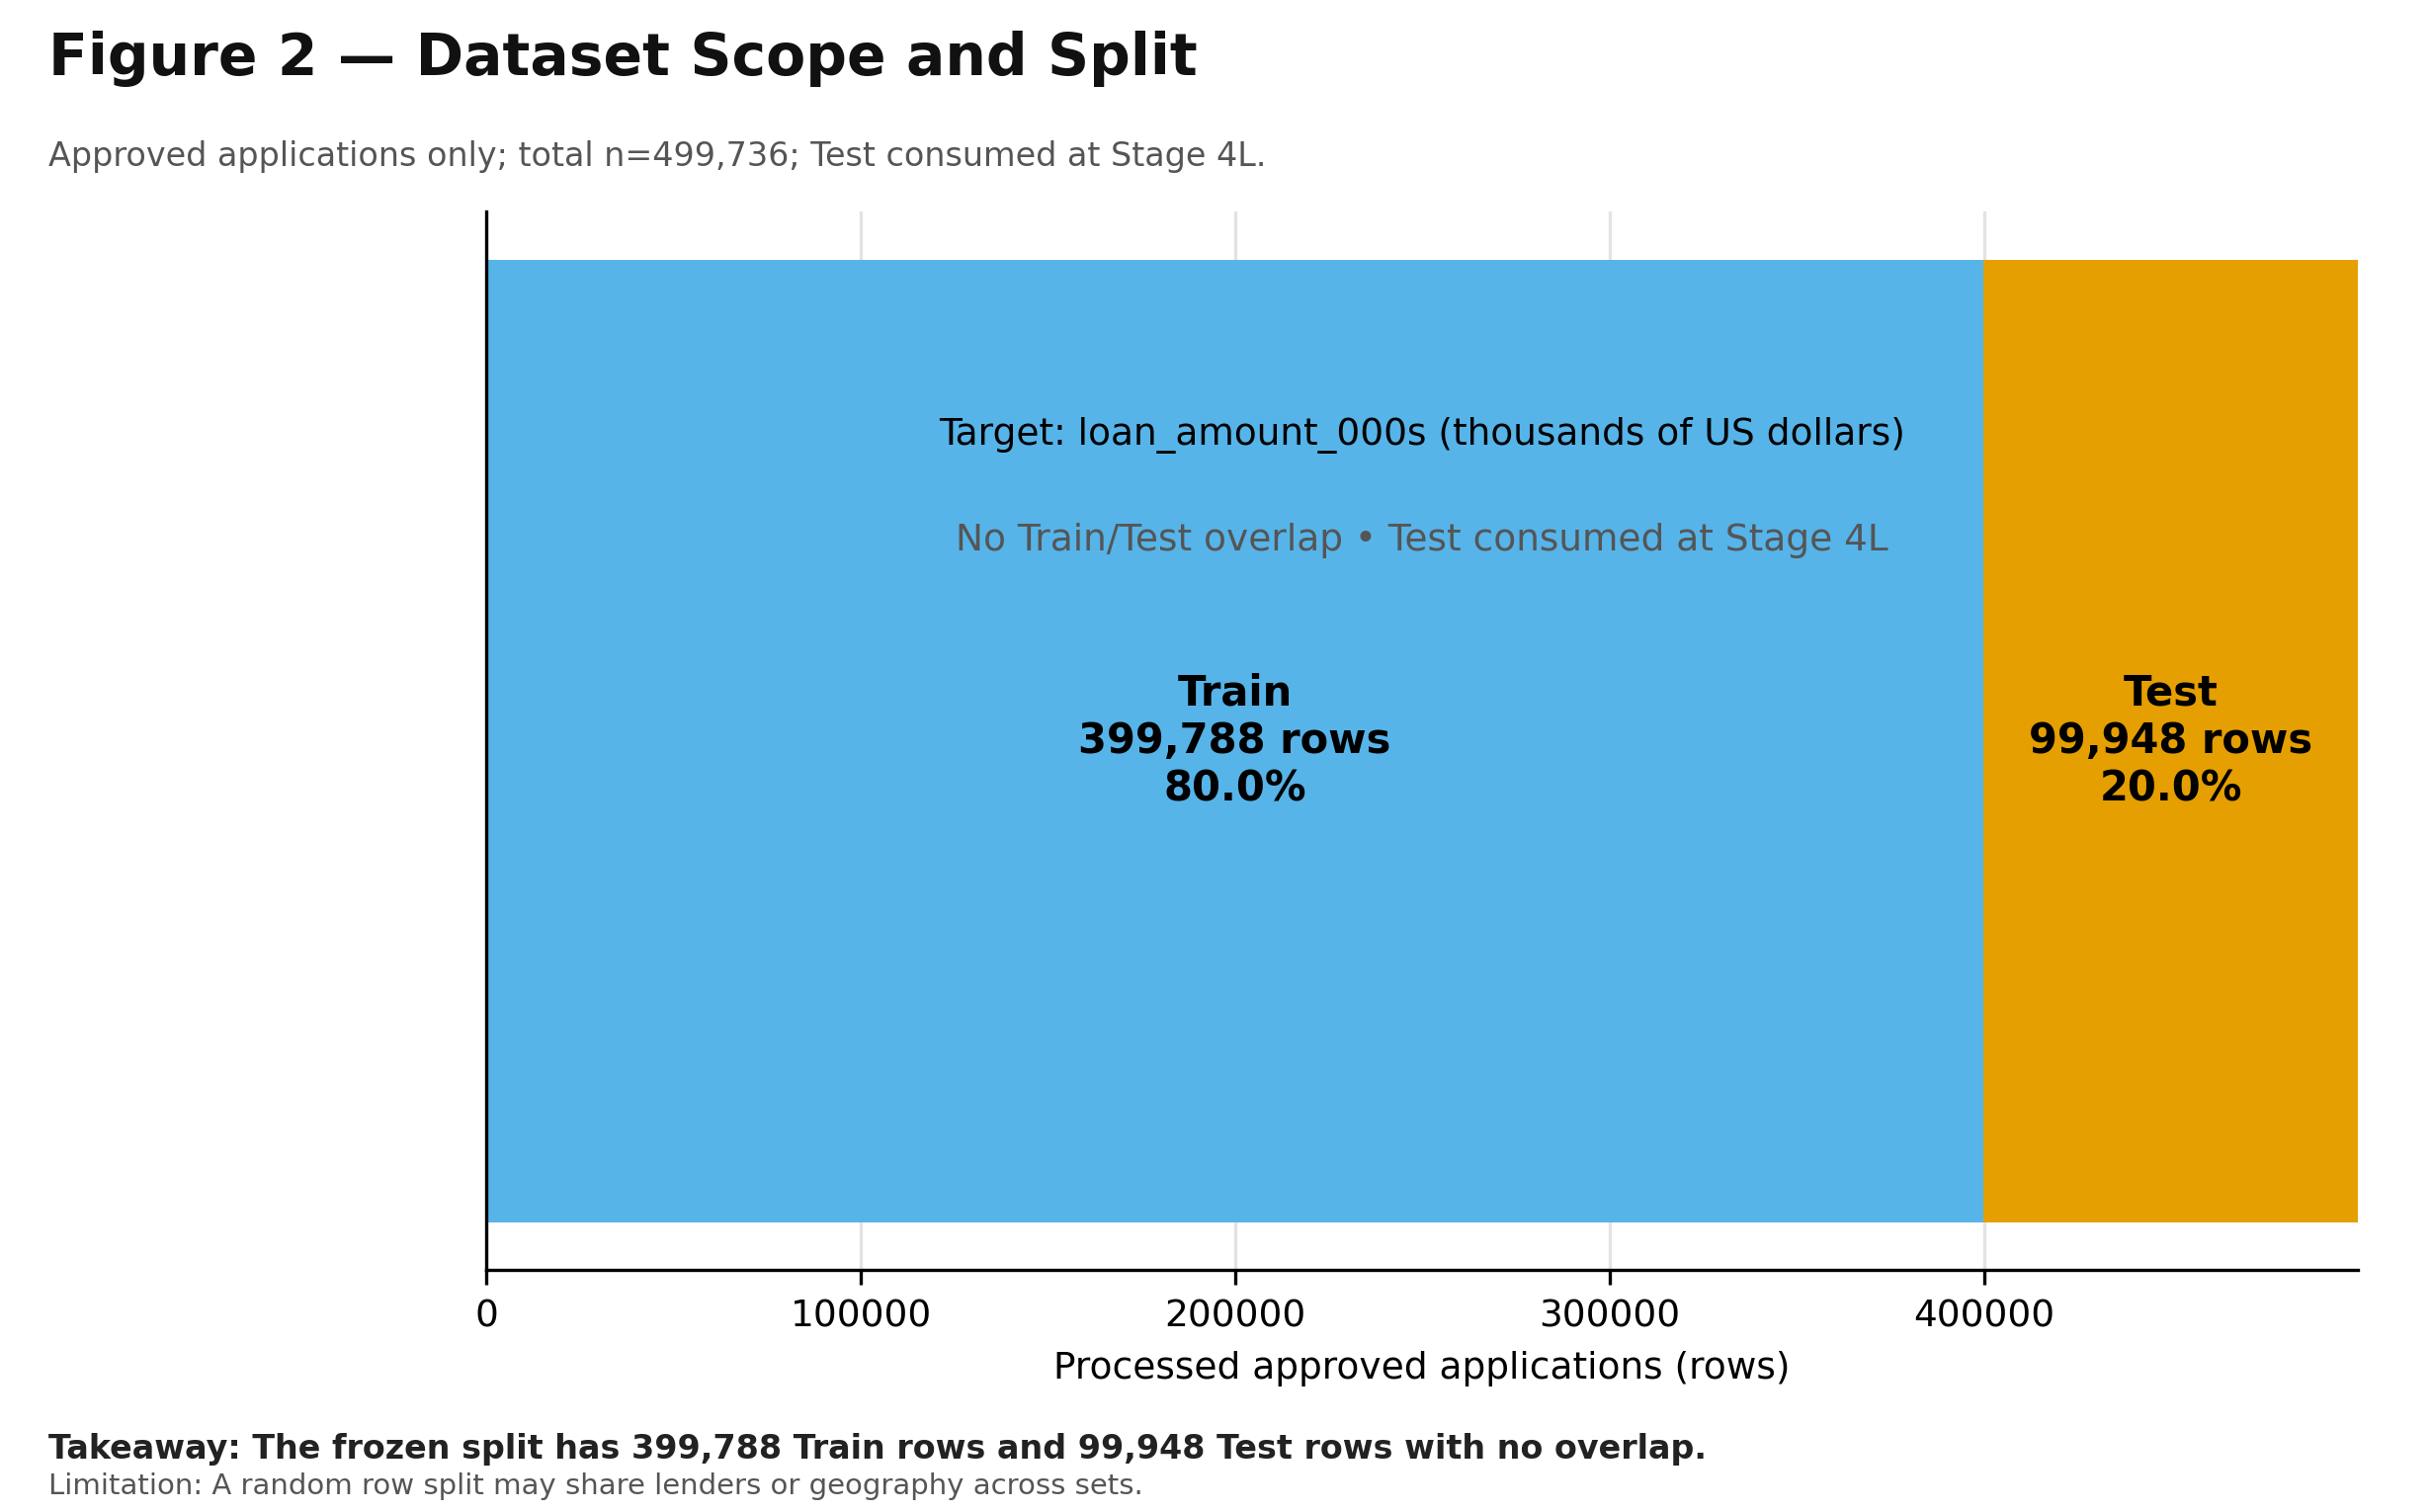

**Figure 2 — Dataset Scope and Split**  
Figure 2. Dataset Scope and Split. Approved applications only; total n=499,736; Test consumed at Stage 4L.  
**Takeaway:** The frozen split has 399,788 Train rows and 99,948 Test rows with no overlap.  
**Limitation:** A random row split may share lenders or geography across sets.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_02.png`

In [10]:
render_table(
    "artifacts/results/stage9/reporting/stage9_dataset_summary.csv",
    columns=["Dataset role", "Row count", "Target", "Target unit", "Approved-only status", "Source status", "Notes"],
    caption="Dataset and target summary",
)
render_manifest_figure(2)


## 10. Data Split and Evaluation Governance

The frozen Test Set was opened at Stage 4L after the official blend was fixed. Later Stage 5C Test comparisons use the same population but are Post-Test, so they cannot replace the official result. Another unbiased final comparison needs a new independent holdout.


In [11]:
dataset = read_table("artifacts/results/stage9/reporting/stage9_dataset_summary.csv")
split = dataset.loc[dataset["Dataset role"].isin(["Frozen Train", "Frozen Test"]), [
    "Dataset role", "Row count", "Source status", "Notes"
]].copy()
display_table_frame(split, "Frozen split")
timeline = read_table("artifacts/results/stage9/reporting/stage9_governance_timeline.csv")
evaluation_rows = timeline.loc[timeline["Stage"].isin(["Stage 4L", "Stage 5C"]), [
    "Stage", "Governance event", "Scientific effect", "Remaining disclosure", "Downstream rule"
]].copy()
display_table_frame(evaluation_rows, "Evaluation governance timeline rows")
render_evidence_note("artifacts/results/stage9/reporting/stage9_governance_timeline.csv")


**Frozen split**

Dataset role,Row count,Source status,Notes
Frozen Train,"399,788",saved membership,Used for model development
Frozen Test,"99,948",consumed at Stage 4L,No Train/Test overlap


**Evaluation governance timeline rows**

Stage,Governance event,Scientific effect,Remaining disclosure,Downstream rule
Stage 4L,Test freeze before evaluation,Protected unbiased official comparison,Freeze identity and hash remain authoritative,No later Test observation may replace the official result
Stage 4L,Test consumed,Official Test metrics became available,Test remains consumed,A new holdout is required for another unbiased final comparison
Stage 5C,Post-Test deep evaluation,Two descriptive RealMLP Test results,Cannot promote a new winner,New independent holdout required


*Evidence:* `artifacts/results/stage9/reporting/stage9_governance_timeline.csv`  
*SHA-256:* `76c02ddd327b83feb83701c292b24bc49a40cc3348bd3d318b843d63e39a6bf2`

## 11. Metric Glossary

Metrics describe different parts of model error. MAE and RMSE are lower when errors are smaller; R² is higher when more variation is represented; mean signed error is better when it is closer to zero. None of these is an accuracy percentage.


In [12]:
glossary_path = "artifacts/results/stage9/reporting/stage9_nontechnical_glossary.md"
glossary = clean_display_text(artifact_path(glossary_path).read_text(encoding="utf-8"))
terms = ["MAE", "RMSE", "R²", "RMSLE", "Bootstrap", "Post-Test Extension"]
selected_lines = [line for line in glossary.splitlines() if any(line.startswith(f"**{term}:") for term in terms)]
if len(selected_lines) != 6:
    raise AssertionError(f"Expected six glossary definitions, found {len(selected_lines)}")
display(Markdown("### Required definitions\n\n" + "\n\n".join(selected_lines)))
directions = pd.DataFrame([
    {"Metric": "MAE", "Direction": "Lower is better"},
    {"Metric": "RMSE", "Direction": "Lower is better"},
    {"Metric": "R²", "Direction": "Higher is better; not an accuracy percentage"},
    {"Metric": "Mean Signed Error", "Direction": "Closer to zero is better"},
])
display_table_frame(directions, "Metric direction")
render_evidence_note(glossary_path)


### Required definitions

**MAE:** Mean absolute error: the average size of a mistake, ignoring whether it is too high or too low.

**RMSE:** Root mean squared error: an error measure that gives extra weight to large mistakes.

**R²:** A measure of how much target variation the model captures. It is not an accuracy percentage.

**RMSLE:** An error measure on a logarithmic scale that reduces the influence of absolute size differences.

**Bootstrap:** A resampling method used here to describe uncertainty in saved comparisons.

**Post-Test Extension:** Work performed after the locked Test result was already known.

**Metric direction**

Metric,Direction
MAE,Lower is better
RMSE,Lower is better
R²,Higher is better; not an accuracy percentage
Mean Signed Error,Closer to zero is better


*Evidence:* `artifacts/results/stage9/reporting/stage9_nontechnical_glossary.md`  
*SHA-256:* `f53eb94a59a75799464f78a84d155ccd88a4d884056608aedd76a2b0d23a5333`

## 12. Complete Project Workflow

The project first validated data and froze the split, then developed linear, tree, boosting, and deep models. Stage 4L performed the locked evaluation. Later stages added descriptive error, fairness, and explainability evidence. Stage 9 assembled the final report; Stage 10 remains packaging-only and unstarted.


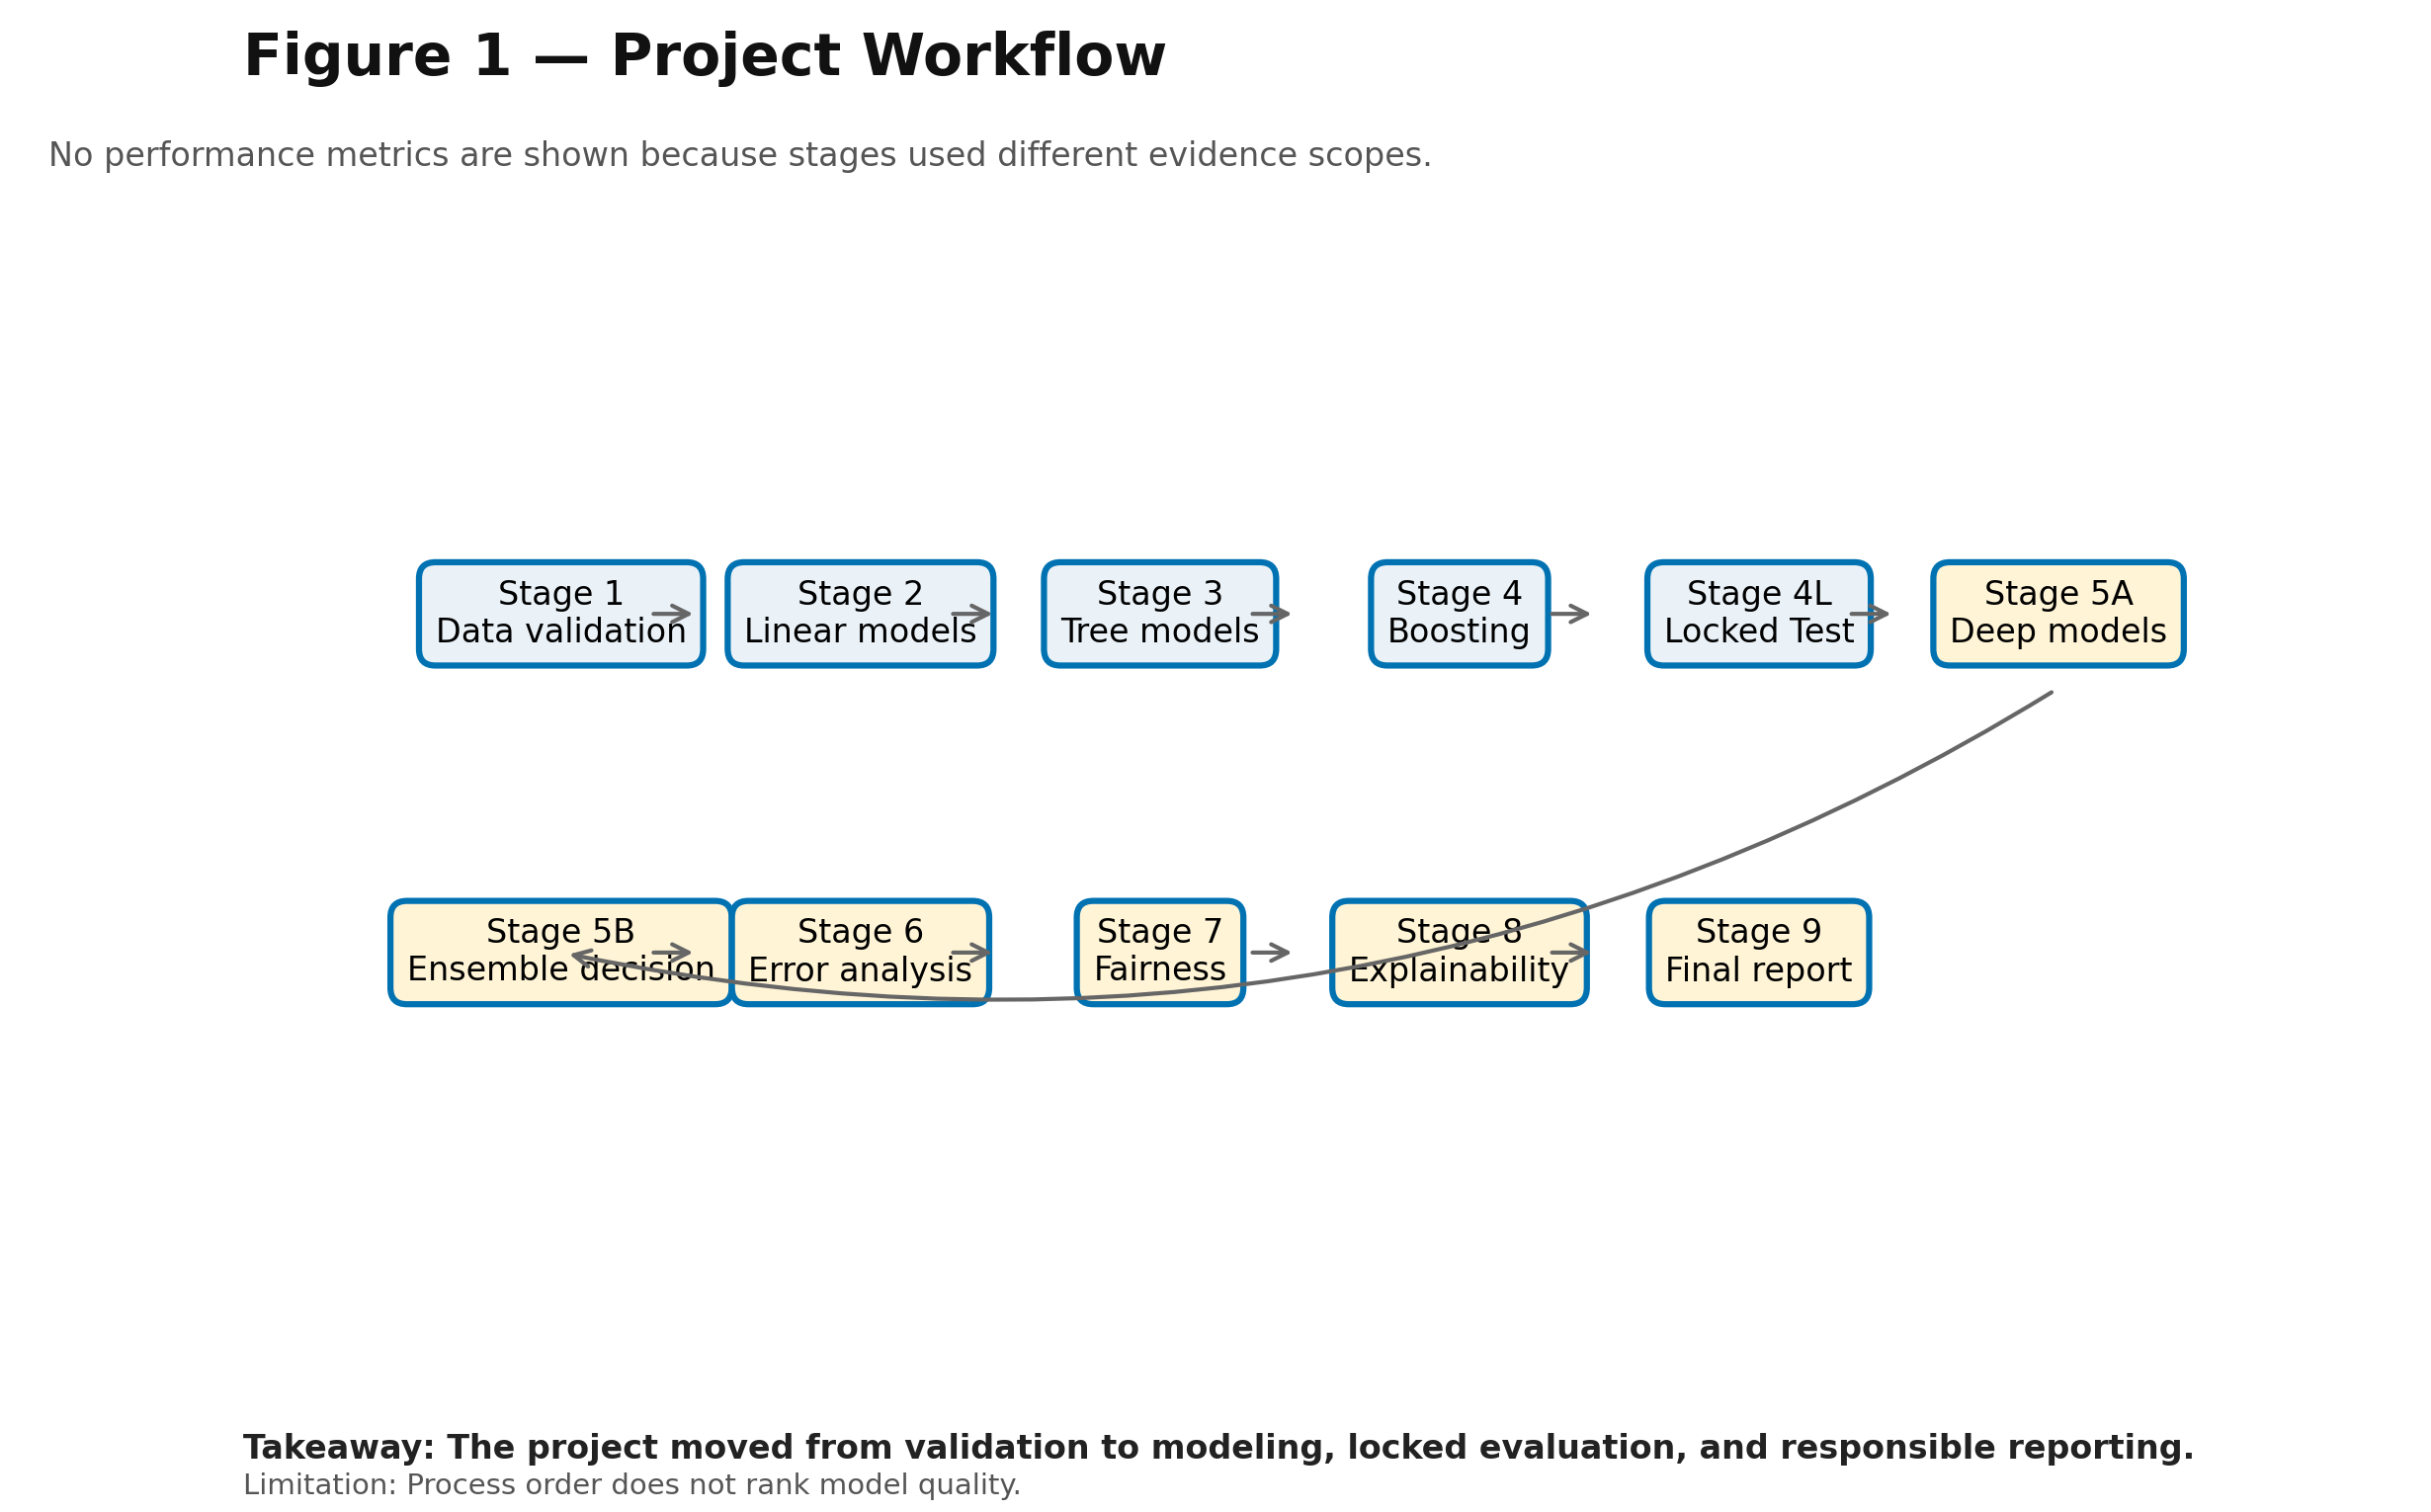

**Figure 1 — Project Workflow**  
Figure 1. Project Workflow. No performance metrics are shown because stages used different evidence scopes.  
**Takeaway:** The project moved from validation to modeling, locked evaluation, and responsible reporting.  
**Limitation:** Process order does not rank model quality.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_01.png`

**Major project phases**

Phase,Purpose
Data foundation,Validate source integrity and freeze split and folds
Model development,Compare model families using Train-only evidence
Locked evaluation,Evaluate the frozen official model once at Stage 4L
Post-Test analysis,"Describe deep results, errors, fairness, and explainability without promotion"
Final reporting,"Present saved evidence, governance, limits, and recommendations"


,Phase,Purpose
0,Data foundation,Validate source integrity and freeze split and...
1,Model development,Compare model families using Train-only evidence
2,Locked evaluation,Evaluate the frozen official model once at Sta...
3,Post-Test analysis,"Describe deep results, errors, fairness, and e..."
4,Final reporting,"Present saved evidence, governance, limits, an..."


In [13]:
render_manifest_figure(1)
phases = pd.DataFrame([
    {"Phase": "Data foundation", "Purpose": "Validate source integrity and freeze split and folds"},
    {"Phase": "Model development", "Purpose": "Compare model families using Train-only evidence"},
    {"Phase": "Locked evaluation", "Purpose": "Evaluate the frozen official model once at Stage 4L"},
    {"Phase": "Post-Test analysis", "Purpose": "Describe deep results, errors, fairness, and explainability without promotion"},
    {"Phase": "Final reporting", "Purpose": "Present saved evidence, governance, limits, and recommendations"},
])
display_table_frame(phases, "Major project phases")


## 13. Modeling Journey

Development moved from linear baselines to nonlinear trees, boosting, and deep tabular models. Validation evidence supported development choices. Stage 4L is the official Test evaluation, and Stage 5C results are later descriptive comparisons.


**Complete modeling timeline**

Stage,Model family,Main purpose,Selection evidence,Result,Continued or stopped,Official/Post-Test role
Stage 1,Data validation,"Freeze source hashes, split, folds",Saved validation evidence,PASS,continued,development_context_only
Stage 2,Lasso and linear models,Establish interpretable baseline,OOF development evidence,Lasso representative,continued,development_context_only
Stage 3,HistGradientBoosting and trees,Test nonlinear tree families,OOF development evidence,HistGradientBoosting representative,continued,development_context_only
Stage 4,"CatBoost, LightGBM, XGBoost",Develop boosting candidates,Train-only validation,Frozen 60/20/20 blend,continued,development_context_only
Stage 4L,Frozen boosting blend,Locked Test evaluation,Pre-Test frozen Test plan,Official primary,official,official_pre_registered_primary
Stage 5A,"RealMLP, FT-Transformer, TabM",Post-Test deep development,Train-only Final Selection Validation,RealMLP continued,continued,post_test_development
Stage 5B,Deep + boosting ensemble,Frozen validation-only ensemble decision,Fixed acceptance gates,Rejected,stopped,rejected_not_test_eligible
Stage 5C,Frozen RealMLP,Descriptive Test comparison,Same saved Test membership,Two Post-Test results,analysis only,post_test_extension
Stage 6,Saved-prediction error analysis,Describe errors and tails,Three immutable prediction files,Tail risk documented,analysis only,post_test_error_analysis
Stage 7,Aggregate disparity analysis,Describe subgroup errors,Approved-only public aggregates,Disparities reported,analysis only,post_test_fairness


Full artifact: `artifacts/results/stage9/reporting/stage9_modeling_timeline.csv` (11 rows).

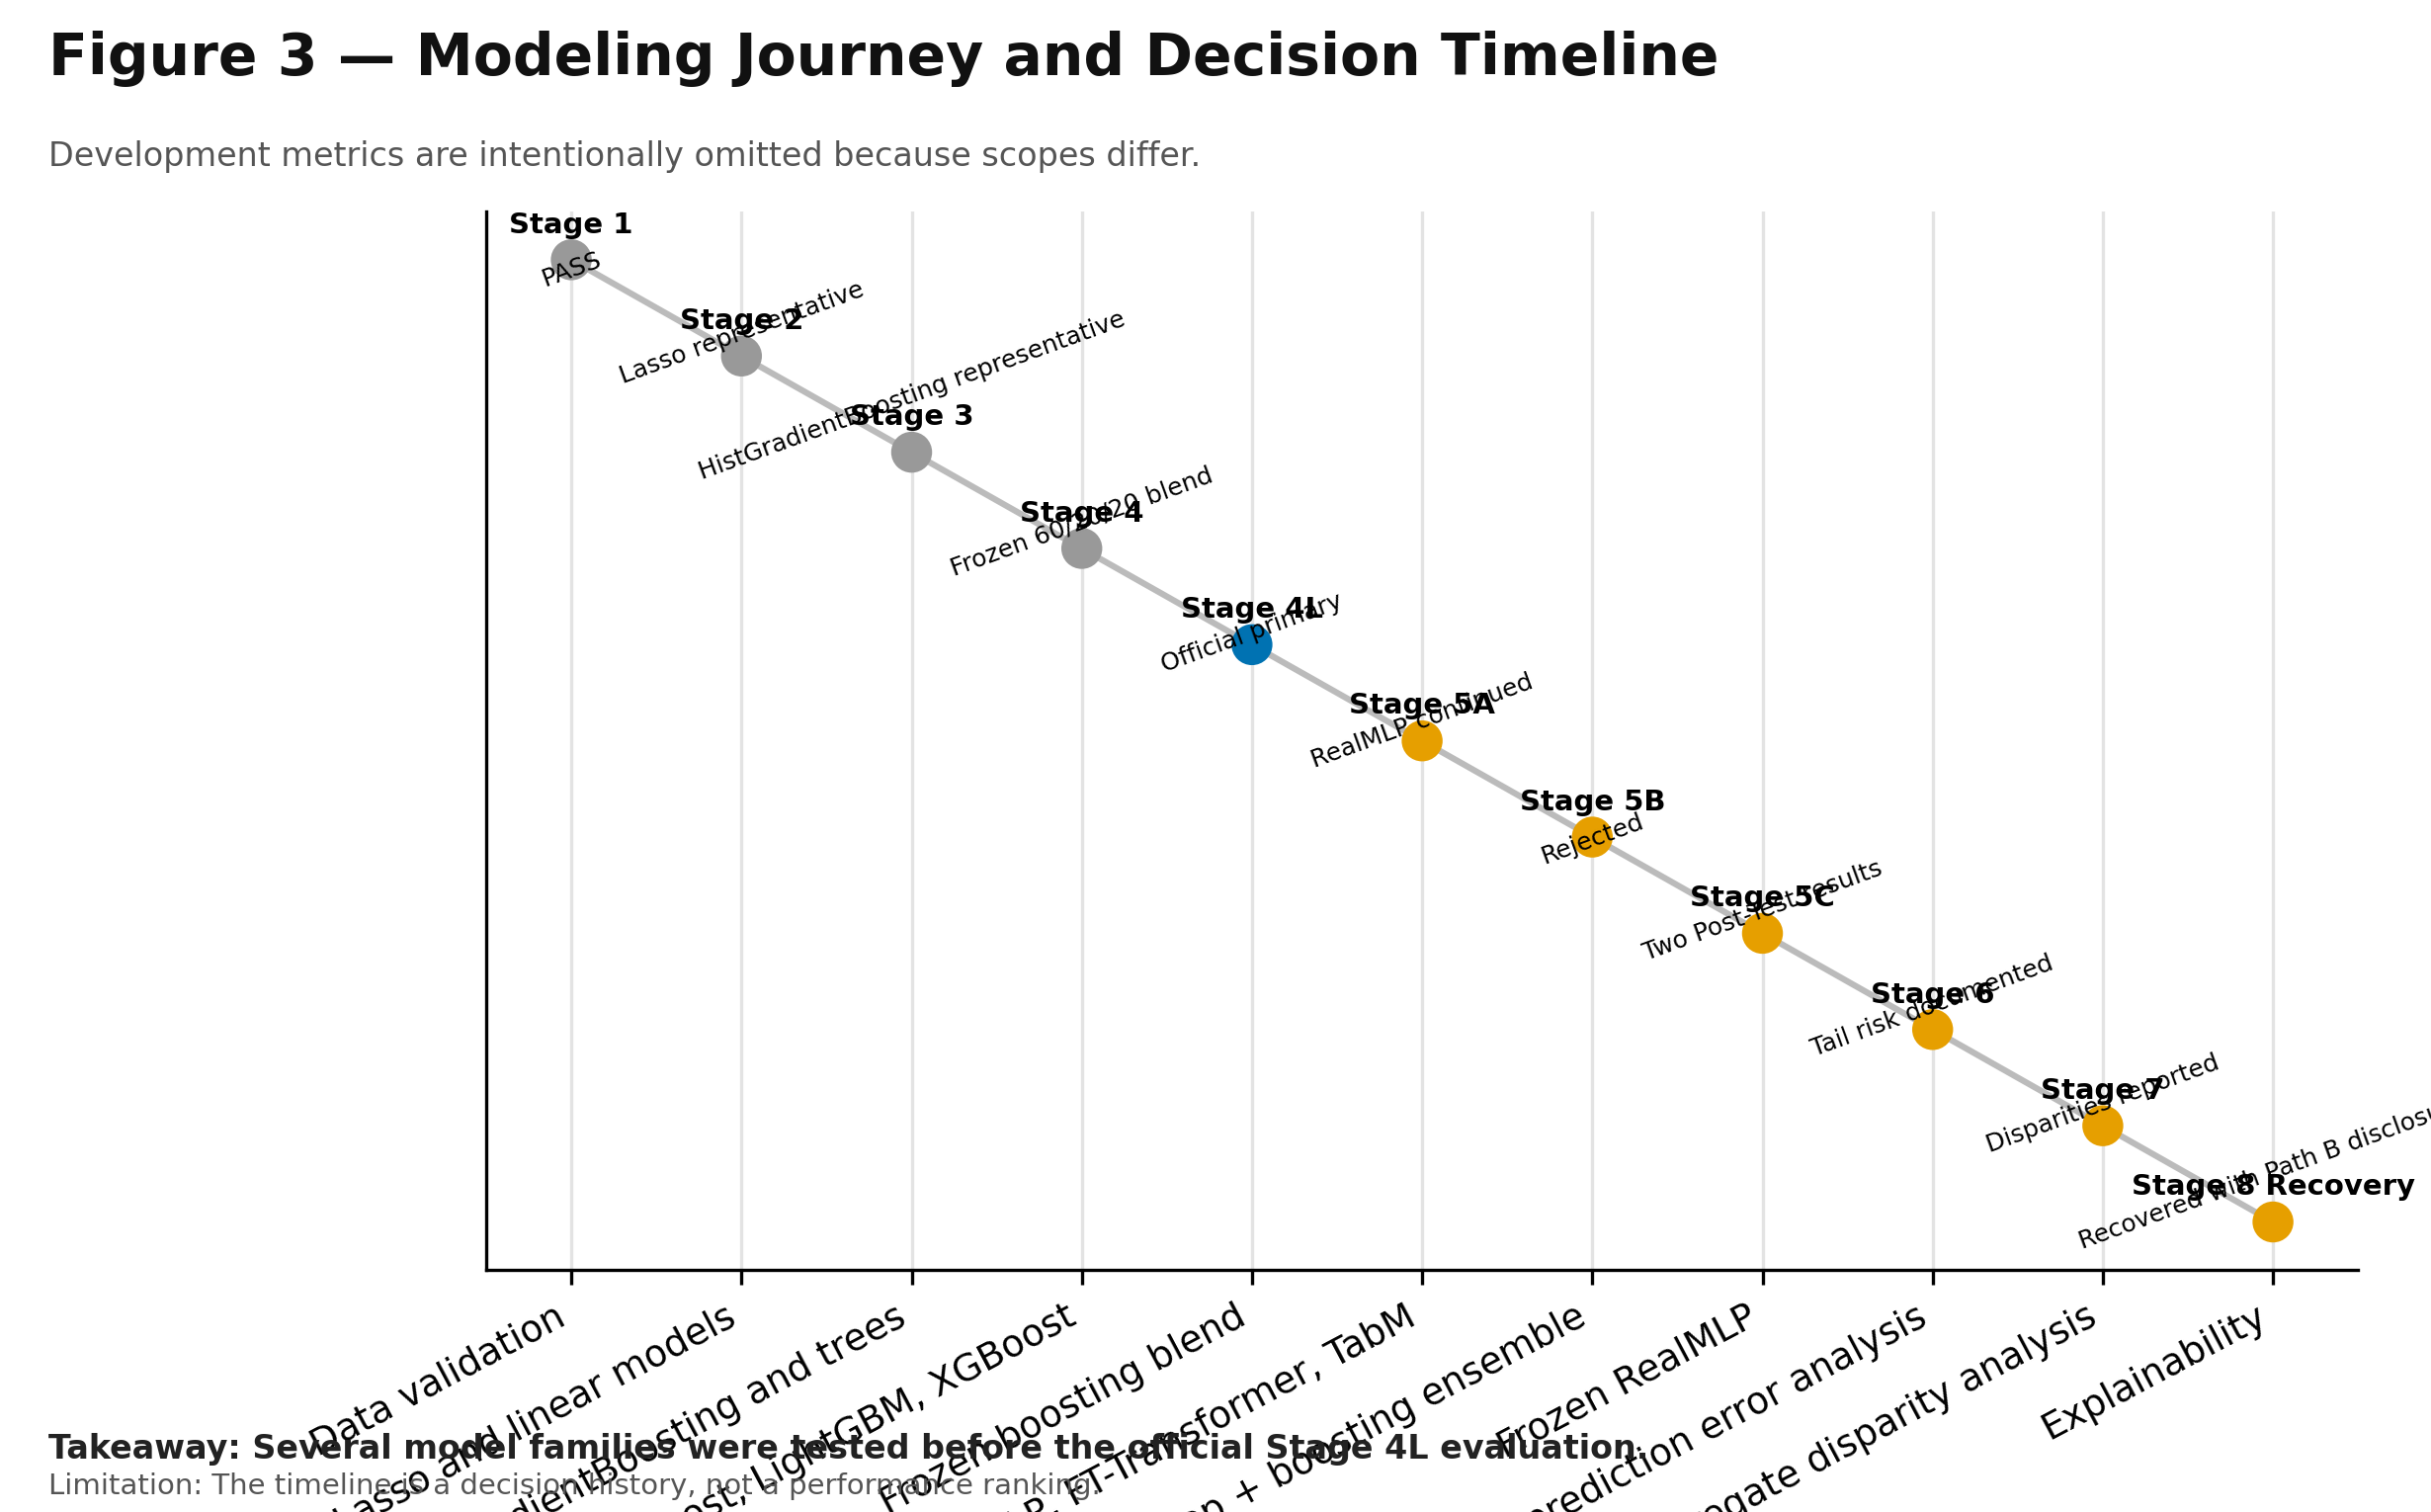

**Figure 3 — Modeling Journey and Decision Timeline**  
Figure 3. Modeling Journey and Decision Timeline. Development metrics are intentionally omitted because scopes differ.  
**Takeaway:** Several model families were tested before the official Stage 4L evaluation.  
**Limitation:** The timeline is a decision history, not a performance ranking.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_03.png`

**Figure 4 uses shared Final Selection Validation rows. It is Validation evidence, not official Test performance.**

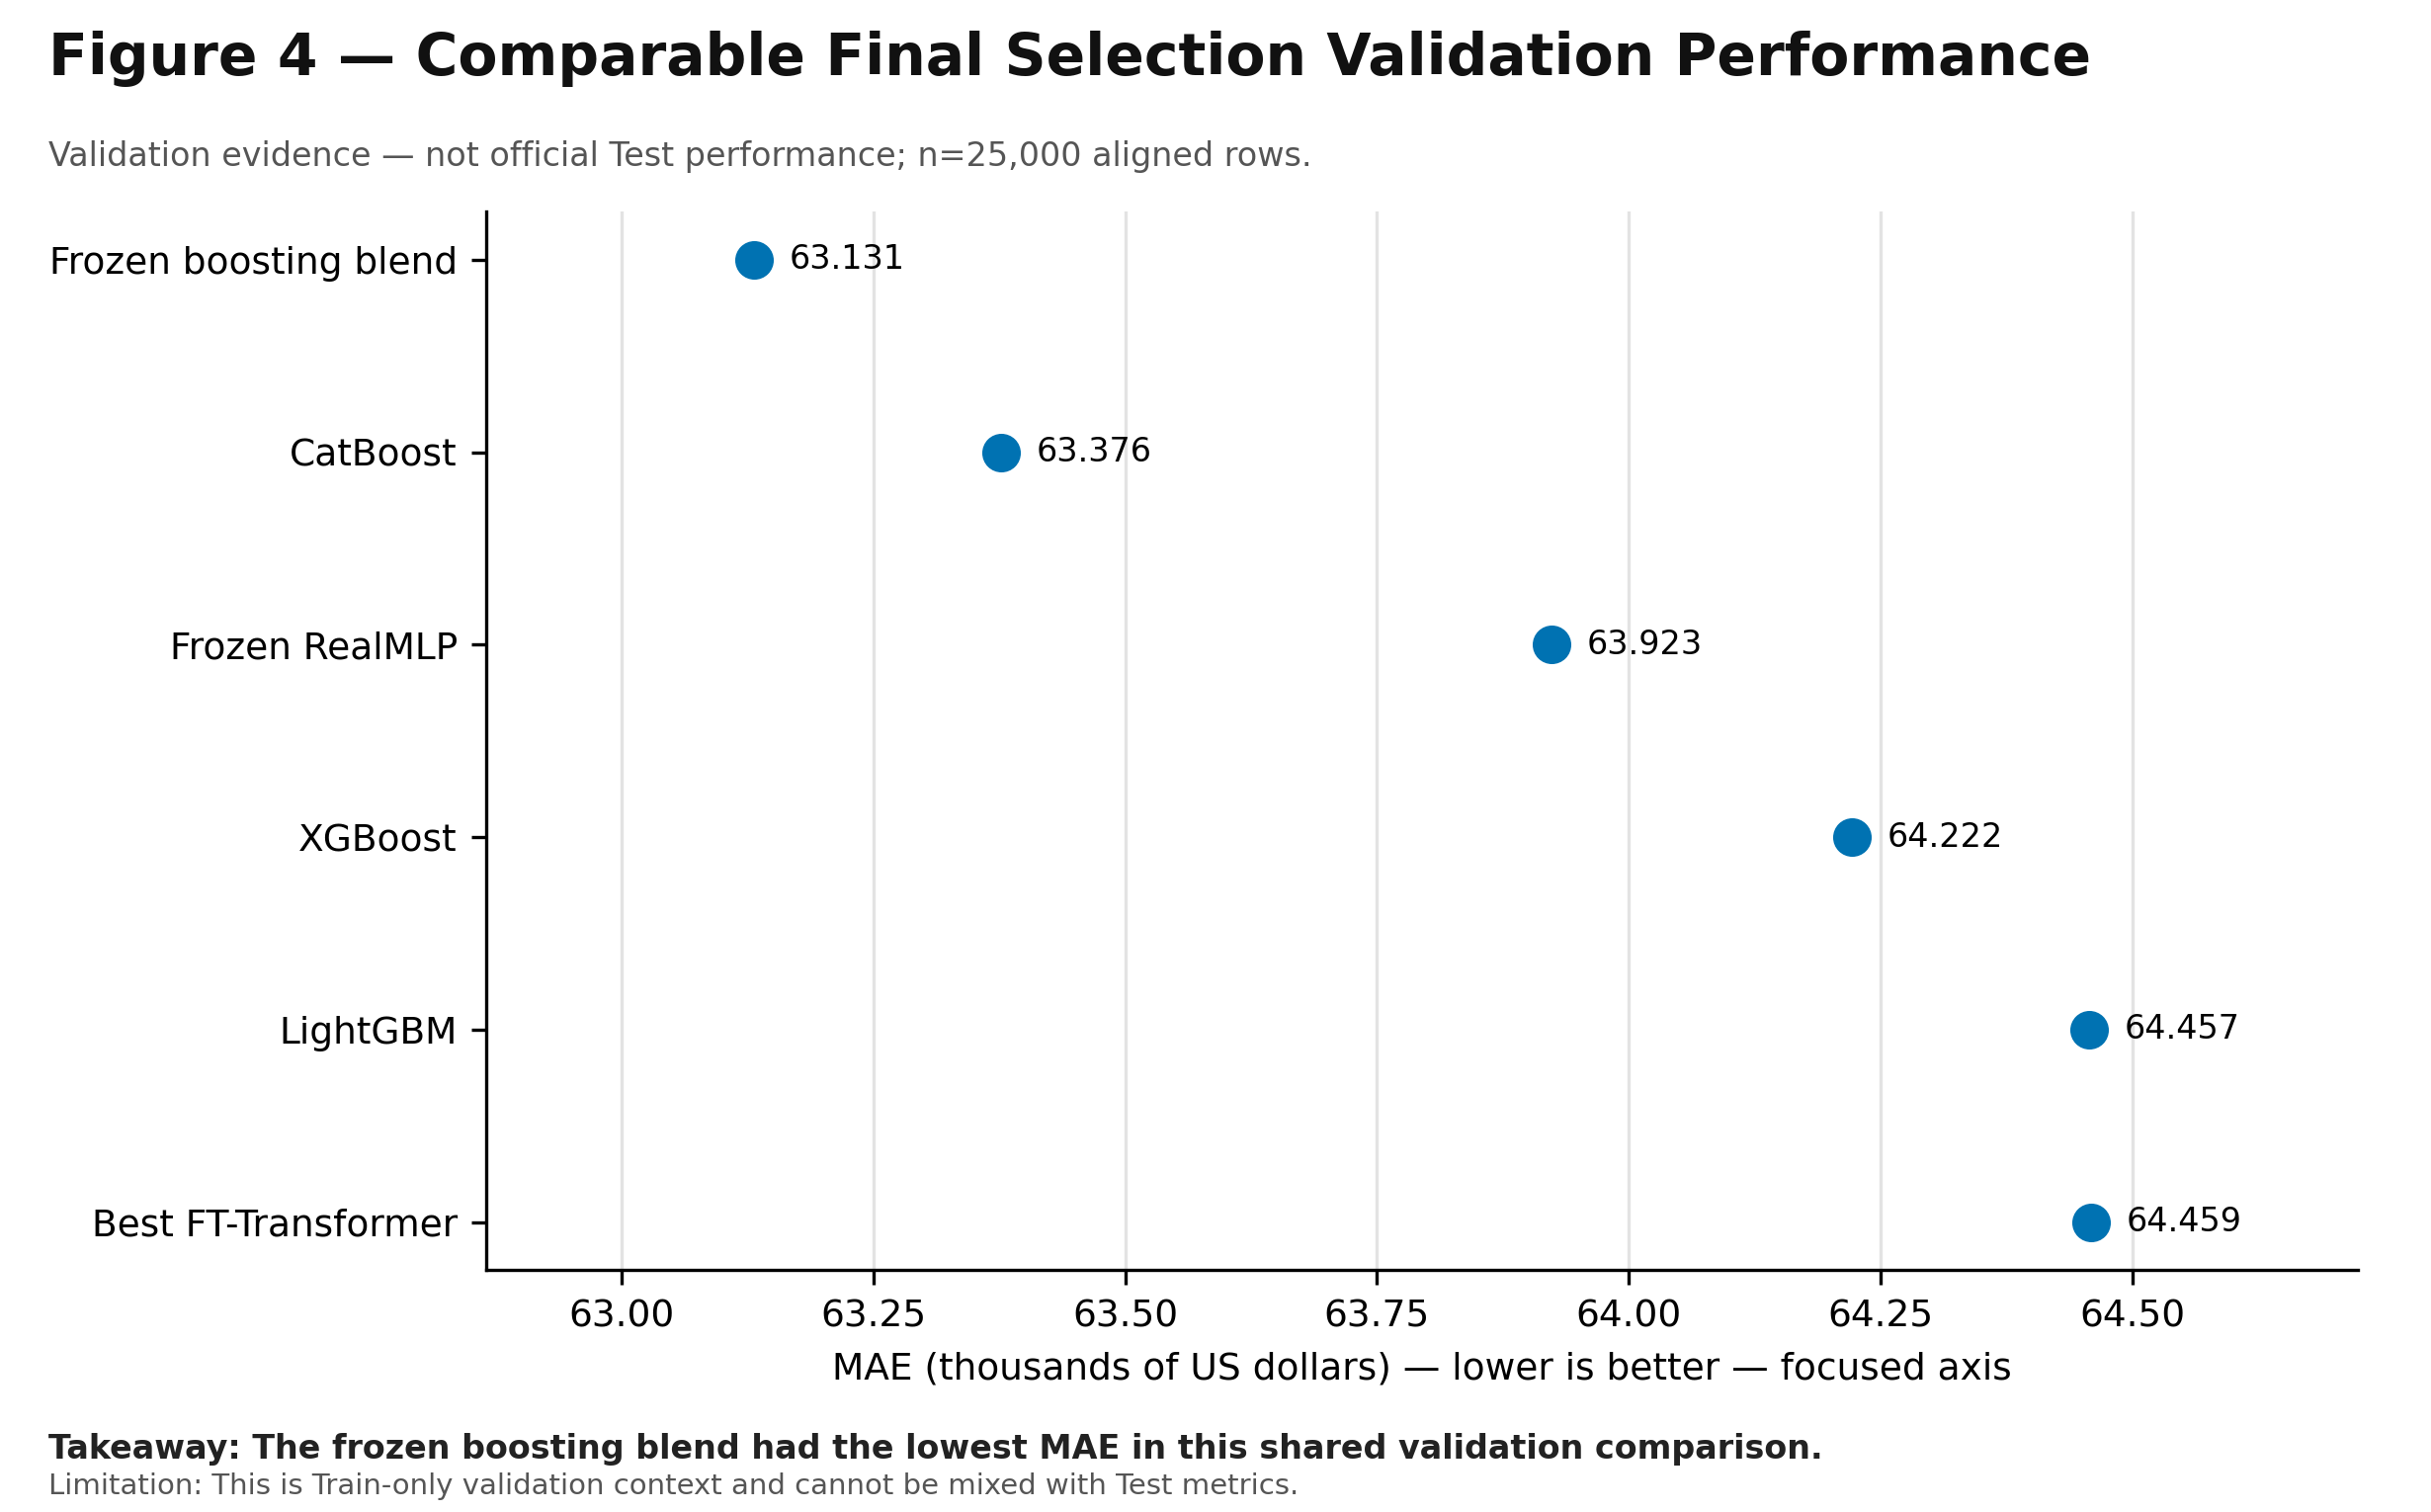

**Figure 4 — Comparable Final Selection Validation Performance**  
Figure 4. Comparable Final Selection Validation Performance. Validation evidence — not official Test performance; n=25,000 aligned rows.  
**Takeaway:** The frozen boosting blend had the lowest MAE in this shared validation comparison.  
**Limitation:** This is Train-only validation context and cannot be mixed with Test metrics.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_04.png`

In [14]:
render_table(
    "artifacts/results/stage9/reporting/stage9_modeling_timeline.csv",
    columns=["Stage", "Model family", "Main purpose", "Selection evidence", "Result", "Continued or stopped", "Official/Post-Test role"],
    caption="Complete modeling timeline",
)
render_manifest_figure(3)
display(Markdown("**Figure 4 uses shared Final Selection Validation rows. It is Validation evidence, not official Test performance.**"))
render_manifest_figure(4)


## 14. Model Roles and Comparability

Model role depends on when and where evidence was observed. Metrics can be ranked directly only when the evaluation rows, target, and metric definition match. Development OOF, Final Selection Validation, official Test, and Post-Test Test evidence must not be mixed as one leaderboard.


In [15]:
render_table(
    "artifacts/results/stage9/reporting/stage9_model_roles.csv",
    columns=["Candidate", "Role", "Stage", "Status"],
    caption="Model roles",
)
render_table(
    "artifacts/results/stage9/reporting/stage9_metric_scope_matrix.csv",
    columns=["Candidate", "Stage", "Evaluation dataset", "Row count", "Metric definition", "Target unit", "Official/Post-Test role", "Directly comparable with", "Not directly comparable with"],
    caption="Metric scope and comparability",
)


**Model roles**

Candidate,Role,Stage,Status
stage4l__blend__without_sensitive,official_pre_registered_primary,Stage 4L,Official
stage5c__realmlp__without_sensitive__test_evaluation,post_test_extension,Stage 5C,Post-Test
stage5c__realmlp__with_sensitive__test_evaluation,post_test_extension_accuracy_only,Stage 5C,Post-Test accuracy-only
stage5b__frozen_stage4_boosting_blend__deep-weight-0.50,rejected_not_test_eligible,Stage 5B,Rejected
Lasso,development_context_only,Development,Not a final Candidate
HistGradientBoosting,development_context_only,Development,Not a final Candidate
CatBoost,development_context_only,Development,Not a final Candidate
LightGBM,development_context_only,Development,Not a final Candidate
XGBoost,development_context_only,Development,Not a final Candidate
FT-Transformer,development_context_only,Development,Not a final Candidate


Full artifact: `artifacts/results/stage9/reporting/stage9_model_roles.csv` (11 rows).

**Metric scope and comparability**

Candidate,Stage,Evaluation dataset,Row count,Metric definition,Target unit,Official/Post-Test role,Directly comparable with,Not directly comparable with
stage4l__blend__without_sensitive,Stage 4L,Frozen Test,"99,948",Saved Stage 5C common metric contract,thousands of US dollars,official_pre_registered_primary,stage4l__blend__without_sensitive | stage5c__realmlp__without_sensitive__test_evaluation | stage5c__realmlp__with_sensitive__test_evaluation,Stage 2 OOF | Stage 3 OOF | Stage 4 Discovery | Stage 4 Feature Confirmation | Stage 4 Final Selection
stage5c__realmlp__without_sensitive__test_evaluation,Stage 5C,Frozen Test,"99,948",Saved Stage 5C common metric contract,thousands of US dollars,post_test_extension,stage4l__blend__without_sensitive | stage5c__realmlp__without_sensitive__test_evaluation | stage5c__realmlp__with_sensitive__test_evaluation,Stage 2 OOF | Stage 3 OOF | Stage 4 Discovery | Stage 4 Feature Confirmation | Stage 4 Final Selection
stage5c__realmlp__with_sensitive__test_evaluation,Stage 5C,Frozen Test,"99,948",Saved Stage 5C common metric contract,thousands of US dollars,post_test_extension_accuracy_only,stage4l__blend__without_sensitive | stage5c__realmlp__without_sensitive__test_evaluation | stage5c__realmlp__with_sensitive__test_evaluation,Stage 2 OOF | Stage 3 OOF | Stage 4 Discovery | Stage 4 Feature Confirmation | Stage 4 Final Selection
Stage 4/5 Final Selection families,Stage 4 and Stage 5A,Final Selection Validation,"25,000",Saved validation MAE,thousands of US dollars,validation context,Only candidates with the exact same Final Selection membership,Stage 4L Test | Stage 5C Test | Stage 2/3 OOF


Full artifact: `artifacts/results/stage9/reporting/stage9_metric_scope_matrix.csv` (4 rows).

,Candidate,Stage,Evaluation dataset,Row count,Metric definition,Target unit,Official/Post-Test role,Directly comparable with,Not directly comparable with
0,stage4l__blend__without_sensitive,Stage 4L,Frozen Test,99948,Saved Stage 5C common metric contract,thousands of US dollars,official_pre_registered_primary,stage4l__blend__without_sensitive | stage5c__r...,Stage 2 OOF | Stage 3 OOF | Stage 4 Discovery ...
1,stage5c__realmlp__without_sensitive__test_eval...,Stage 5C,Frozen Test,99948,Saved Stage 5C common metric contract,thousands of US dollars,post_test_extension,stage4l__blend__without_sensitive | stage5c__r...,Stage 2 OOF | Stage 3 OOF | Stage 4 Discovery ...
2,stage5c__realmlp__with_sensitive__test_evaluation,Stage 5C,Frozen Test,99948,Saved Stage 5C common metric contract,thousands of US dollars,post_test_extension_accuracy_only,stage4l__blend__without_sensitive | stage5c__r...,Stage 2 OOF | Stage 3 OOF | Stage 4 Discovery ...
3,Stage 4/5 Final Selection families,Stage 4 and Stage 5A,Final Selection Validation,25000,Saved validation MAE,thousands of US dollars,validation context,Only candidates with the exact same Final Sele...,Stage 4L Test | Stage 5C Test | Stage 2/3 OOF


## 15. Official Test Result

The Stage 4L frozen blend is the official pre-registered primary. Its MAE is 61.512 thousand US dollars, about $61,512 per approved application on average. MAE is an average error amount, not accuracy. RealMLP rows are exact Post-Test comparisons and remain descriptive.


**Selected final Test metrics**

Model,Official role,Evaluation label,Rows,MAE (thousand USD),MAE (USD),MAE difference from official (thousand USD),RMSE (thousand USD),R²,RMSLE,Mean Signed Error (thousand USD),Top-decile MAE (thousand USD),Top-five-percent MAE (thousand USD)
Stage 4L official blend,official_pre_registered_primary,Official,"99,948",61.512,"61,511.631",0.000,125.788,0.712,0.384,-9.554,195.498,287.064
RealMLP without sensitive (Post-Test),post_test_extension,Post-Test Extension,"99,948",62.160,"62,159.745",0.648,125.651,0.713,0.390,-7.014,191.741,278.546
"RealMLP with sensitive (Post-Test, accuracy-only)",post_test_extension_accuracy_only,Post-Test Extension,"99,948",61.821,"61,821.114",0.309,125.020,0.716,0.390,-6.441,190.956,277.236


*Evidence:* `artifacts/results/stage9/reporting/stage9_final_test_comparison.csv`  
*SHA-256:* `52de8fb08b5f77a1f16d6be9ece9defbdfe4d147955a97d1c3ffb95252ba3eda`

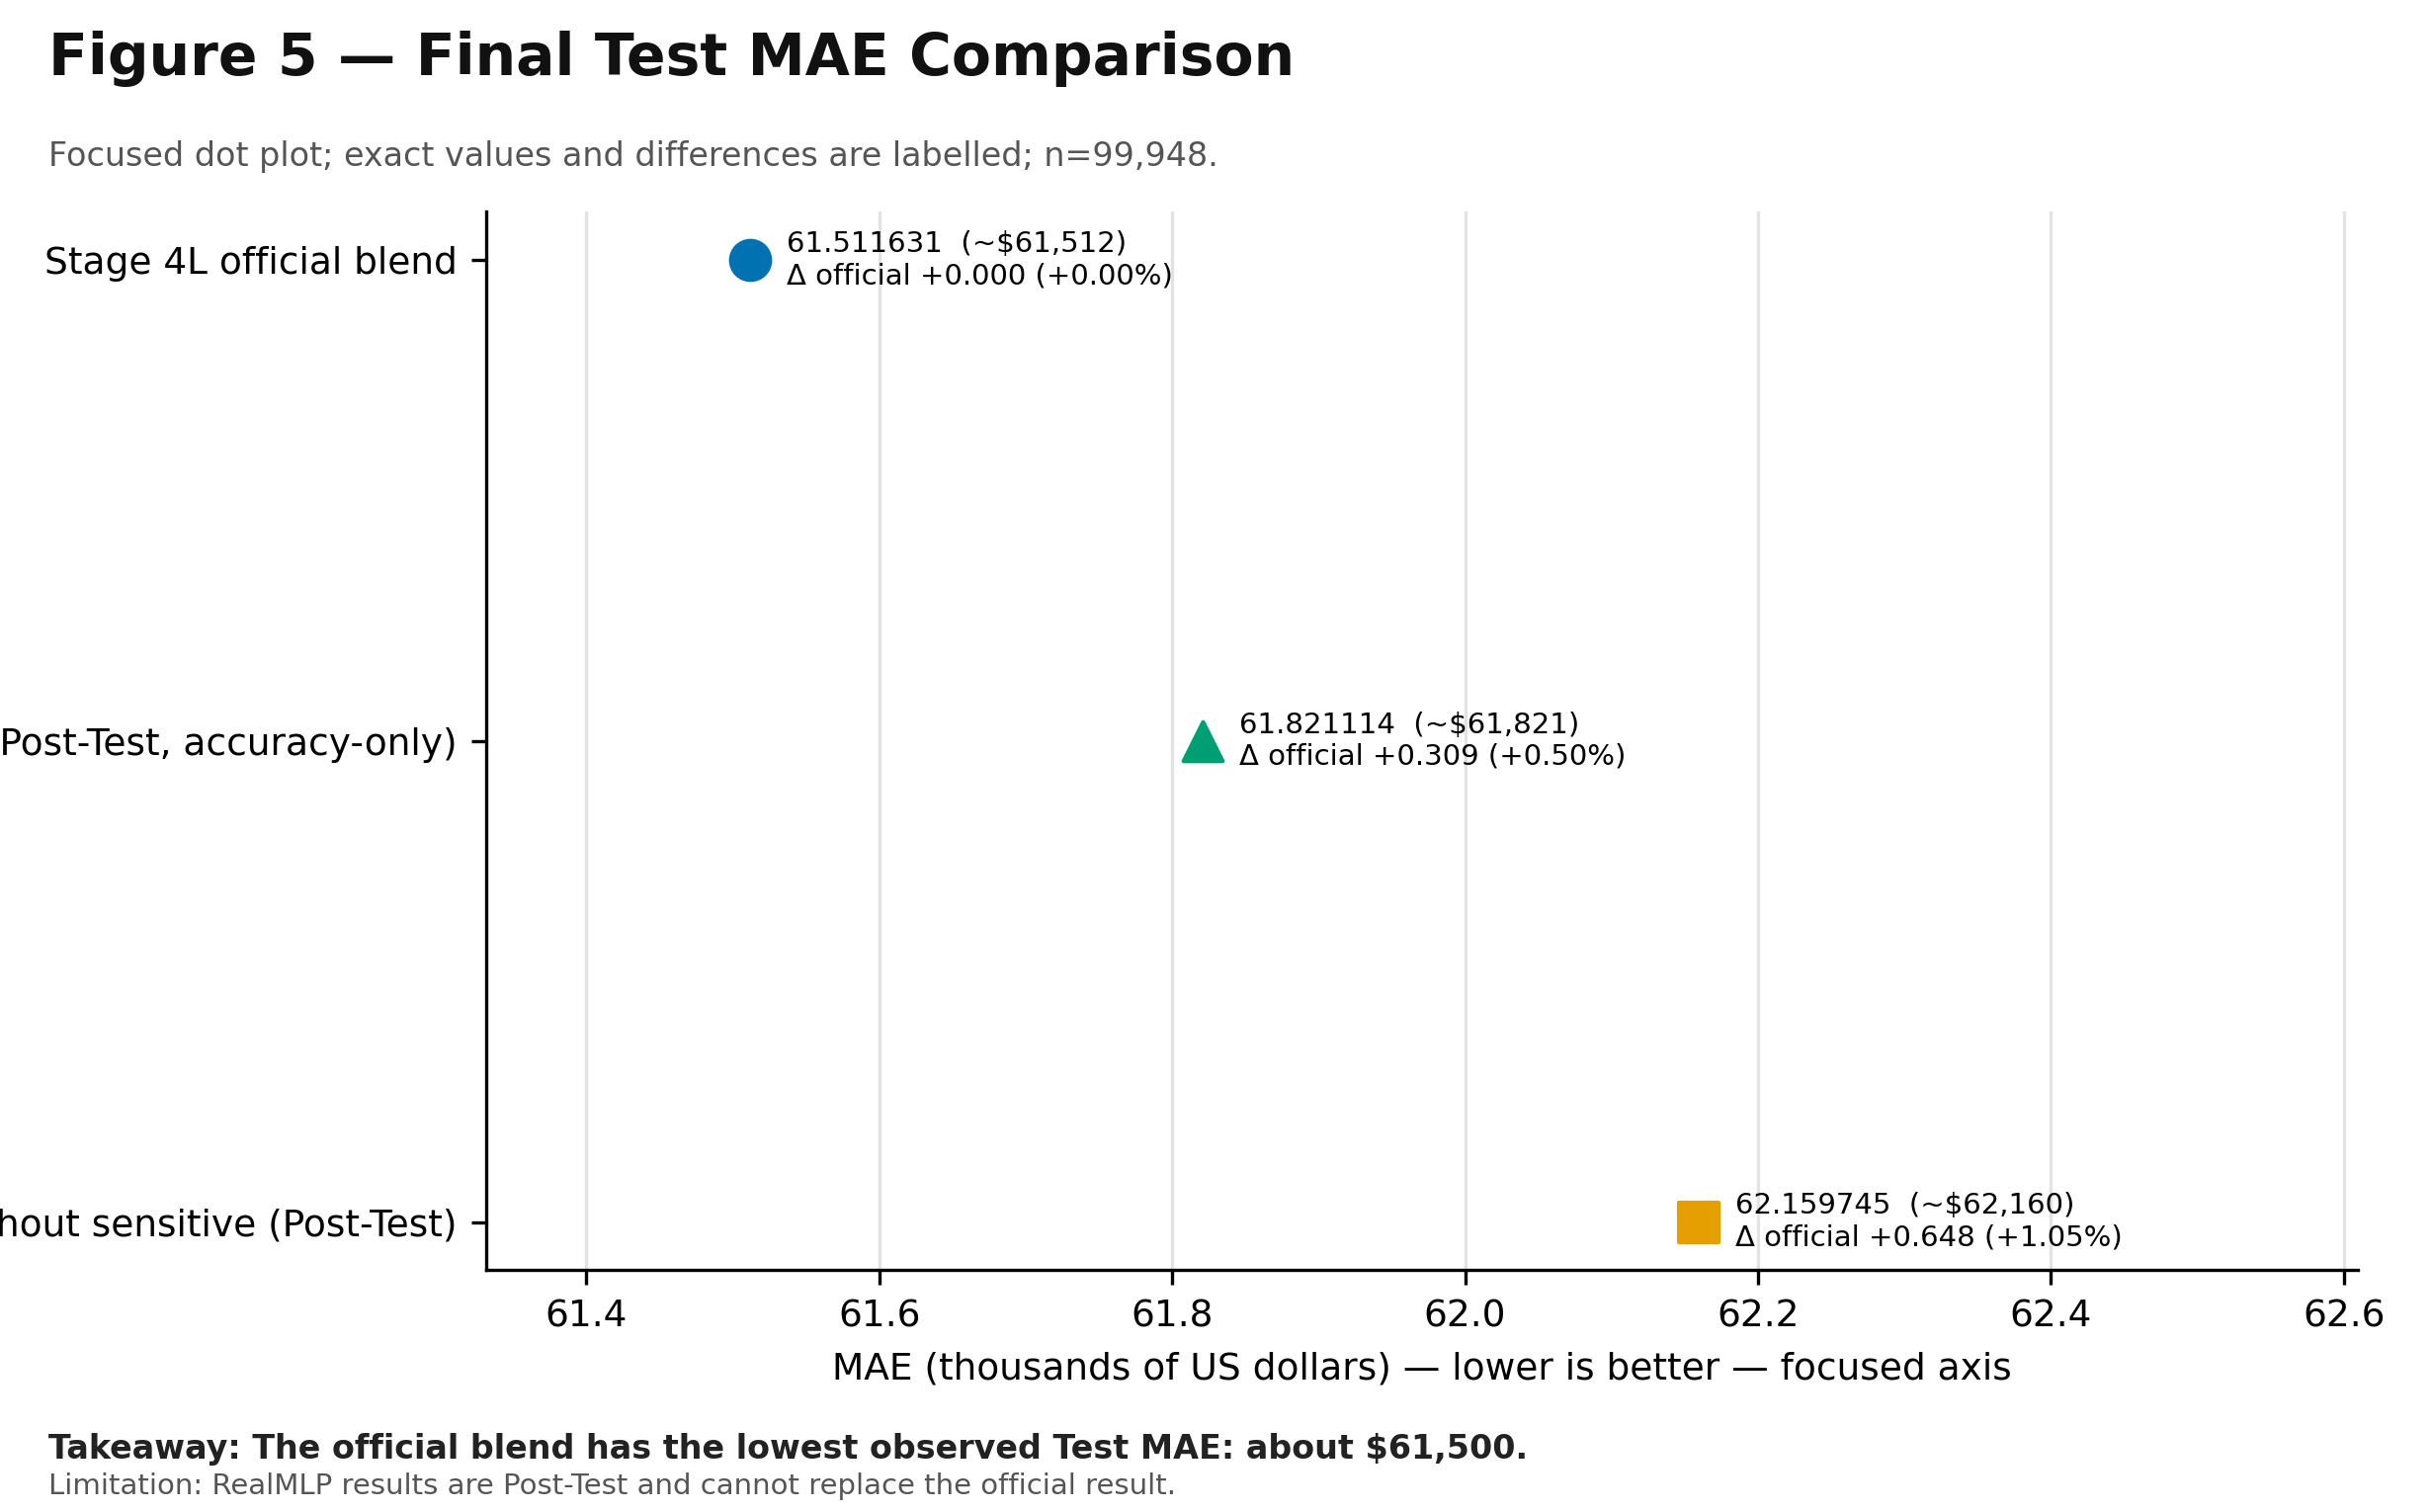

**Figure 5 — Final Test MAE Comparison**  
Figure 5. Final Test MAE Comparison. Focused dot plot; exact values and differences are labelled; n=99,948.  
**Takeaway:** The official blend has the lowest observed Test MAE: about $61,500.  
**Limitation:** RealMLP results are Post-Test and cannot replace the official result.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_05.png`

In [16]:
metrics_path = "artifacts/results/stage9/reporting/stage9_final_test_comparison.csv"
metrics = read_table(metrics_path)
selected_metrics = metrics.loc[:, [
    "display_name", "official_result_role", "official_post_test_label", "row_count",
    "mae", "dollar_equivalent_mae", "mae_difference_from_official", "rmse", "r_squared",
    "rmsle", "mean_signed_error", "top_decile_mae", "top_five_percent_mae"
]].copy()
selected_metrics.columns = [
    "Model", "Official role", "Evaluation label", "Rows", "MAE (thousand USD)",
    "MAE (USD)", "MAE difference from official (thousand USD)", "RMSE (thousand USD)",
    "R²", "RMSLE", "Mean Signed Error (thousand USD)", "Top-decile MAE (thousand USD)",
    "Top-five-percent MAE (thousand USD)"
]
display_table_frame(selected_metrics, "Selected final Test metrics")
render_evidence_note(metrics_path)
render_manifest_figure(5)


## 16. Post-Test Deep Comparison

The two RealMLP results were measured after Test had already been consumed. The without-sensitive model has higher MAE than Stage 4L, while the with-sensitive model has lower MAE than the without-sensitive RealMLP in an accuracy-only comparison. No model promotion occurred.


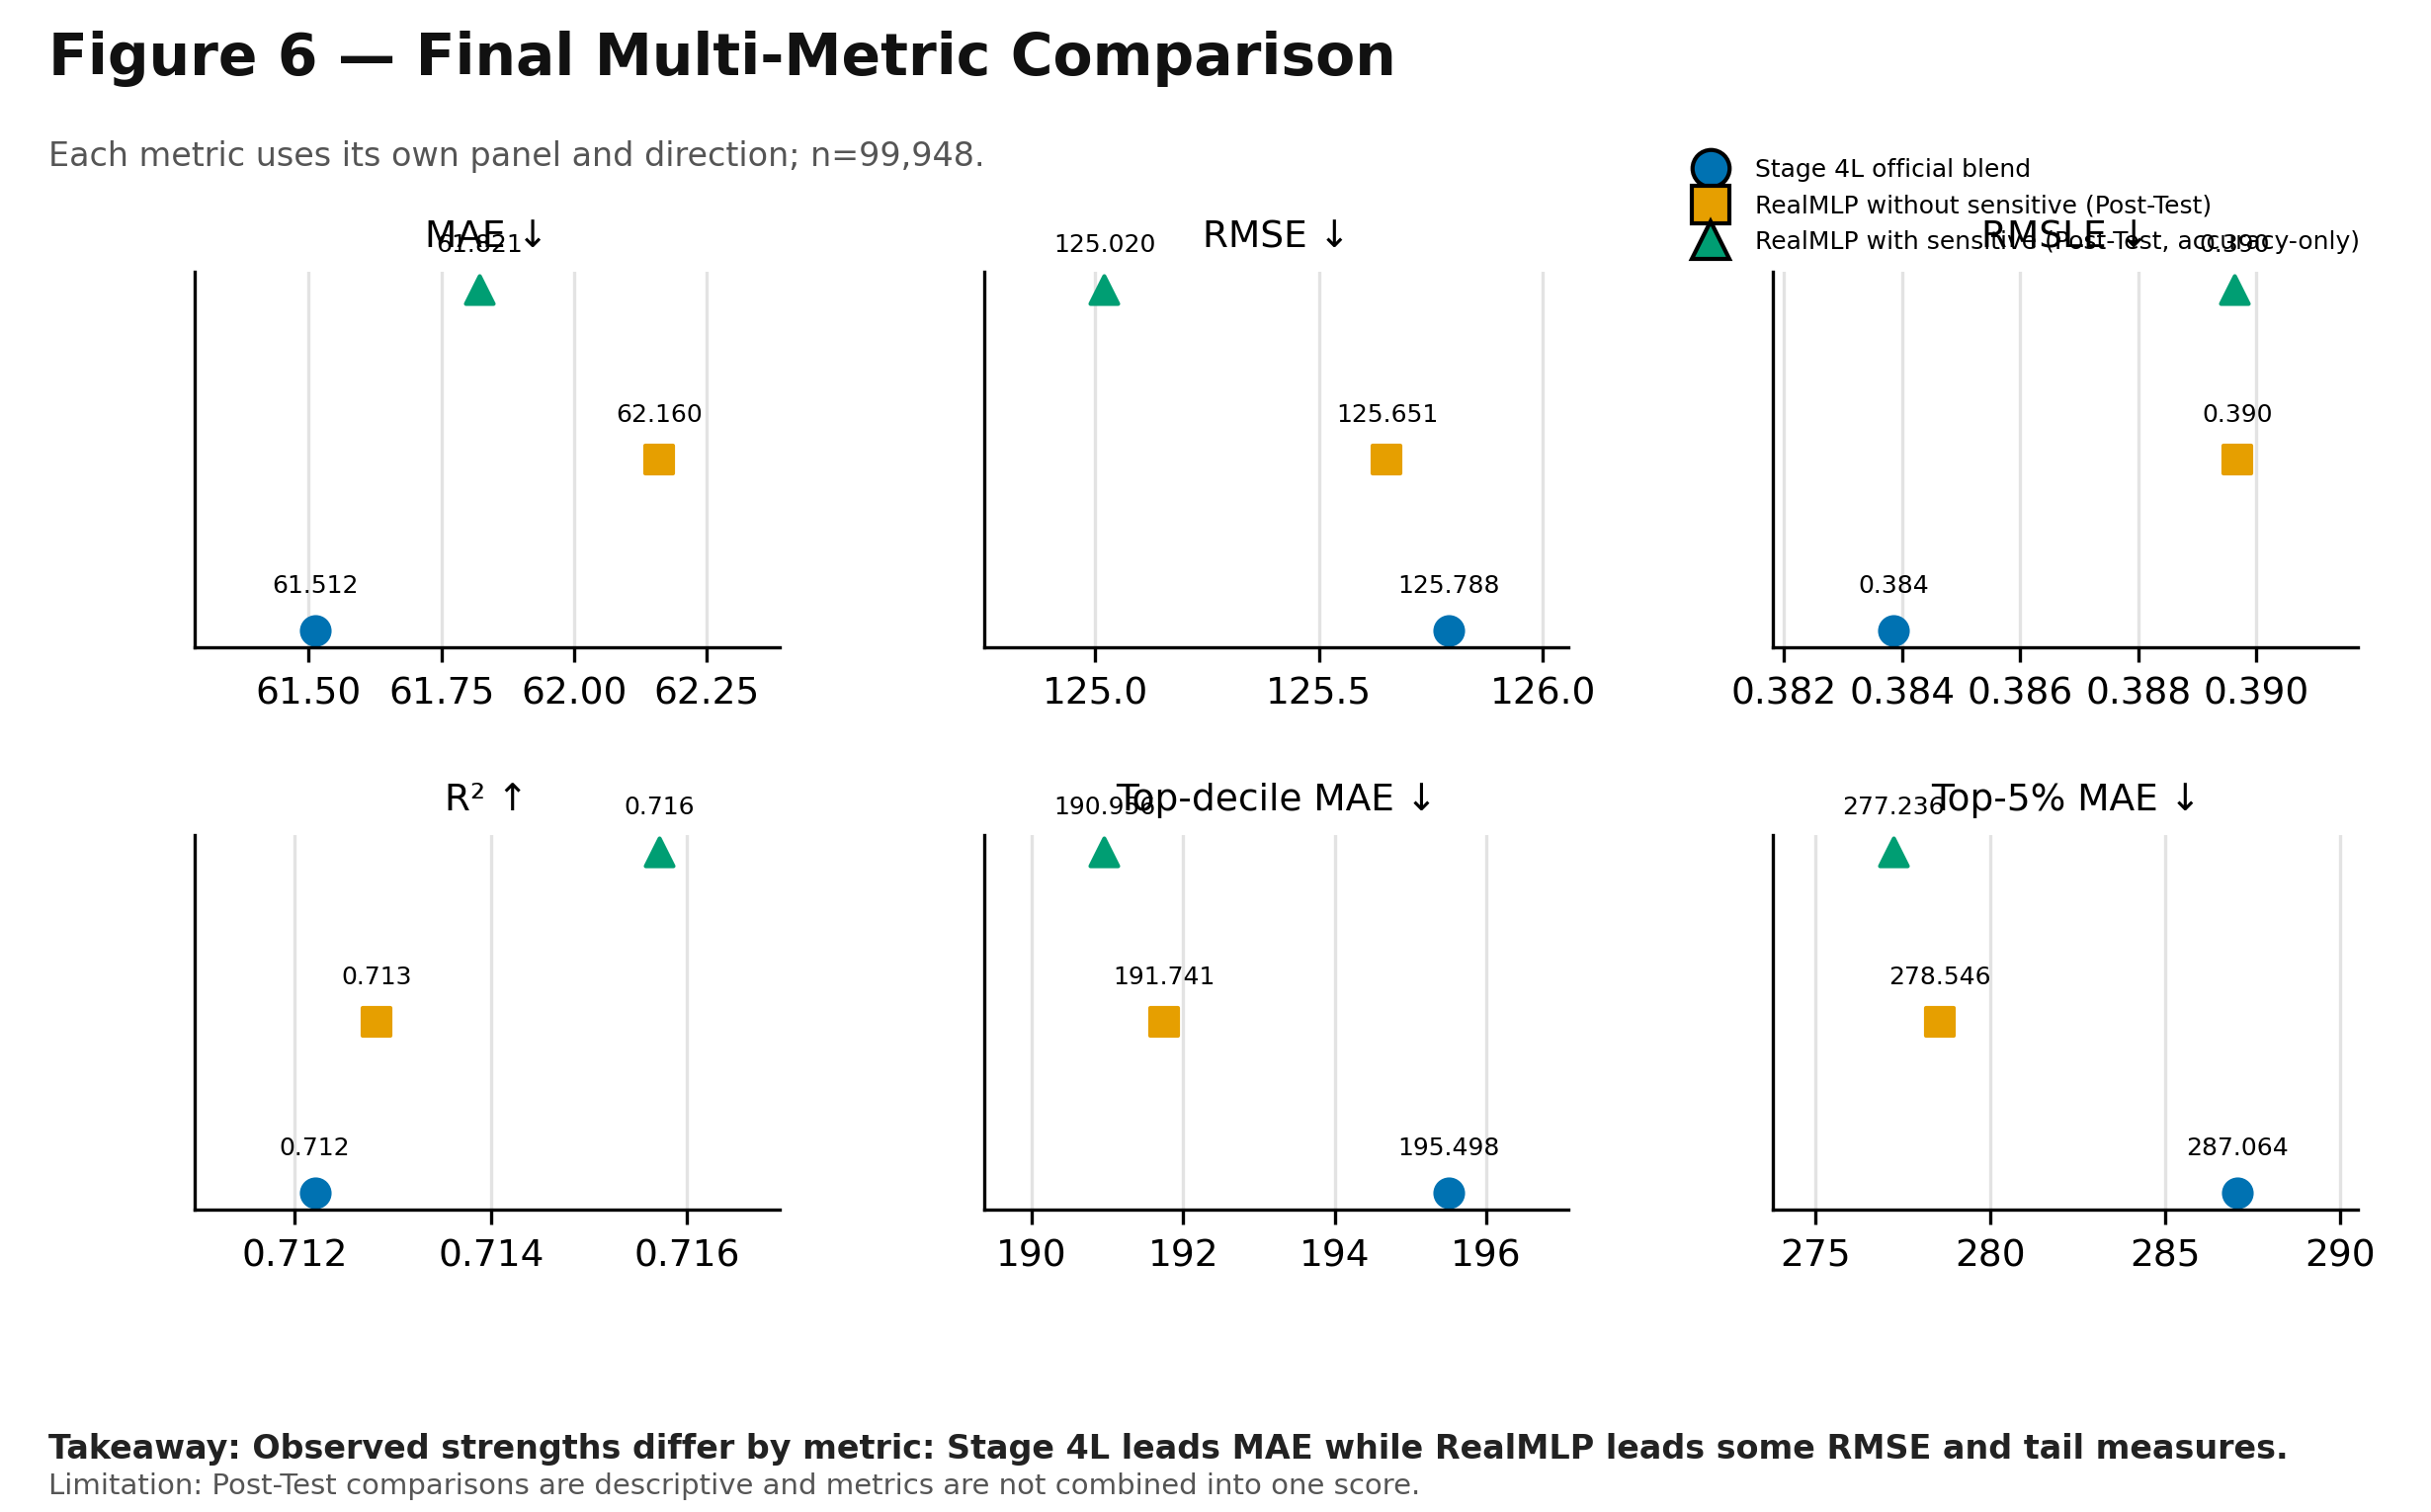

**Figure 6 — Final Multi-Metric Comparison**  
Figure 6. Final Multi-Metric Comparison. Each metric uses its own panel and direction; n=99,948.  
**Takeaway:** Observed strengths differ by metric: Stage 4L leads MAE while RealMLP leads some RMSE and tail measures.  
**Limitation:** Post-Test comparisons are descriptive and metrics are not combined into one score.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_06.png`

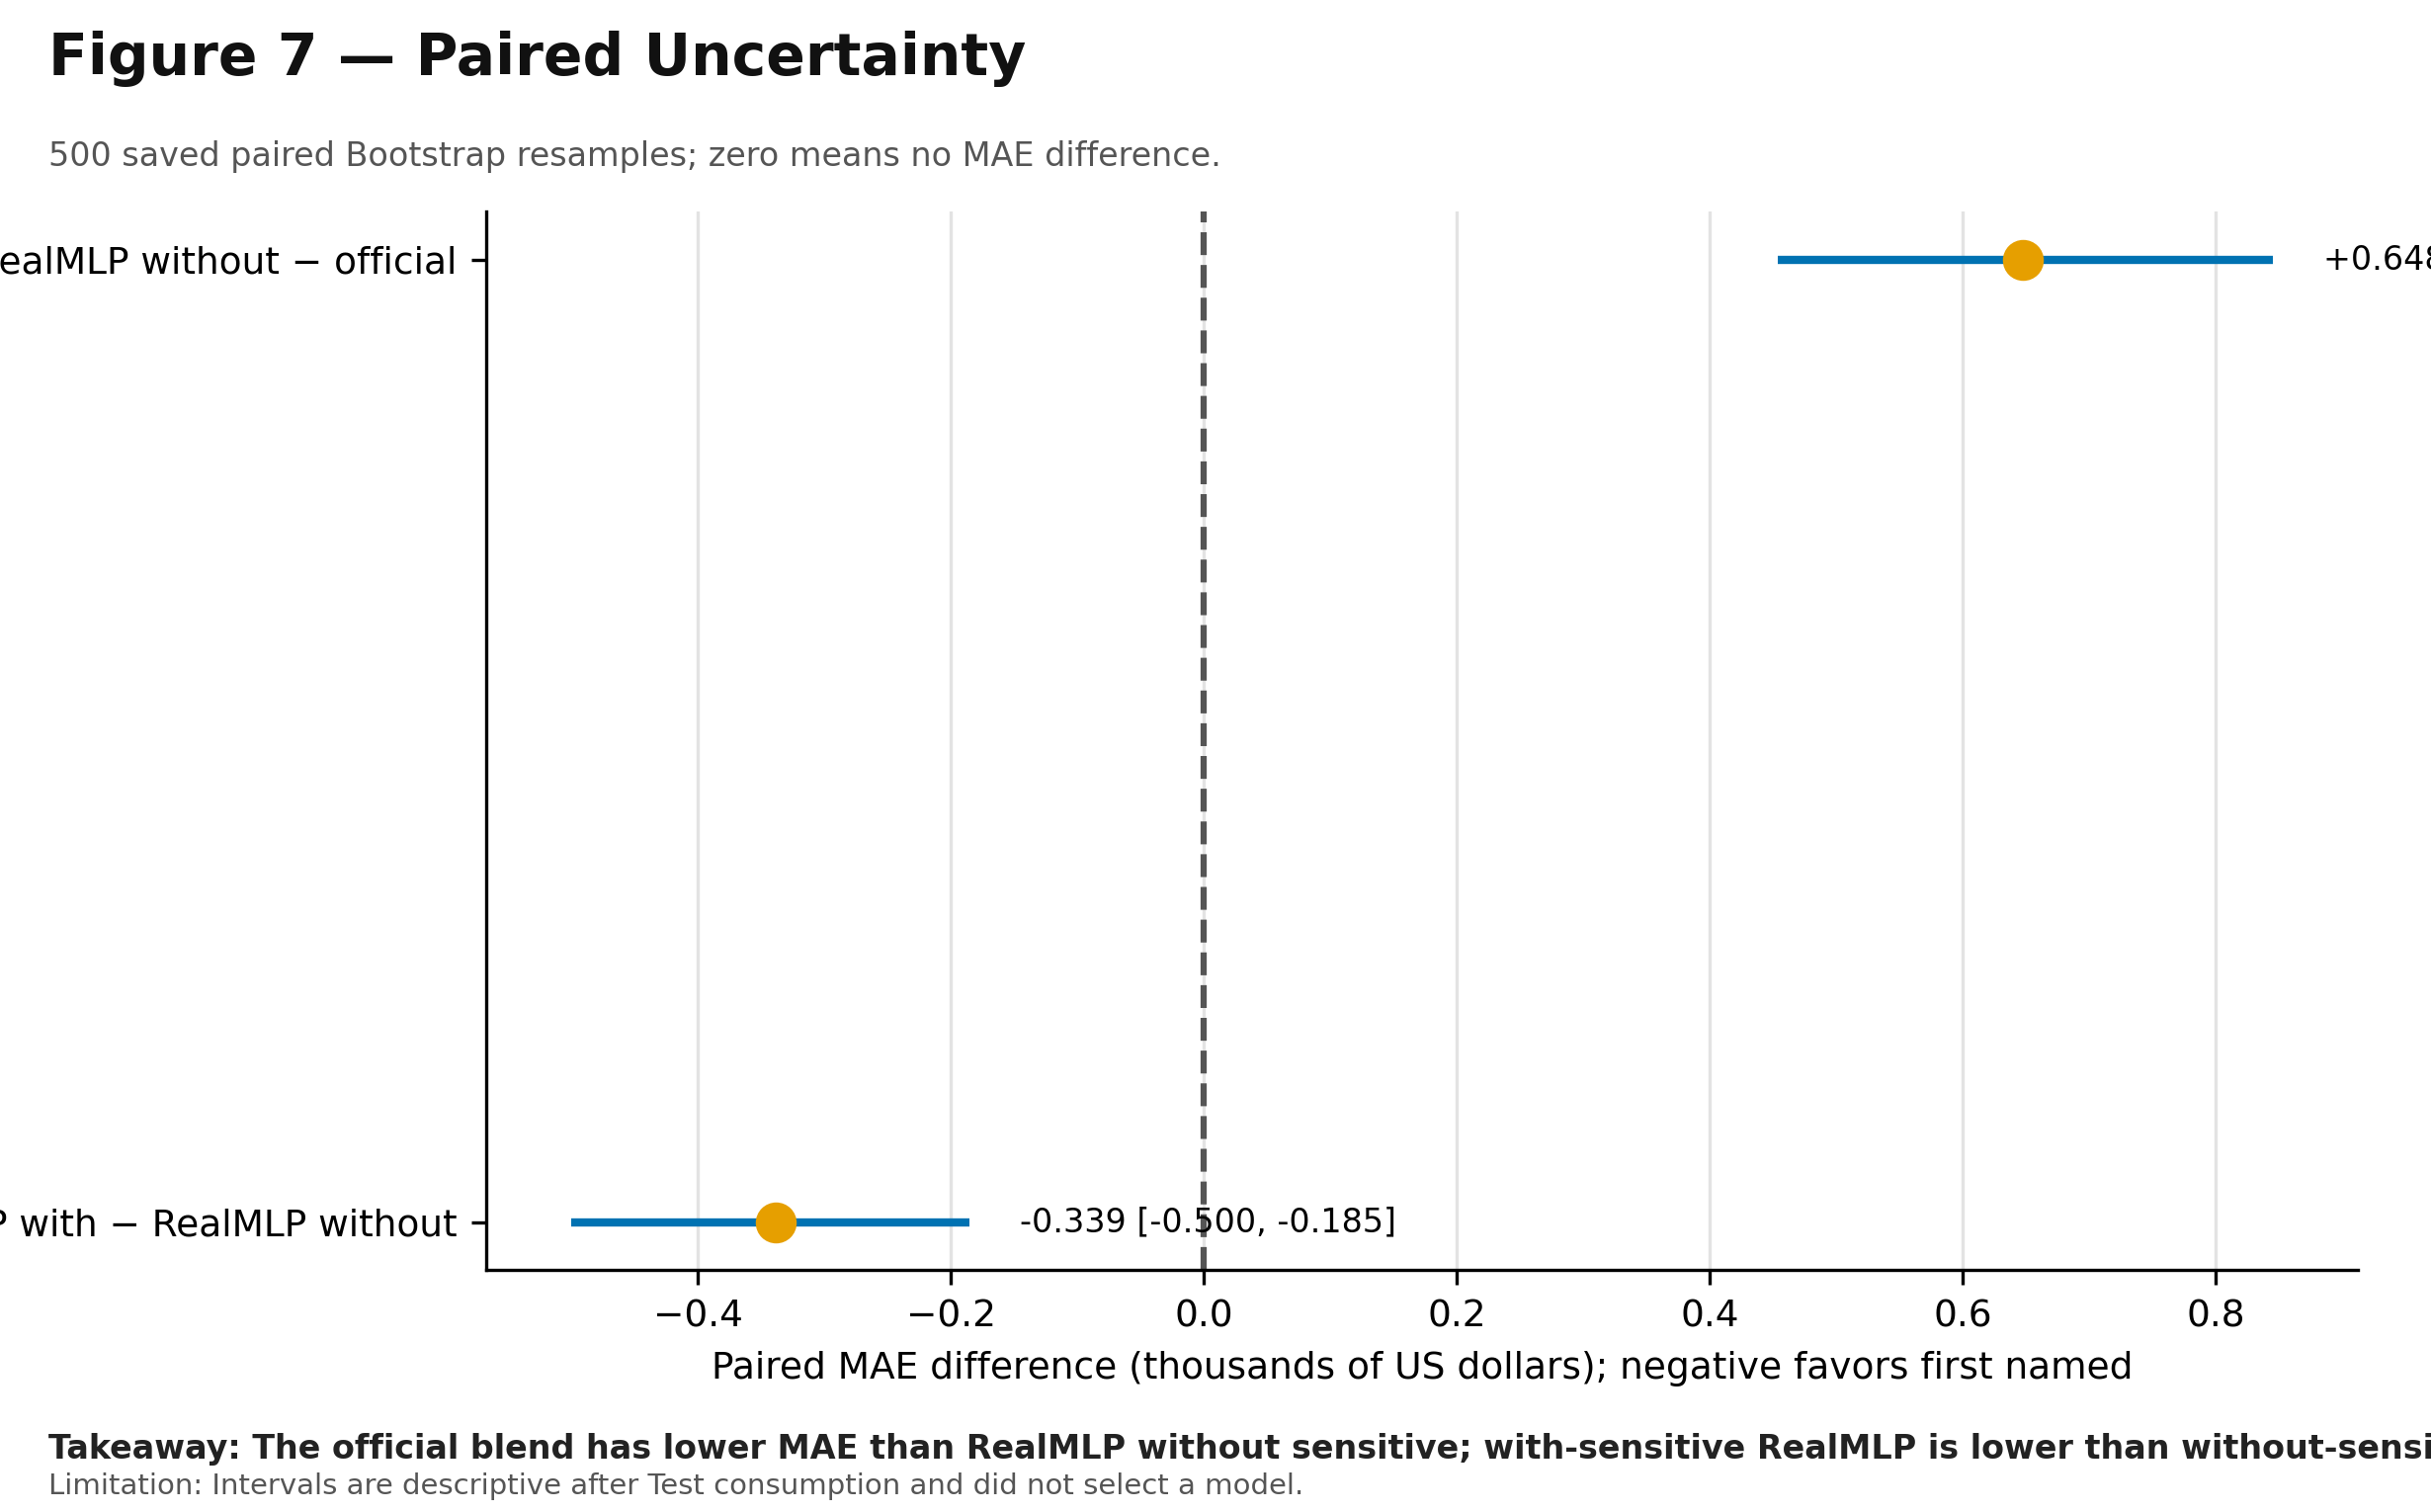

**Figure 7 — Paired Uncertainty**  
Figure 7. Paired Uncertainty. 500 saved paired Bootstrap resamples; zero means no MAE difference.  
**Takeaway:** The official blend has lower MAE than RealMLP without sensitive; with-sensitive RealMLP is lower than without-sensitive.  
**Limitation:** Intervals are descriptive after Test consumption and did not select a model.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_07.png`

**Saved paired uncertainty intervals**

comparison_id,interpretation
realmlp_without_minus_stage4l_primary,Negative values favor the first-named Candidate. This is descriptive and caused no selection.
realmlp_with_minus_without_sensitive,Negative values favor the first-named Candidate. This is descriptive and caused no selection.


*Evidence:* `artifacts/results/stage5/posttest_evaluation/stage5c_paired_bootstrap.csv`  
*SHA-256:* `9e49560e3a7fbb997e42018143bb945974157b6af8a97cf095767fac8a1e6b17`

**Role note:** both comparisons are Post-Test. The sensitive comparison is accuracy-only, and neither result promotes a model.

In [17]:
render_manifest_figure(6)
render_manifest_figure(7)
paired_path = "artifacts/results/stage5/posttest_evaluation/stage5c_paired_bootstrap.csv"
paired = read_table(paired_path)
visible_columns = [column for column in [
    "comparison_id", "candidate_a", "candidate_b", "point_mae_difference_a_minus_b",
    "ci95_lower", "ci95_upper", "win_proportion_a_lower_mae", "interpretation", "analysis_label"
] if column in paired.columns]
display_table_frame(paired.loc[:, visible_columns].copy(), "Saved paired uncertainty intervals")
render_evidence_note(paired_path)
display(Markdown("**Role note:** both comparisons are Post-Test. The sensitive comparison is accuracy-only, and neither result promotes a model."))


## 17. Ensemble Decision

The frozen 50/50 Deep–Boosting ensemble improved Validation MAE and passed its Bootstrap check, but its RMSE worsened by 0.346%, above the fixed 0.25% limit. A model can improve one metric and still fail a multi-condition gate, so the ensemble was rejected and received no Test prediction.


**Frozen Stage 5B acceptance gates**

Gate,Observed,Required,Pass
MAE Gate,0.440155,At least 0.30% improvement,True
RMSE Gate,0.345731,At most 0.25% worsening,False
Bootstrap Gate,-0.069453,Upper 95% bound below zero,True
Tail Gate,-1.221917,At least 1.00% improvement on tail path,True
Final decision,rejected,Every condition in one path,False


*Evidence:* `artifacts/results/stage5/deep_boosting_ensemble/stage5b_ensemble_decision.json`  
*SHA-256:* `90300c551a67db225d48fa98a637559eaa27e6d75a06795120805d94ce9e06cc`

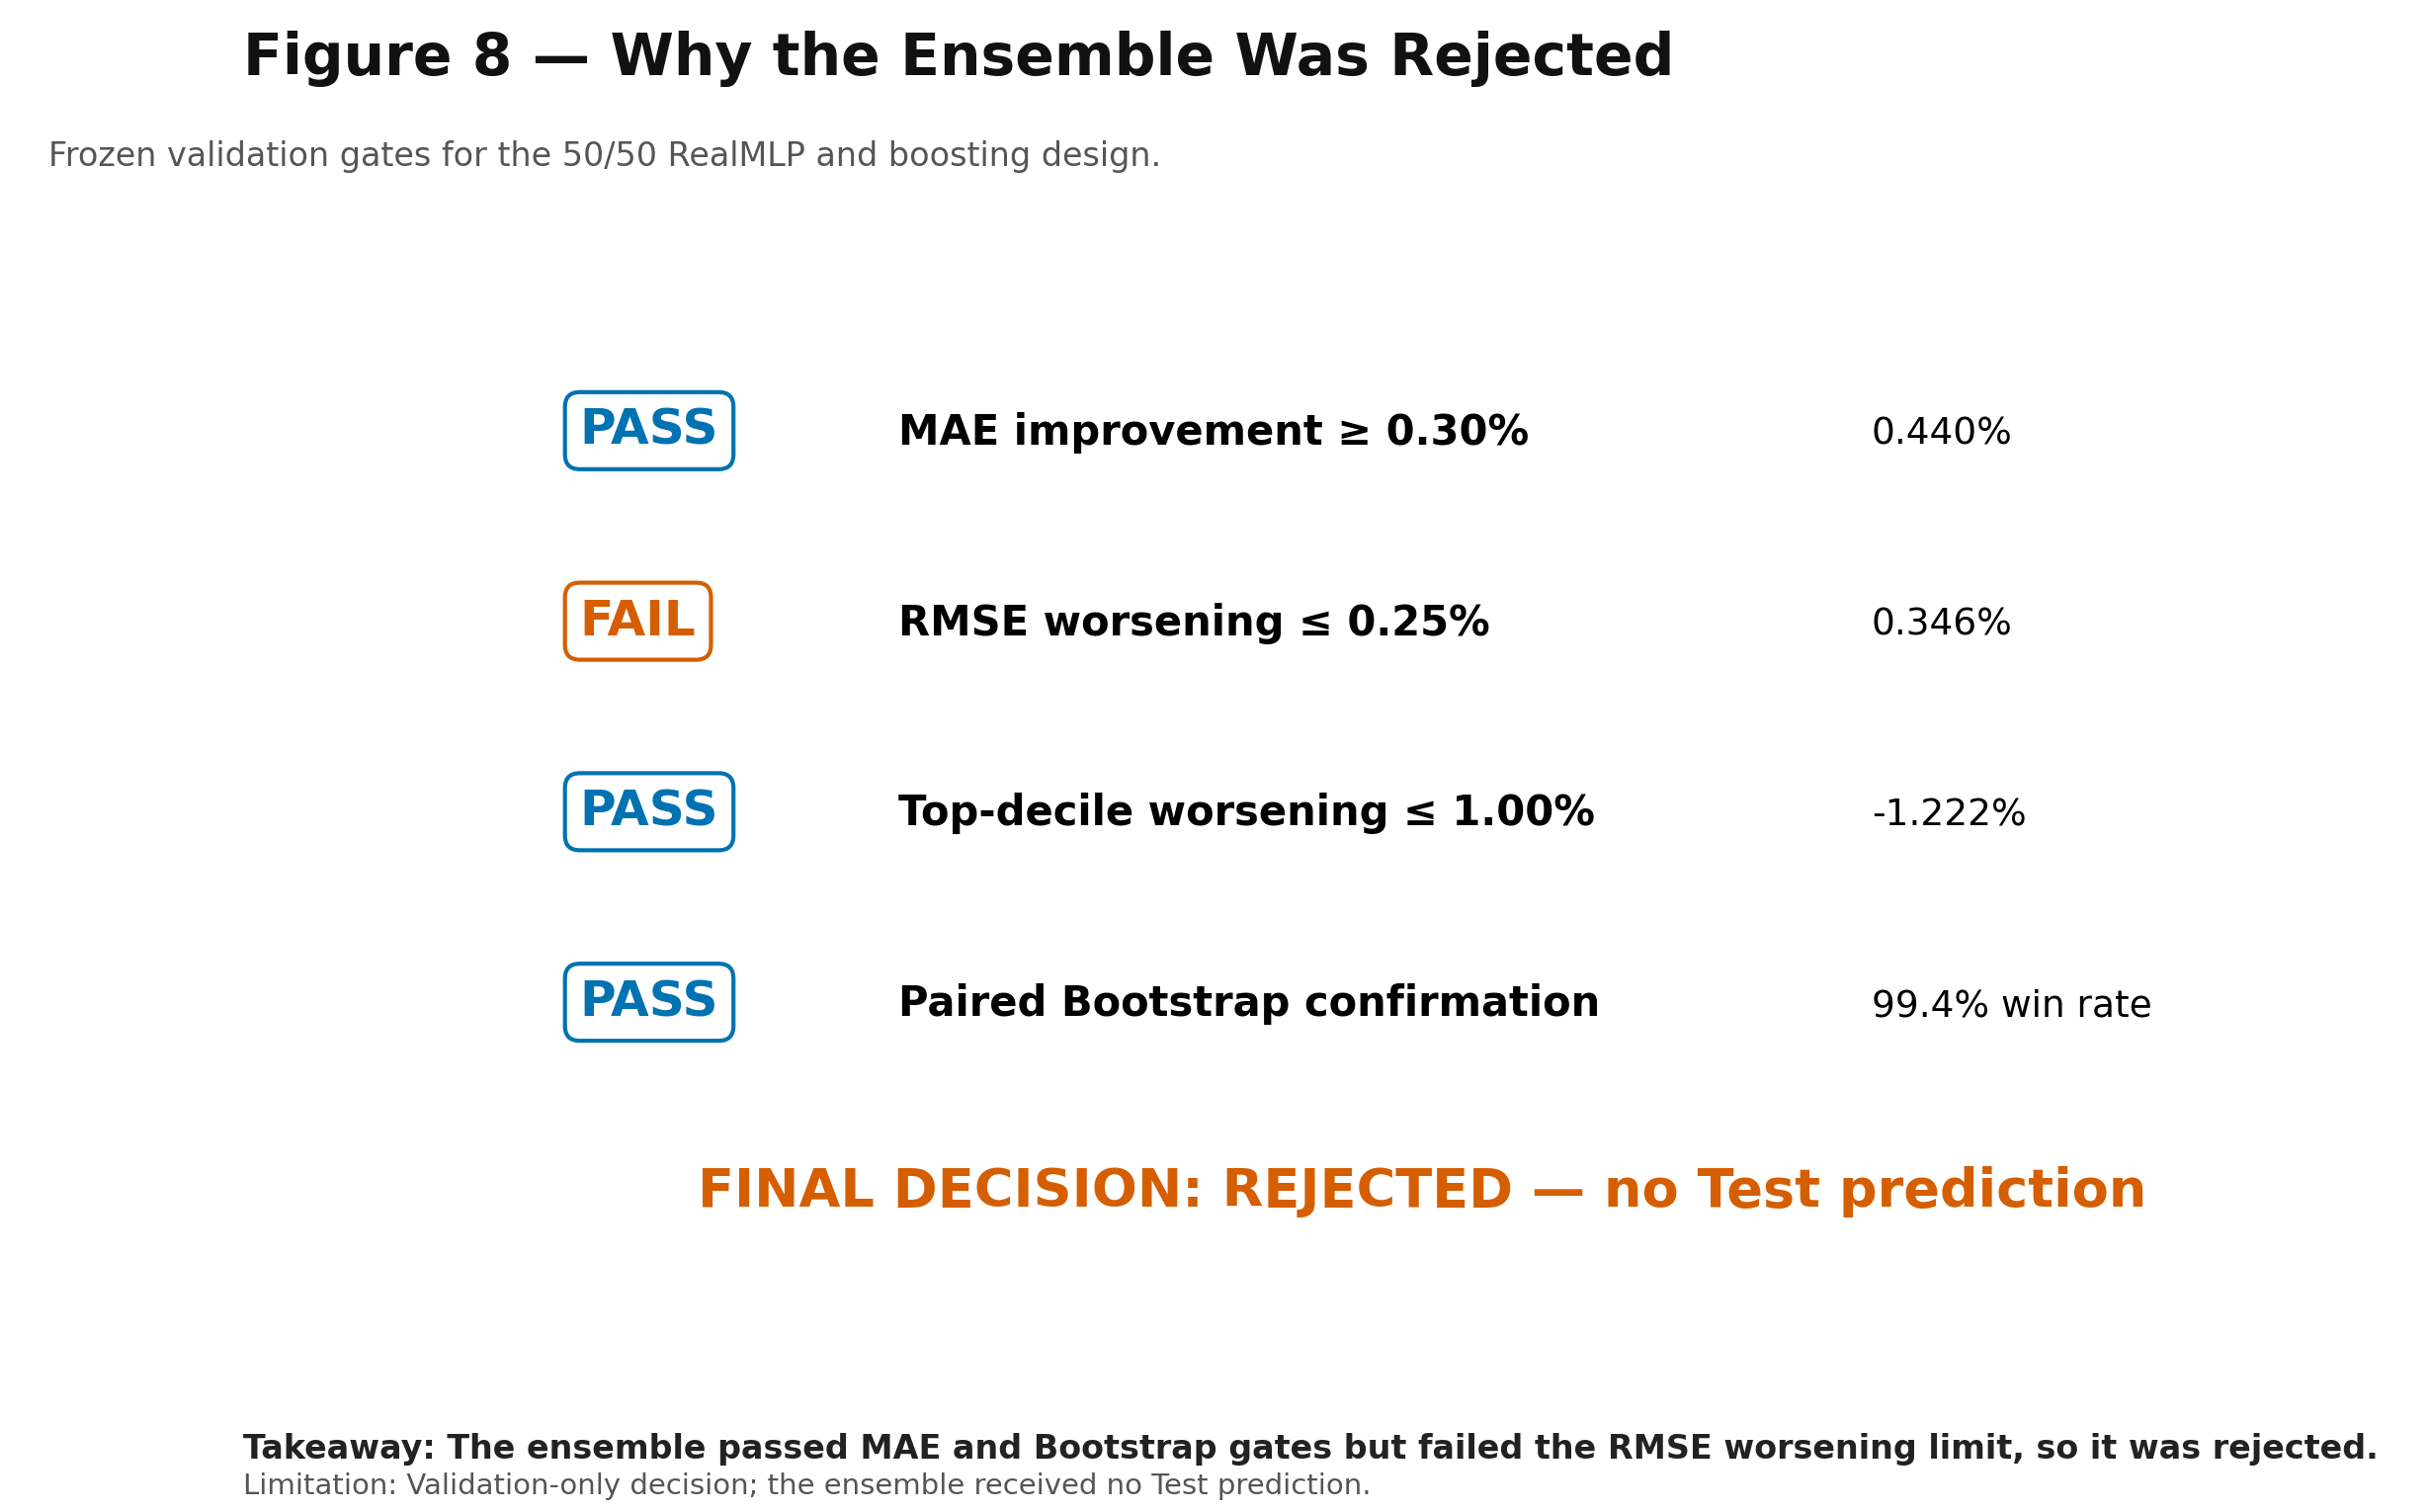

**Figure 8 — Why the Ensemble Was Rejected**  
Figure 8. Why the Ensemble Was Rejected. Frozen validation gates for the 50/50 RealMLP and boosting design.  
**Takeaway:** The ensemble passed MAE and Bootstrap gates but failed the RMSE worsening limit, so it was rejected.  
**Limitation:** Validation-only decision; the ensemble received no Test prediction.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_08.png`

In [18]:
ensemble_path = "artifacts/results/stage5/deep_boosting_ensemble/stage5b_ensemble_decision.json"
ensemble = read_json(ensemble_path)
gates = pd.DataFrame([
    {"Gate": "MAE Gate", "Observed": ensemble["improvement_vs_best_component_percent"], "Required": "At least 0.30% improvement", "Pass": ensemble["main_accuracy_gate"]["mae_improvement_at_least_0_30_percent"]},
    {"Gate": "RMSE Gate", "Observed": ensemble["rmse_worsening_vs_best_component_percent"], "Required": "At most 0.25% worsening", "Pass": ensemble["main_accuracy_gate"]["rmse_worsening_at_most_0_25_percent"]},
    {"Gate": "Bootstrap Gate", "Observed": ensemble["bootstrap"]["ci95_upper"], "Required": "Upper 95% bound below zero", "Pass": ensemble["bootstrap"]["confirmation_pass"]},
    {"Gate": "Tail Gate", "Observed": ensemble["top_decile_worsening_vs_best_component_percent"], "Required": "At least 1.00% improvement on tail path", "Pass": ensemble["tail_benefit_gate"]["top_decile_improvement_at_least_1_00_percent"]},
    {"Gate": "Final decision", "Observed": ensemble["ensemble_status"], "Required": "Every condition in one path", "Pass": False},
])
display_table_frame(gates, "Frozen Stage 5B acceptance gates")
render_evidence_note(ensemble_path)
render_manifest_figure(8)


## 18. Error Distribution and Concentration

Error is unevenly concentrated. For the official model, the worst 1%, 5%, and 10% of rows account for about 12.777%, 30.052%, and 42.712% of total absolute error. Average metrics therefore hide a small set of very difficult cases.


**Saved error-distribution summary**

candidate_label,row_count,mae,median_absolute_error,mean_signed_error,underprediction_rate,overprediction_rate,absolute_error_max,official_role
Stage 4L Official Boosting Blend,"99,948",61.512,35.590,-9.554,0.509,0.491,"7,245.142",official_pre_registered_primary
Frozen RealMLP Without Sensitive,"99,948",62.160,36.401,-7.014,0.503,0.497,"7,449.381",post_test_extension
Frozen RealMLP With Sensitive,"99,948",61.821,36.132,-6.441,0.501,0.499,"7,371.389",post_test_extension_accuracy_only


Full artifact: `artifacts/results/stage6/error_analysis/stage6_error_distribution_summary.csv` (3 rows).

**Worst 1%, 5%, and 10% error concentration**

candidate_label,worst_proportion,row_count,share_of_total_absolute_error_percent
Stage 4L Official Boosting Blend,0.010,"1,000",12.777
Stage 4L Official Boosting Blend,0.050,"4,998",30.052
Stage 4L Official Boosting Blend,0.100,"9,995",42.712
Frozen RealMLP Without Sensitive,0.010,"1,000",12.612
Frozen RealMLP Without Sensitive,0.050,"4,998",29.745
Frozen RealMLP Without Sensitive,0.100,"9,995",42.364
Frozen RealMLP With Sensitive,0.010,"1,000",12.707
Frozen RealMLP With Sensitive,0.050,"4,998",29.810
Frozen RealMLP With Sensitive,0.100,"9,995",42.399


Full artifact: `artifacts/results/stage6/error_analysis/stage6_error_concentration.csv` (9 rows).

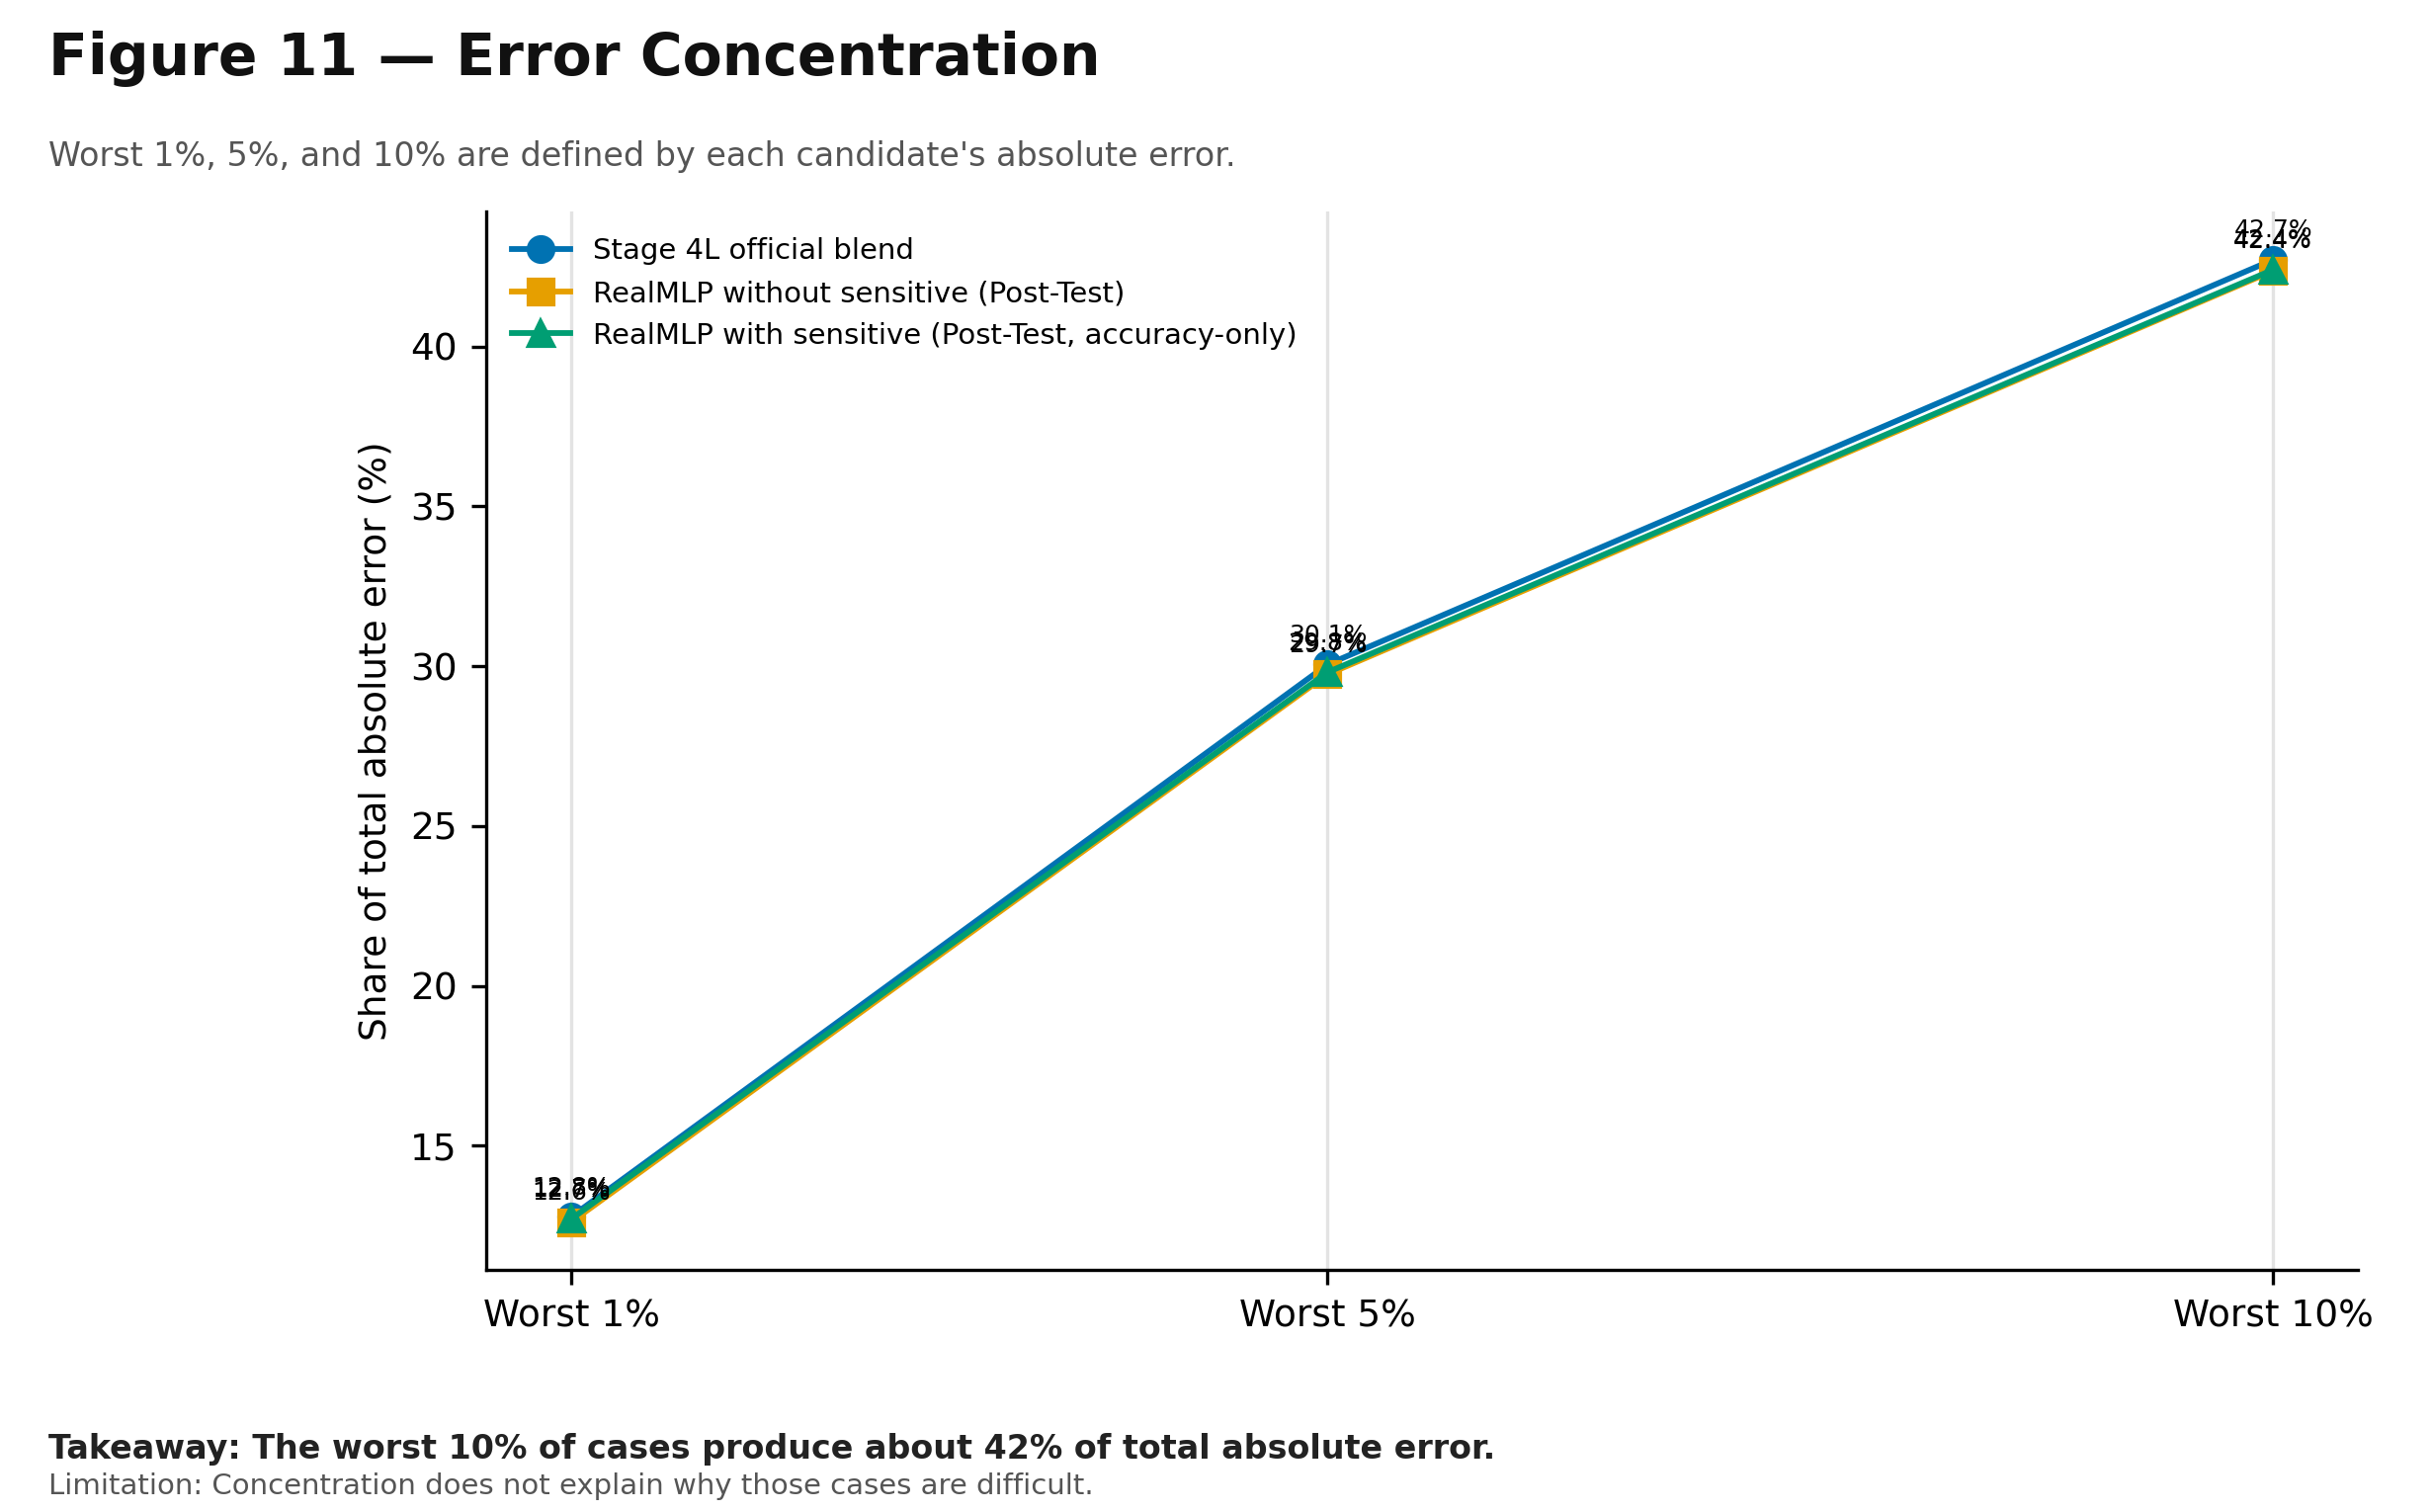

**Figure 11 — Error Concentration**  
Figure 11. Error Concentration. Worst 1%, 5%, and 10% are defined by each candidate's absolute error.  
**Takeaway:** The worst 10% of cases produce about 42% of total absolute error.  
**Limitation:** Concentration does not explain why those cases are difficult.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_11.png`

In [19]:
render_table(
    "artifacts/results/stage6/error_analysis/stage6_error_distribution_summary.csv",
    columns=["candidate_label", "row_count", "mae", "median_absolute_error", "mean_signed_error", "underprediction_rate", "overprediction_rate", "absolute_error_max", "official_role"],
    caption="Saved error-distribution summary",
)
render_table(
    "artifacts/results/stage6/error_analysis/stage6_error_concentration.csv",
    columns=["candidate_label", "worst_proportion", "row_count", "share_of_total_absolute_error_percent"],
    caption="Worst 1%, 5%, and 10% error concentration",
)
render_manifest_figure(11)


## 19. Target-Decile and Tail Analysis

Errors rise strongly for larger target values. The compact decile view below shows the official model only; the full saved table contains all three candidates. The separate tail table shows top-decile and top-five-percent performance for every candidate.


**Official model by target decile (selection criterion: official candidate only)**

target_decile,row_count,target_min,target_max,target_mean,mae,rmse,mean_signed_error,underprediction_rate
1,"10,221",1.000,65.000,31.981,26.882,46.991,22.073,0.276
2,"9,892",66.000,106.000,87.736,41.905,61.629,33.635,0.232
3,"9,951",107.000,137.000,122.492,36.781,54.764,23.704,0.329
4,"10,095",138.000,166.000,152.045,37.375,56.333,17.335,0.414
5,"9,892",167.000,197.000,181.550,38.010,56.549,7.533,0.502
6,"9,936",198.000,232.000,214.156,44.971,64.876,3.909,0.551
7,"10,012",233.000,277.000,253.876,49.710,69.379,-8.603,0.622
8,"10,084",278.000,344.000,307.769,61.549,82.448,-19.727,0.671
9,"9,884",345.000,444.000,391.804,82.839,107.576,-36.212,0.706
10,"9,981",445.000,"10,000.000",726.471,195.913,340.155,-139.716,0.791


Full three-candidate artifact: `artifacts/results/stage6/error_analysis/stage6_target_decile_analysis.csv` (30 rows).

**Saved target-tail analysis**

candidate_label,tail_definition,row_count,target_mean,mae,rmse,mean_signed_error,underprediction_rate
Stage 4L Official Boosting Blend,top_decile,"10,017",725.456,195.498,339.592,-139.387,0.791
Stage 4L Official Boosting Blend,top_five_percent,"5,006",938.466,287.064,459.931,-222.193,0.830
Frozen RealMLP Without Sensitive,top_decile,"10,017",725.456,191.741,334.904,-124.876,0.761
Frozen RealMLP Without Sensitive,top_five_percent,"5,006",938.466,278.546,451.759,-200.602,0.798
Frozen RealMLP With Sensitive,top_decile,"10,017",725.456,190.956,333.025,-120.035,0.760
Frozen RealMLP With Sensitive,top_five_percent,"5,006",938.466,277.236,448.983,-190.320,0.789


Full artifact: `artifacts/results/stage6/error_analysis/stage6_target_tail_analysis.csv` (6 rows).

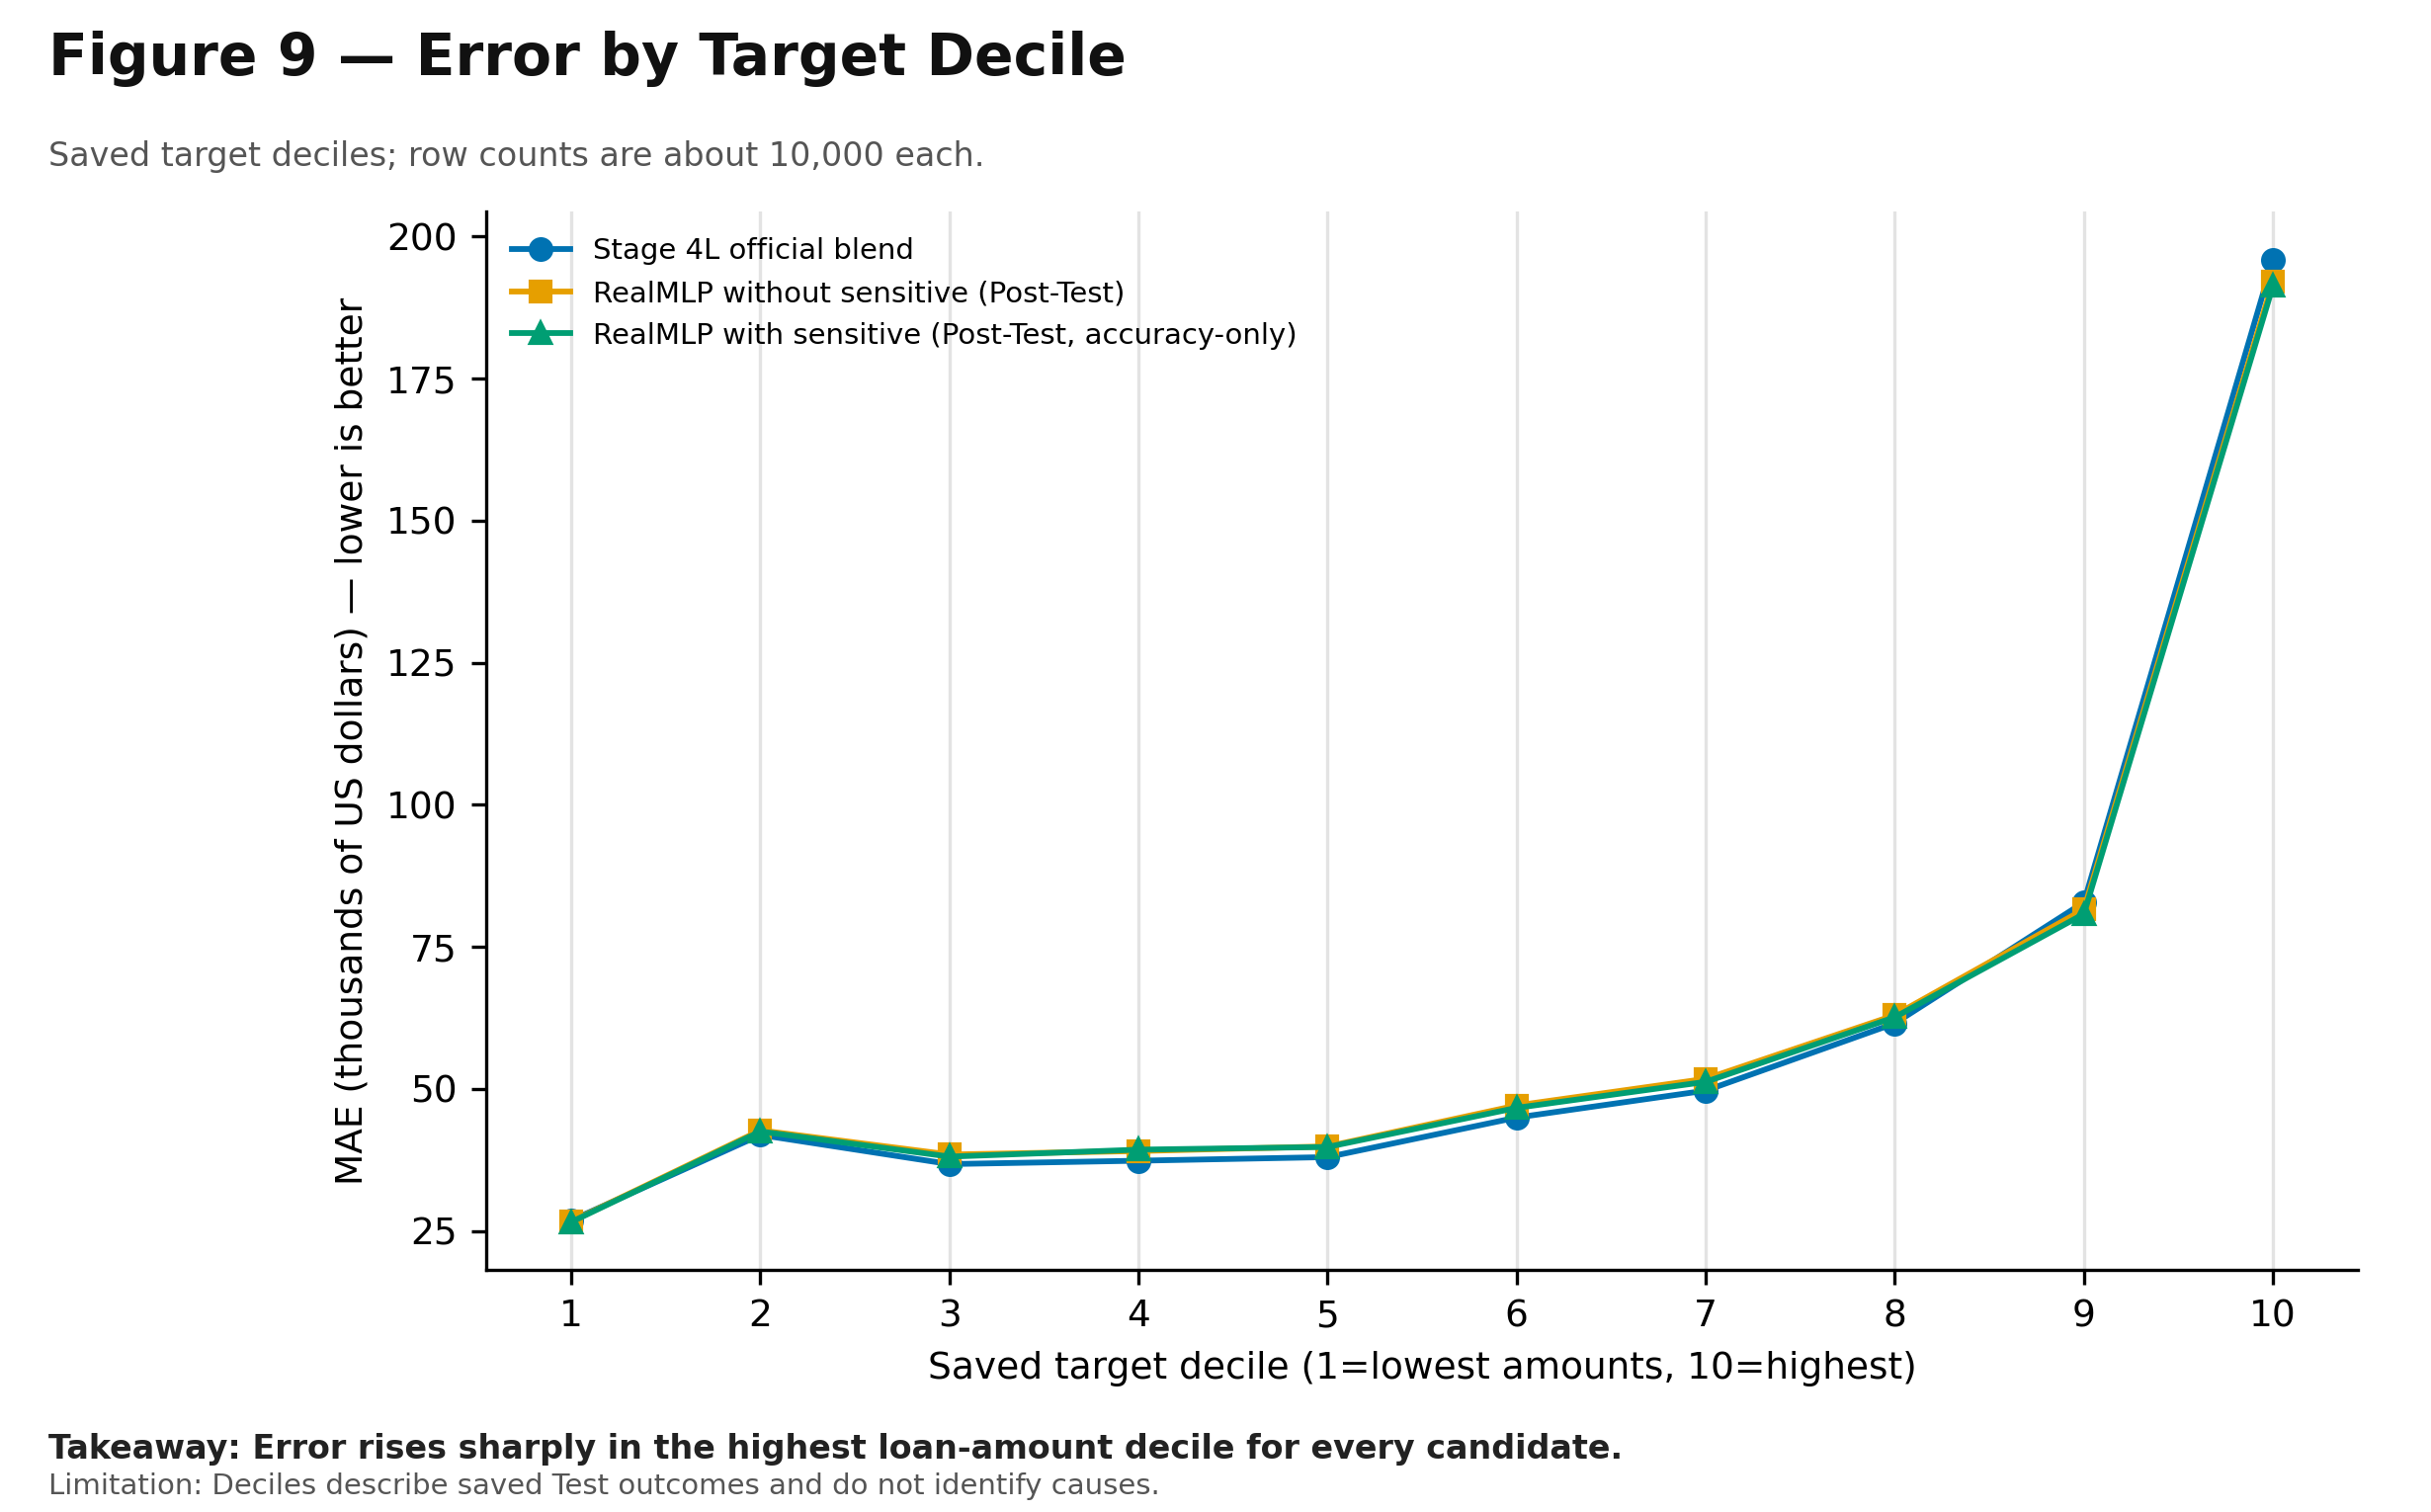

**Figure 9 — Error by Target Decile**  
Figure 9. Error by Target Decile. Saved target deciles; row counts are about 10,000 each.  
**Takeaway:** Error rises sharply in the highest loan-amount decile for every candidate.  
**Limitation:** Deciles describe saved Test outcomes and do not identify causes.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_09.png`

In [20]:
decile_path = "artifacts/results/stage6/error_analysis/stage6_target_decile_analysis.csv"
deciles = read_table(decile_path)
official_deciles = deciles.loc[deciles["official_role"].eq("official_pre_registered_primary") if "official_role" in deciles.columns else deciles["candidate_id"].eq("stage4l__blend__without_sensitive"), [
    "target_decile", "row_count", "target_min", "target_max", "target_mean", "mae", "rmse", "mean_signed_error", "underprediction_rate"
]].copy()
display_table_frame(official_deciles, "Official model by target decile (selection criterion: official candidate only)")
display(Markdown(f"Full three-candidate artifact: `{decile_path}` ({len(deciles):,} rows)."))
render_table(
    "artifacts/results/stage6/error_analysis/stage6_target_tail_analysis.csv",
    columns=["candidate_label", "tail_definition", "row_count", "target_mean", "mae", "rmse", "mean_signed_error", "underprediction_rate"],
    caption="Saved target-tail analysis",
)
render_manifest_figure(9)


## 20. Underprediction and Overprediction

Signed error is prediction minus actual value. Negative values mean underprediction and positive values mean overprediction. The largest-loan groups have strong negative signed error and high underprediction rates, which is a key project limitation.


**Overall and large-target under/over summary**

candidate_label,scope_type,scope_value,row_count,underprediction_rate,overprediction_rate,mean_signed_error,mean_underprediction_magnitude,p90_underprediction_magnitude
Stage 4L Official Boosting Blend,overall,all,"99,948",0.509,0.491,-9.554,69.804,146.214
Stage 4L Official Boosting Blend,target_decile,10,"9,981",0.791,0.209,-139.716,212.208,432.236
Stage 4L Official Boosting Blend,frozen_target_tail,top_decile,"10,017",0.791,0.209,-139.387,211.777,431.234
Stage 4L Official Boosting Blend,frozen_target_tail,top_five_percent,"5,006",0.830,0.170,-222.193,306.780,605.016
Frozen RealMLP Without Sensitive,overall,all,"99,948",0.503,0.497,-7.014,68.743,143.697
Frozen RealMLP Without Sensitive,target_decile,10,"9,981",0.761,0.239,-125.172,208.403,421.743
Frozen RealMLP Without Sensitive,frozen_target_tail,top_decile,"10,017",0.761,0.239,-124.876,208.025,420.850
Frozen RealMLP Without Sensitive,frozen_target_tail,top_five_percent,"5,006",0.798,0.202,-200.602,300.127,597.738
Frozen RealMLP With Sensitive,overall,all,"99,948",0.501,0.499,-6.441,68.192,141.972
Frozen RealMLP With Sensitive,target_decile,10,"9,981",0.760,0.240,-120.304,204.991,420.041


Selection: all overall rows plus saved top-decile/top-five-percent scopes. Full artifact: `artifacts/results/stage6/error_analysis/stage6_under_over_analysis.csv` (39 rows).

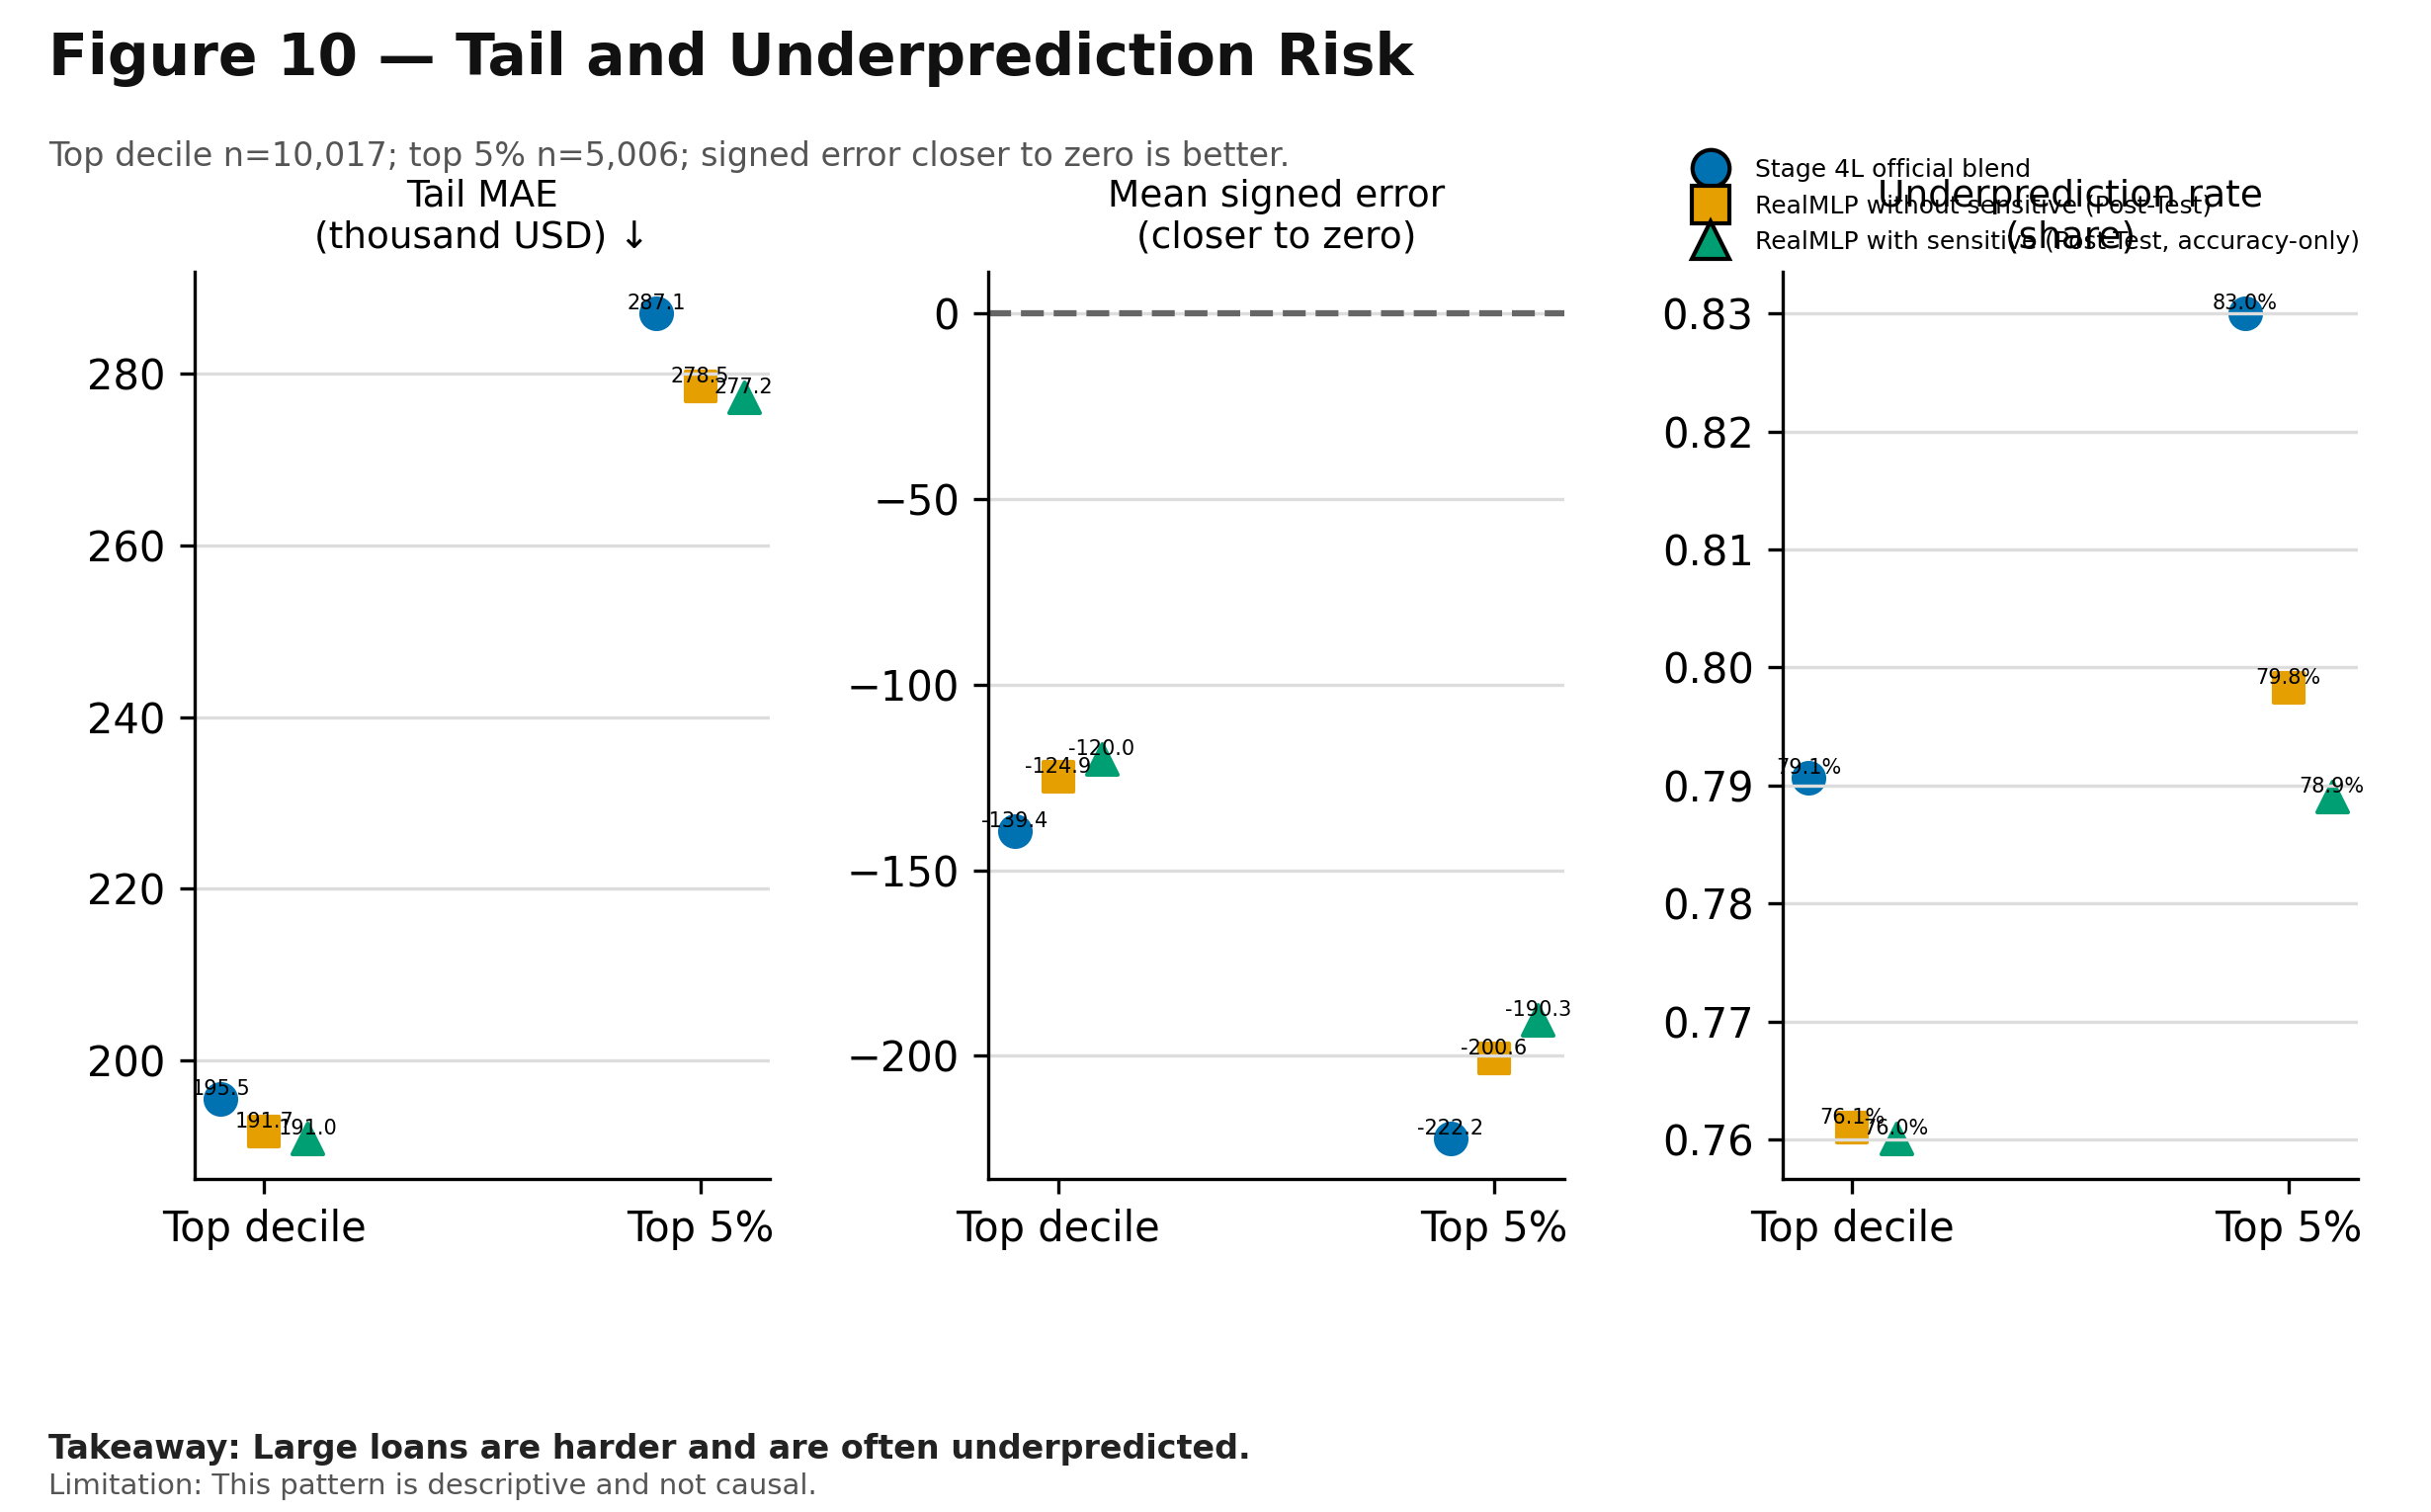

**Figure 10 — Tail and Underprediction Risk**  
Figure 10. Tail and Underprediction Risk. Top decile n=10,017; top 5% n=5,006; signed error closer to zero is better.  
**Takeaway:** Large loans are harder and are often underpredicted.  
**Limitation:** This pattern is descriptive and not causal.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_10.png`

In [21]:
under_path = "artifacts/results/stage6/error_analysis/stage6_under_over_analysis.csv"
under = read_table(under_path)
selected = under.loc[
    under["scope_type"].eq("overall") | under["scope_value"].astype(str).isin(["10", "top_decile", "top_five_percent"]),
    ["candidate_label", "scope_type", "scope_value", "row_count", "underprediction_rate", "overprediction_rate", "mean_signed_error", "mean_underprediction_magnitude", "p90_underprediction_magnitude"]
].copy()
display_table_frame(selected, "Overall and large-target under/over summary")
display(Markdown(f"Selection: all overall rows plus saved top-decile/top-five-percent scopes. Full artifact: `{under_path}` ({len(under):,} rows)."))
render_manifest_figure(10)


## 21. Fairness Scope

Stage 7 is descriptive fairness analysis for approved applications only. It does not study approval fairness, access to credit, legal compliance, or causal effects. Comparisons involving sensitive Features are observational and the Stage 5C sensitive-mode result is accuracy-only.


In [22]:
display(Markdown('''
**Fairness scope boundary**

- Population: approved applications only.
- Question: descriptive differences in saved prediction errors across groups.
- Not assessed: approval or rejection fairness, credit access, legal compliance, or causality.
- Sensitive-mode comparison: observational accuracy evidence only.
- Small groups: visible under the frozen suppression rules, without unsupported quantitative conclusions.
'''))
render_evidence_note("artifacts/results/stage7/fairness/stage7_fairness_summary.json")



**Fairness scope boundary**

- Population: approved applications only.
- Question: descriptive differences in saved prediction errors across groups.
- Not assessed: approval or rejection fairness, credit access, legal compliance, or causality.
- Sensitive-mode comparison: observational accuracy evidence only.
- Small groups: visible under the frozen suppression rules, without unsupported quantitative conclusions.


*Evidence:* `artifacts/results/stage7/fairness/stage7_fairness_summary.json`  
*SHA-256:* `8cff68033e07640dfdf86e07ea4086555ec933dbf68ee93ba72eda241ba9d03b`

## 22. Fairness Findings

Aggregate error differences exist across recorded groups, and adding sensitive Features did not remove every disparity. Better overall MAE does not guarantee smaller group gaps. These findings are descriptive, not a fairness certification or a causal conclusion.


**Aggregate fairness summary**

Summary,Value
Status,PASS
Test rows,99948
Sensitive fields,8
Public row-level sensitive files,0
Maximum saved MAE gap,39.687590
Approval fairness assessed,False
Legal or causal conclusion,False


**Aggregate group-disparity table (no row-level sensitive data)**

candidate_id,sensitive_field,eligible_group_count,worst_minus_best_mae_gap,worst_to_best_mae_ratio,maximum_absolute_mean_signed_error,underprediction_rate_spread,target_standardized_mae_gap,data_coverage_percentage
stage4l__blend__without_sensitive,applicant_ethnicity_name,2,20.401,1.483,10.033,0.005,15.474,85.543
stage4l__blend__without_sensitive,co_applicant_ethnicity_name,2,23.282,1.468,12.202,0.016,17.017,83.566
stage4l__blend__without_sensitive,applicant_race_name_1,4,38.863,1.900,18.543,0.060,13.427,84.211
stage4l__blend__without_sensitive,co_applicant_race_name_1,3,39.688,1.747,21.745,0.057,13.444,81.503
stage4l__blend__without_sensitive,applicant_sex_name,2,12.983,1.251,12.584,0.033,4.308,90.810
stage4l__blend__without_sensitive,co_applicant_sex_name,2,6.432,1.098,14.339,0.051,1.016,89.439
stage4l__blend__without_sensitive,minority_population,6,22.001,1.482,12.413,0.036,19.113,100.000
stage4l__blend__without_sensitive,majority_minority_tract,2,11.987,1.229,11.117,0.008,12.433,100.000
stage5c__realmlp__without_sensitive__test_evaluation,applicant_ethnicity_name,2,20.288,1.472,7.754,0.003,15.443,85.543
stage5c__realmlp__without_sensitive__test_evaluation,co_applicant_ethnicity_name,2,23.253,1.461,9.851,0.018,17.152,83.566


**Accuracy-versus-disparity trade-off**

sensitive_field,overall_mae_change_with_minus_without,raw_mae_gap_change,target_standardized_mae_gap_change,maximum_absolute_signed_bias_change,underprediction_rate_spread_change,interpretation
applicant_ethnicity_name,-0.339,-0.280,-0.525,-0.766,-0.003,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.
co_applicant_ethnicity_name,-0.339,-0.039,0.013,-0.991,-0.018,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.
applicant_race_name_1,-0.339,-0.471,1.658,-8.949,-0.051,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.
co_applicant_race_name_1,-0.339,-0.425,0.729,-8.443,-0.025,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.
applicant_sex_name,-0.339,-0.070,-0.330,-2.591,-0.025,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.
co_applicant_sex_name,-0.339,0.230,0.764,-2.842,-0.045,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.
minority_population,-0.339,0.517,0.398,-2.493,-0.021,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.
majority_minority_tract,-0.339,0.398,0.405,-1.204,-0.015,Better overall MAE does not guarantee smaller group disparities; no causal or deployment recommendation is made.


*Evidence:* `artifacts/results/stage7/fairness/stage7_fairness_summary.json`  
*SHA-256:* `8cff68033e07640dfdf86e07ea4086555ec933dbf68ee93ba72eda241ba9d03b`

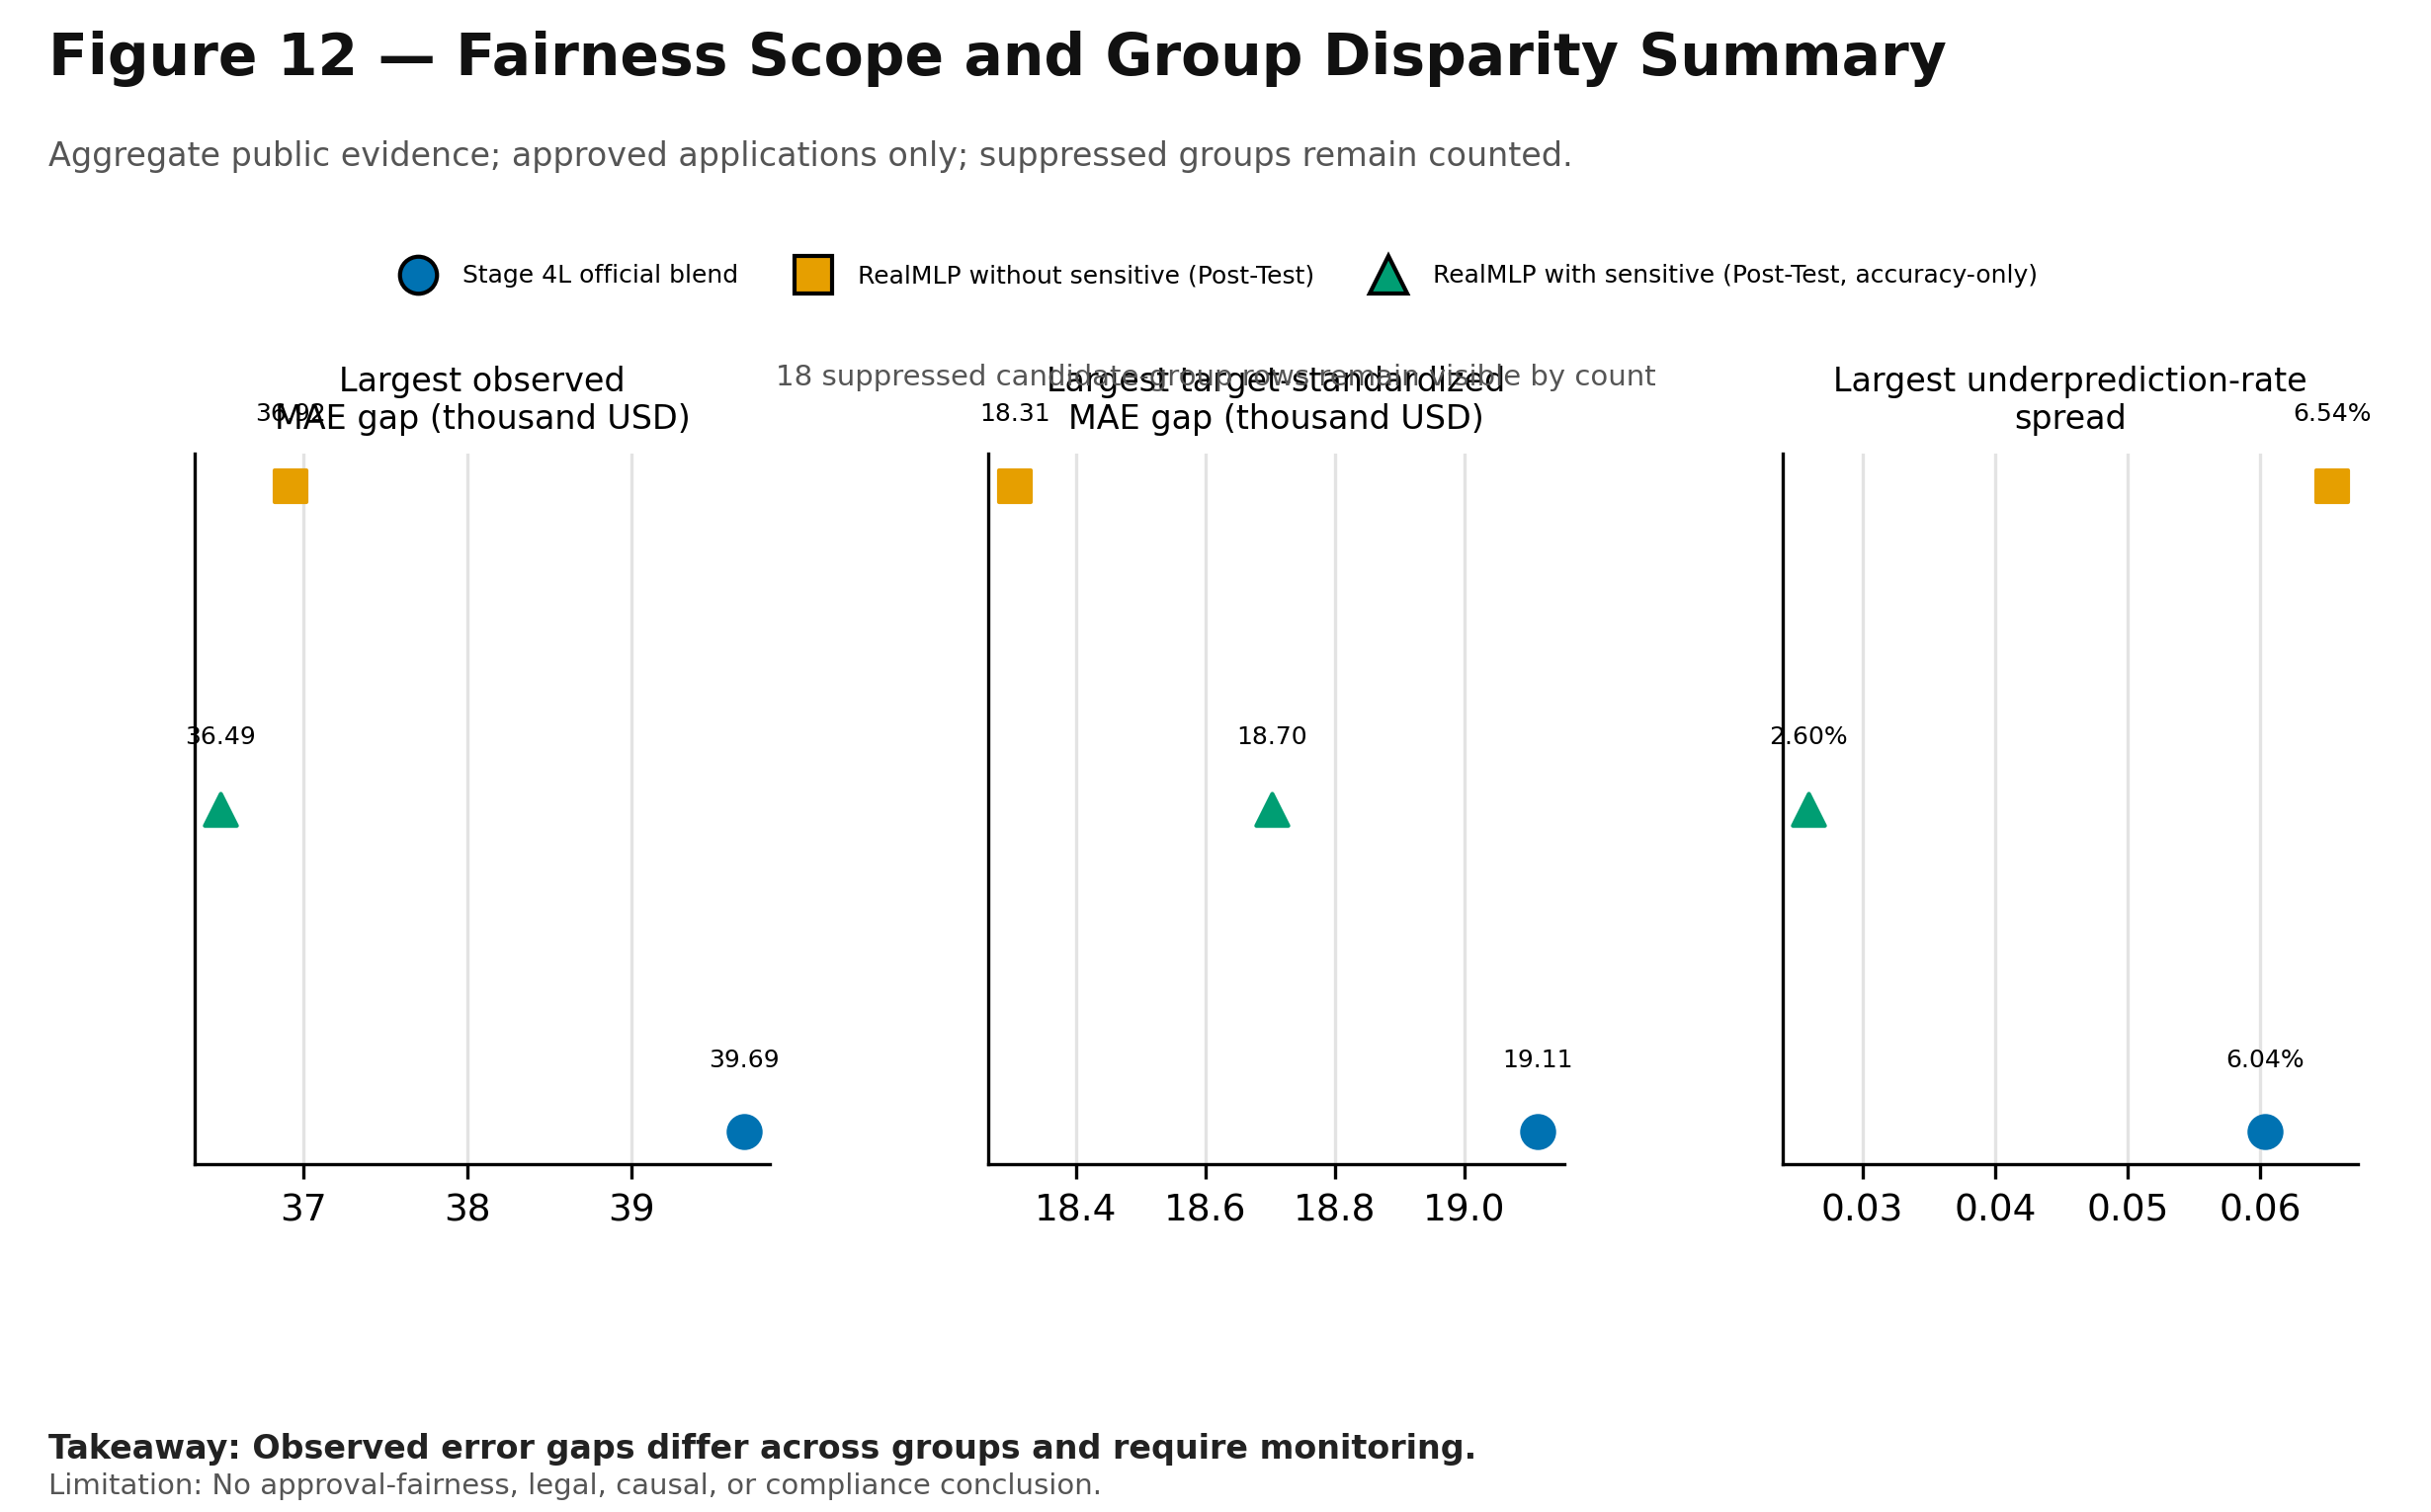

**Figure 12 — Fairness Scope and Group Disparity Summary**  
Figure 12. Fairness Scope and Group Disparity Summary. Aggregate public evidence; approved applications only; suppressed groups remain counted.  
**Takeaway:** Observed error gaps differ across groups and require monitoring.  
**Limitation:** No approval-fairness, legal, causal, or compliance conclusion.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_12.png`

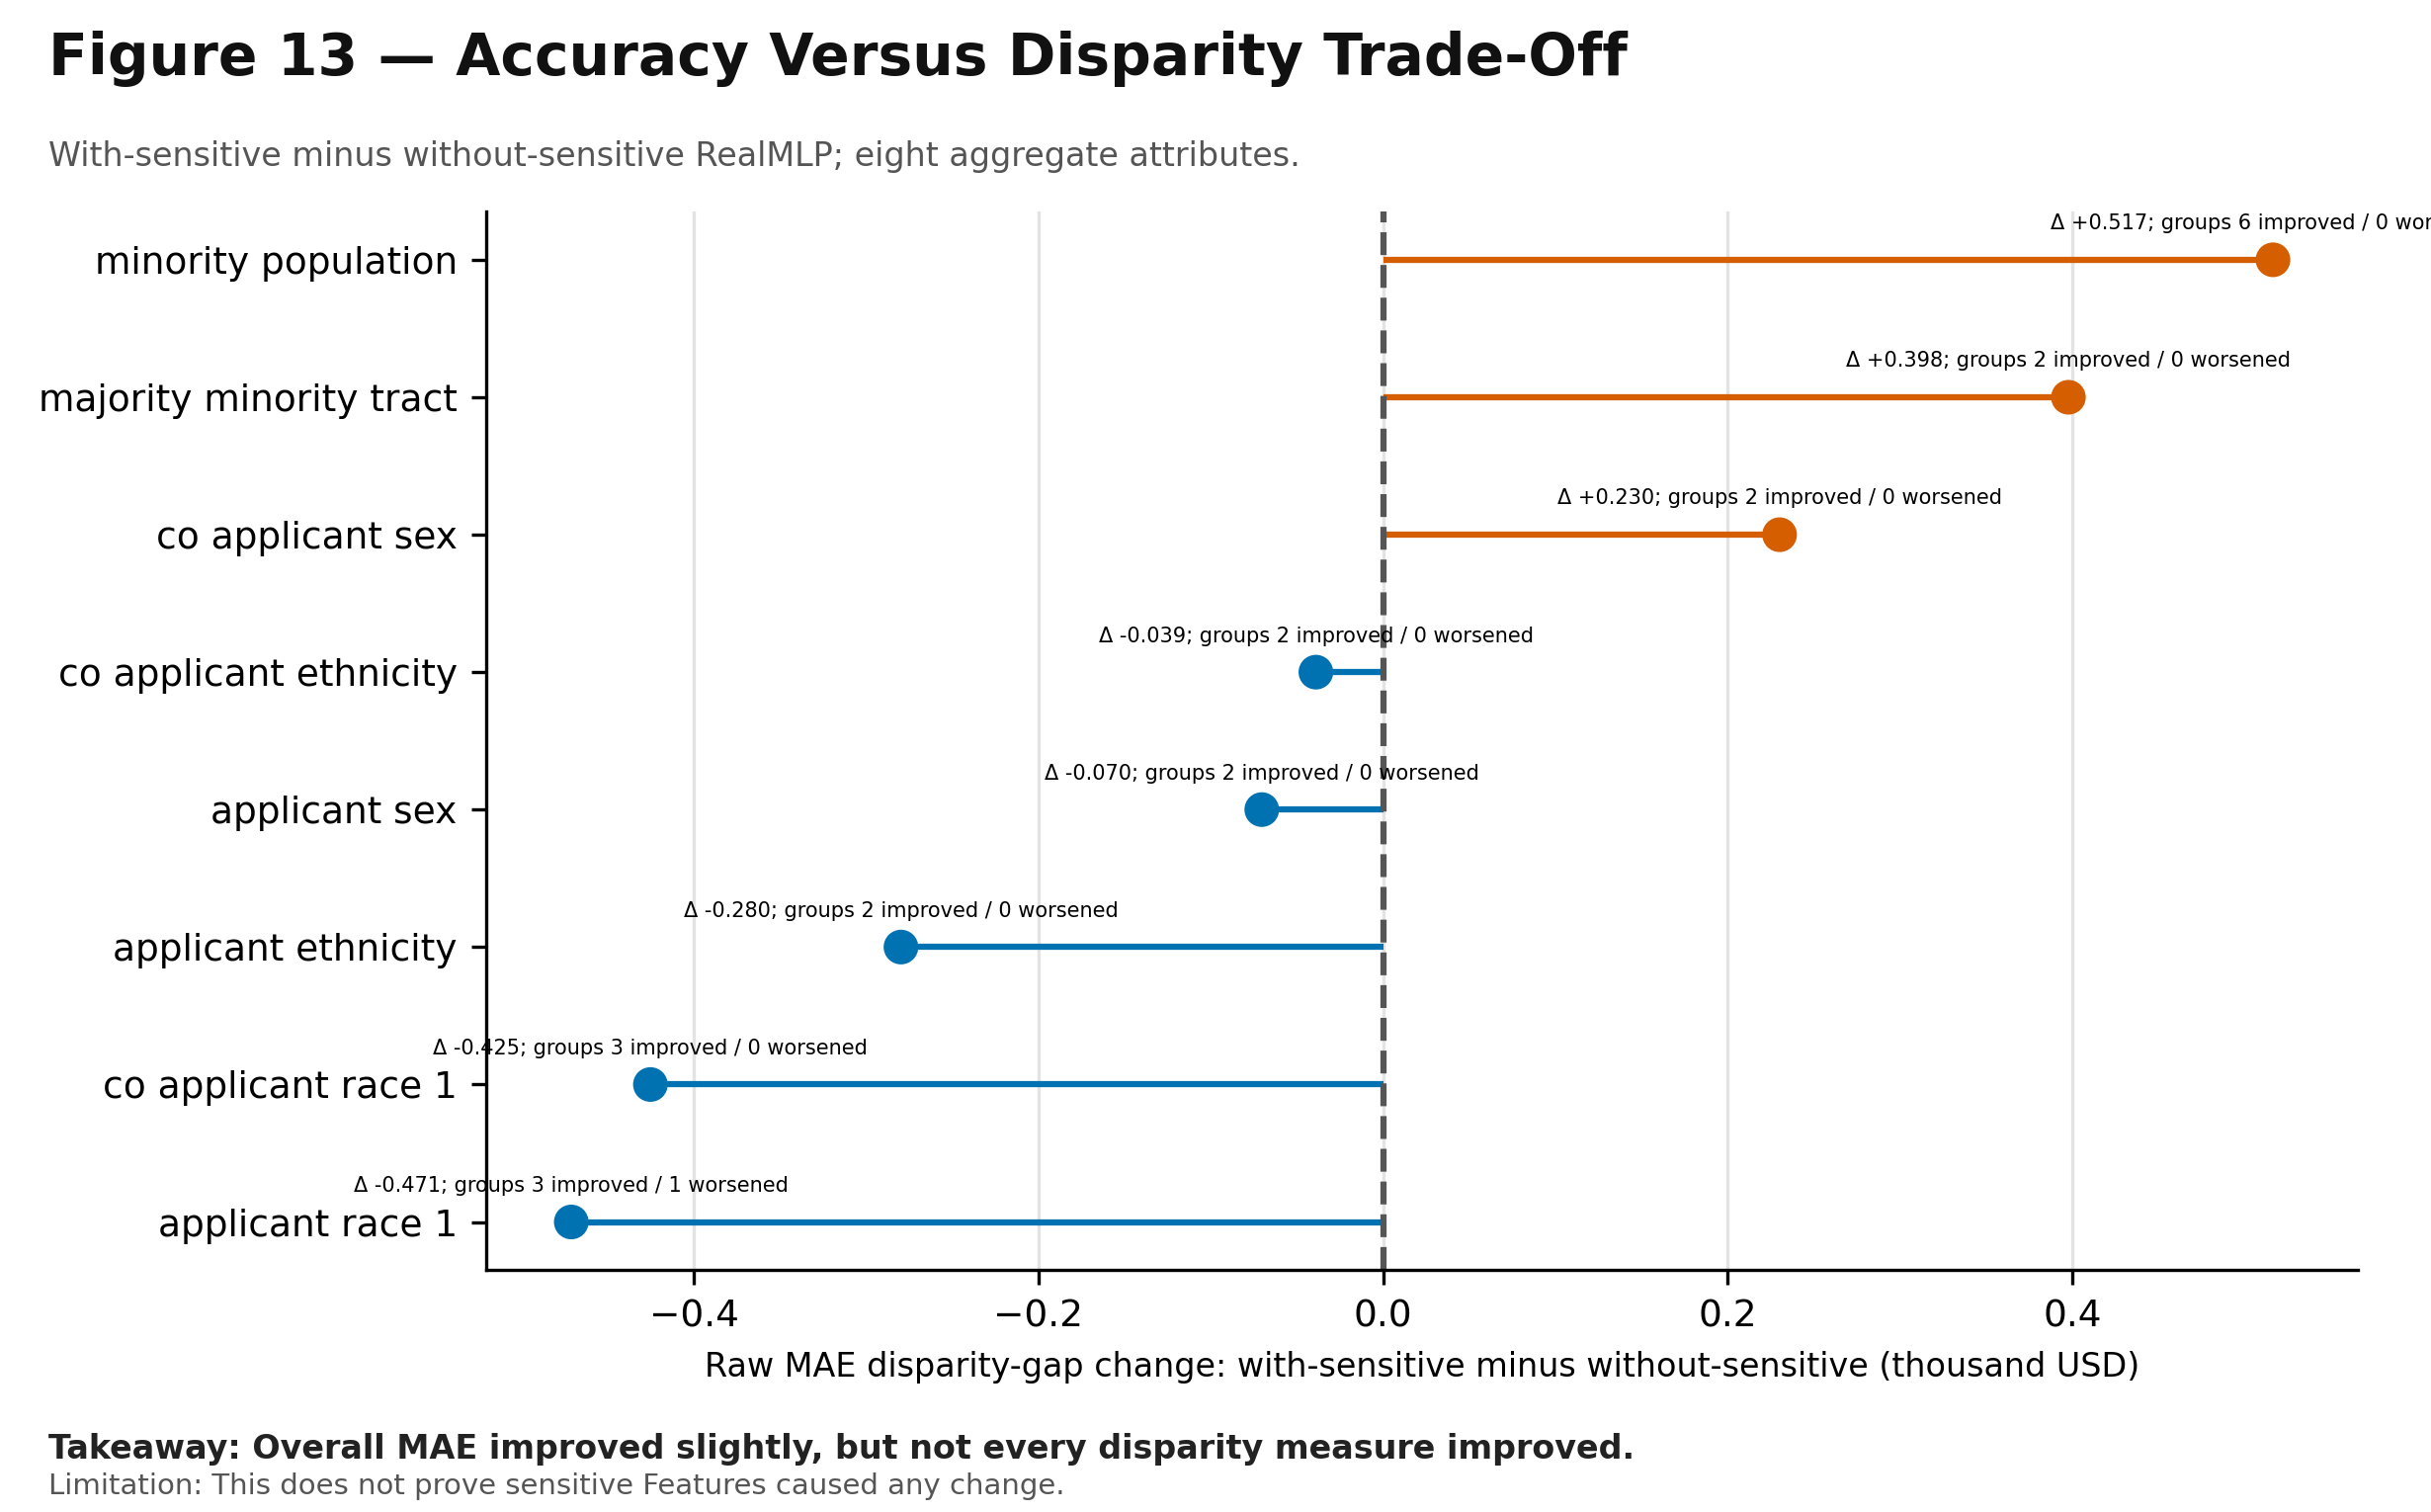

**Figure 13 — Accuracy Versus Disparity Trade-Off**  
Figure 13. Accuracy Versus Disparity Trade-Off. With-sensitive minus without-sensitive RealMLP; eight aggregate attributes.  
**Takeaway:** Overall MAE improved slightly, but not every disparity measure improved.  
**Limitation:** This does not prove sensitive Features caused any change.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_13.png`

In [23]:
fairness_summary_path = "artifacts/results/stage7/fairness/stage7_fairness_summary.json"
fairness = read_json(fairness_summary_path)
fairness_rows = pd.DataFrame([
    {"Summary": "Status", "Value": fairness["status"]},
    {"Summary": "Test rows", "Value": fairness["test_row_count"]},
    {"Summary": "Sensitive fields", "Value": fairness["sensitive_field_count"]},
    {"Summary": "Public row-level sensitive files", "Value": fairness["sensitive_data_handling"]["public_row_level_sensitive_files"]},
    {"Summary": "Maximum saved MAE gap", "Value": fairness["single_attribute_disparity_summary"]["maximum_worst_minus_best_mae_gap"]},
    {"Summary": "Approval fairness assessed", "Value": False},
    {"Summary": "Legal or causal conclusion", "Value": False},
])
display_table_frame(fairness_rows, "Aggregate fairness summary")
disparity_path = "artifacts/results/stage7/fairness/stage7_group_disparity_summary.csv"
disparity = read_table(disparity_path)
disparity_view = disparity.loc[:, [
    "candidate_id", "sensitive_field", "eligible_group_count", "worst_minus_best_mae_gap",
    "worst_to_best_mae_ratio", "maximum_absolute_mean_signed_error", "underprediction_rate_spread",
    "target_standardized_mae_gap", "data_coverage_percentage"
]].copy()
display_table_frame(disparity_view, "Aggregate group-disparity table (no row-level sensitive data)")
trade_path = "artifacts/results/stage7/fairness/stage7_accuracy_disparity_tradeoff.csv"
trade = read_table(trade_path).loc[:, [
    "sensitive_field", "overall_mae_change_with_minus_without", "raw_mae_gap_change",
    "target_standardized_mae_gap_change", "maximum_absolute_signed_bias_change",
    "underprediction_rate_spread_change", "interpretation"
]].copy()
display_table_frame(trade, "Accuracy-versus-disparity trade-off")
render_evidence_note(fairness_summary_path)
render_manifest_figure(12)
render_manifest_figure(13)


## 23. Explainability Scope

Stage 8 reused saved native importance and SHAP evidence, then used bounded grouped permutation and privacy-safe reference substitution during the authorized Recovery. SHAP scales differ by model, permutation describes performance sensitivity, and reference substitution is non-SHAP, non-additive, and sometimes unrealistic. None of these methods proves causality.


In [24]:
explain_path = "artifacts/results/stage8/recovery/stage8_recovery_global_explanation_summary.json"
explain = read_json(explain_path)
methods = pd.DataFrame([
    {"Method or scope": "Saved native importance and SHAP", "Use": "Reused; SHAP compared by rank where scales differ"},
    {"Method or scope": "Grouped permutation", "Use": "Bounded saved-decile Recovery analysis; not a causal effect"},
    {"Method or scope": "Local reference substitution", "Use": "Non-SHAP, non-additive, non-causal, and may be unrealistic"},
    {"Method or scope": "Global rows", "Use": explain["global_rows"]},
    {"Method or scope": "Background rows", "Use": explain["background_rows"]},
    {"Method or scope": "New global SHAP recomputations", "Use": explain["global_shap_recomputations"]},
])
display_table_frame(methods, "Explainability methods and limits")
display(Markdown("**Saved limitations**\n\n- " + "\n- ".join(clean_display_text(item) for item in explain["limitations"])))
render_evidence_note(explain_path)


**Explainability methods and limits**

Method or scope,Use
Saved native importance and SHAP,Reused; SHAP compared by rank where scales differ
Grouped permutation,Bounded saved-decile Recovery analysis; not a causal effect
Local reference substitution,"Non-SHAP, non-additive, non-causal, and may be unrealistic"
Global rows,2000
Background rows,40
New global SHAP recomputations,0


**Saved limitations**

- Stage 8 is Post-Test descriptive explainability.
- Importance is not causality.
- Correlated Features can divide or mask importance.
- Native SHAP output scales differ and are compared by rank only.
- Local reference substitution is non-additive and may create unrealistic combinations.
- Sensitive importance does not prove discrimination or fairness.

*Evidence:* `artifacts/results/stage8/recovery/stage8_recovery_global_explanation_summary.json`  
*SHA-256:* `8f5d0d2caa533ef9a27dfc86ae0a21b2655861e6a50483db8cdec46360a59af4`

## 24. Global Feature Interpretation

Applicant income is the leading saved feature unit across the official blend and both RealMLP modes. Several loan-structure, income-context, and geography units also matter. Importance is not causality, and correlated Features can divide or mask importance. Stage 4L remains official.


**Top Feature-unit comparison (first 12 by saved minimum rank)**

semantic_feature_unit,feature_family,official_blend_rank,realmlp_without_rank,realmlp_with_rank,consensus_top_10_flag,consensus_top_20_flag,potential_proxy_category_flag
applicant_income,Applicant income,1.000,1.000,1.000,True,True,True
lien_status_name,Loan structure and lien status,2.000,2.000,2.000,True,True,True
msamd_name,Geography and region,8.000,3.000,4.000,True,True,True
owner_occupancy_name,Property and occupancy,3.000,4.000,3.000,True,True,True
hud_median_family_income,Tract and area income context,4.000,7.000,7.000,True,True,True
tract_income_ratio,Tract and area income context,5.000,5.000,5.000,True,True,True
loan_purpose_name,Loan purpose and type,6.000,8.000,8.000,True,True,True
us_region,Geography and region,10.000,6.000,6.000,True,True,True
state_name,Geography and region,7.000,19.000,14.000,False,True,True
county_name,Geography and region,9.000,11.000,13.000,False,True,True


**Feature-family summary (first 15 saved rows)**

candidate_id,feature_family,positive_permutation_importance_share,feature_unit_count,top_feature,top_feature_rank,potential_proxy_category_flag
stage4l__blend__without_sensitive,Applicant income,0.374,1,applicant_income,1,True
stage4l__blend__without_sensitive,Engineered ratios and counts,0.008,3,has_co_applicant,17,False
stage4l__blend__without_sensitive,Geography and region,0.142,5,state_name,7,True
stage4l__blend__without_sensitive,"Lender, respondent, and agency",0.017,2,respondent_id,13,True
stage4l__blend__without_sensitive,Loan purpose and type,0.072,2,loan_purpose_name,6,True
stage4l__blend__without_sensitive,Loan structure and lien status,0.160,2,lien_status_name,2,True
stage4l__blend__without_sensitive,Other documented Features,0.001,3,applicant_income_area_group,25,False
stage4l__blend__without_sensitive,Property and occupancy,0.108,5,owner_occupancy_name,3,True
stage4l__blend__without_sensitive,Tract and area income context,0.118,4,hud_median_family_income,4,True
stage5c__realmlp__with_sensitive__test_evaluation,Applicant income,0.383,1,applicant_income,1,True


Full artifact: `artifacts/results/stage8/recovery/stage8_recovery_feature_family_summary.csv` (29 rows). Displayed selection: first 15 rows in saved order.

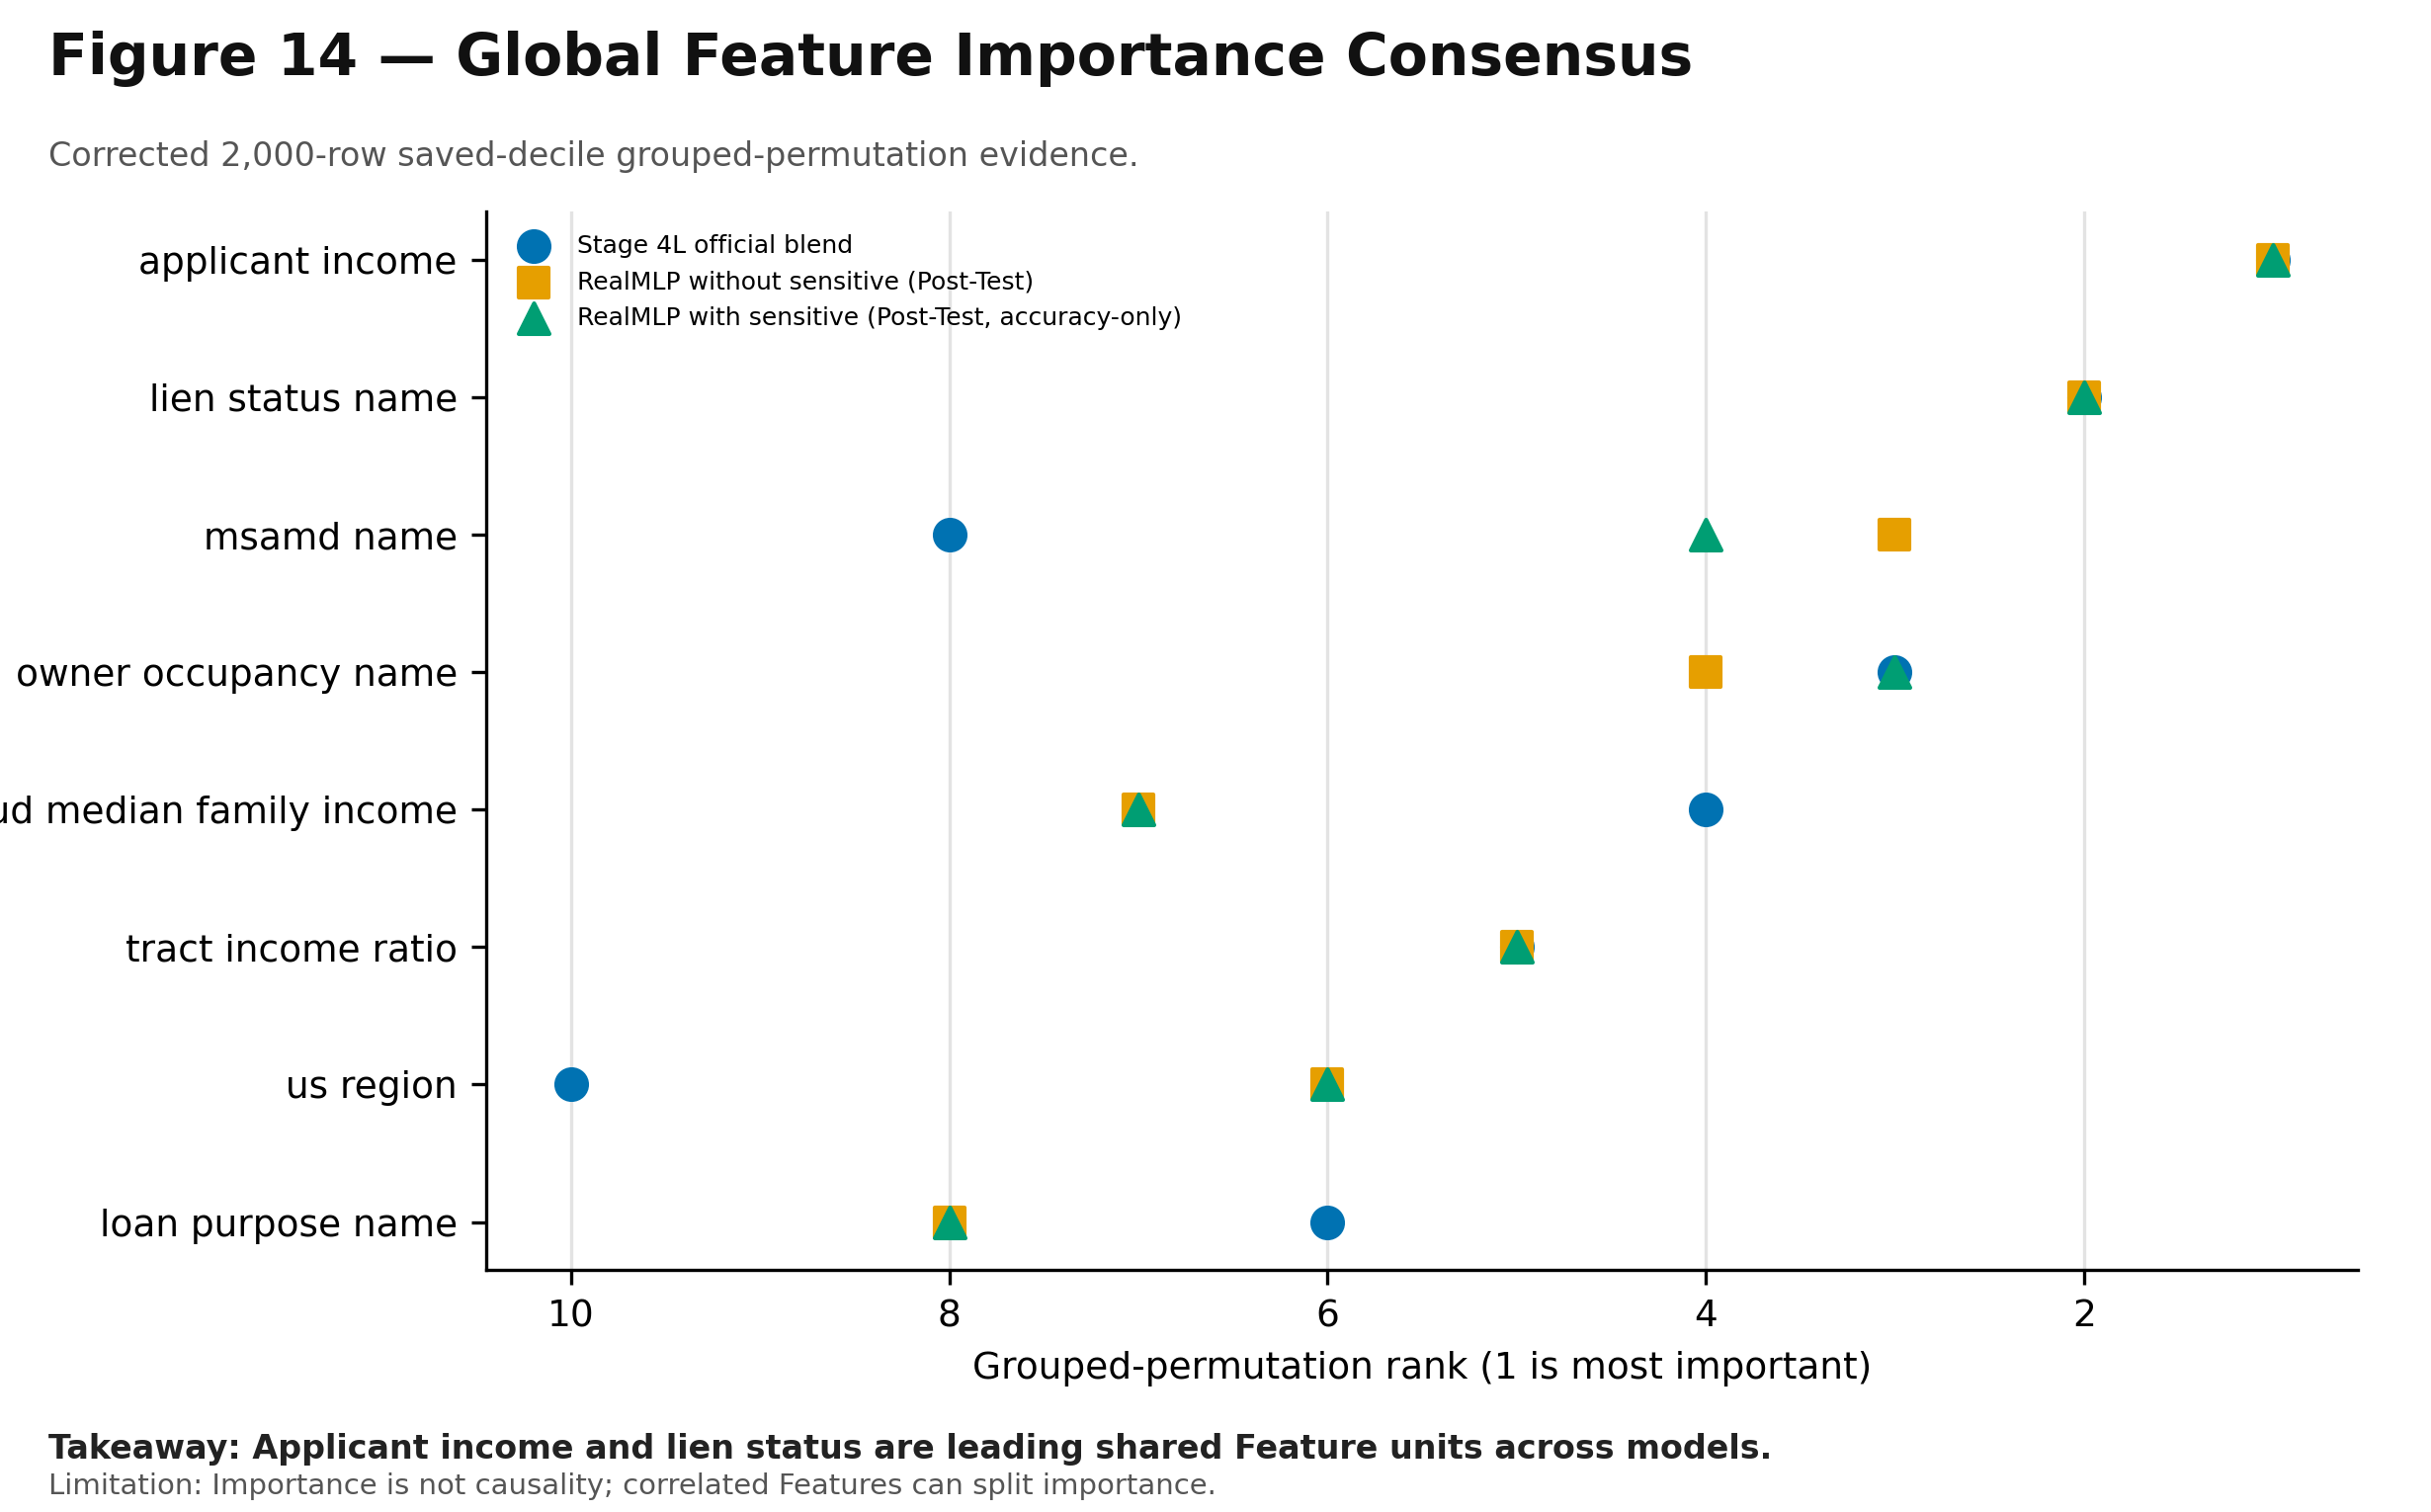

**Figure 14 — Global Feature Importance Consensus**  
Figure 14. Global Feature Importance Consensus. Corrected 2,000-row saved-decile grouped-permutation evidence.  
**Takeaway:** Applicant income and lien status are leading shared Feature units across models.  
**Limitation:** Importance is not causality; correlated Features can split importance.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_14.png`

**Interpretation limit:** importance does not show cause, and correlated Features may share importance. The official model role is unchanged.

In [25]:
comparison_path = "artifacts/results/stage8/recovery/stage8_recovery_cross_model_feature_comparison.csv"
comparison = read_table(comparison_path)
top_units = comparison.sort_values(["minimum_rank_difference", "semantic_feature_unit"]).loc[:, [
    "semantic_feature_unit", "feature_family", "official_blend_rank", "realmlp_without_rank",
    "realmlp_with_rank", "consensus_top_10_flag", "consensus_top_20_flag", "potential_proxy_category_flag"
]].head(12).copy()
display_table_frame(top_units, "Top Feature-unit comparison (first 12 by saved minimum rank)")
render_table(
    "artifacts/results/stage8/recovery/stage8_recovery_feature_family_summary.csv",
    columns=["candidate_id", "feature_family", "positive_permutation_importance_share", "feature_unit_count", "top_feature", "top_feature_rank", "potential_proxy_category_flag"],
    max_rows=15,
    caption="Feature-family summary (first 15 saved rows)",
)
render_manifest_figure(14)
display(Markdown("**Interpretation limit:** importance does not show cause, and correlated Features may share importance. The official model role is unchanged."))


## 25. Local Case Interpretation

Four privacy-safe case types illustrate where models agree or differ. The table uses Case A–D labels only and omits raw row IDs, sensitive values, respondent values, and lender values. Reference substitution describes model behavior; it is not SHAP, additive, causal, or a realistic policy intervention.


**Privacy-safe selected cases (rank 1 from each declared case type)**

Case,case_type,case_rank,top5_consensus_feature_units,non_causal_warning
Case A,common_large_error,1,applicant_income|msamd_name|tract_income_ratio,"Reference substitution is not SHAP, additive, causal, or a realistic intervention."
Case B,deep_with_improves_over_without,1,applicant_income|county_name,"Reference substitution is not SHAP, additive, causal, or a realistic intervention."
Case C,deep_without_beats_stage4l,1,applicant_income|county_name|tract_income_ratio,"Reference substitution is not SHAP, additive, causal, or a realistic intervention."
Case D,stage4l_beats_deep_without,1,applicant_income|owner_occupancy_name|tract_income_ratio,"Reference substitution is not SHAP, additive, causal, or a realistic intervention."


**Local stability summary**

Stability item,Value
Saved stability rows,12.000
Low-stability flags,0.000
Median Spearman rank correlation,0.938
Minimum top-5 overlap,4.000


Full case artifact: `artifacts/results/stage8/recovery/stage8_recovery_case_explanation_synthesis.csv` (20 rows). Raw row identifiers are intentionally not displayed.

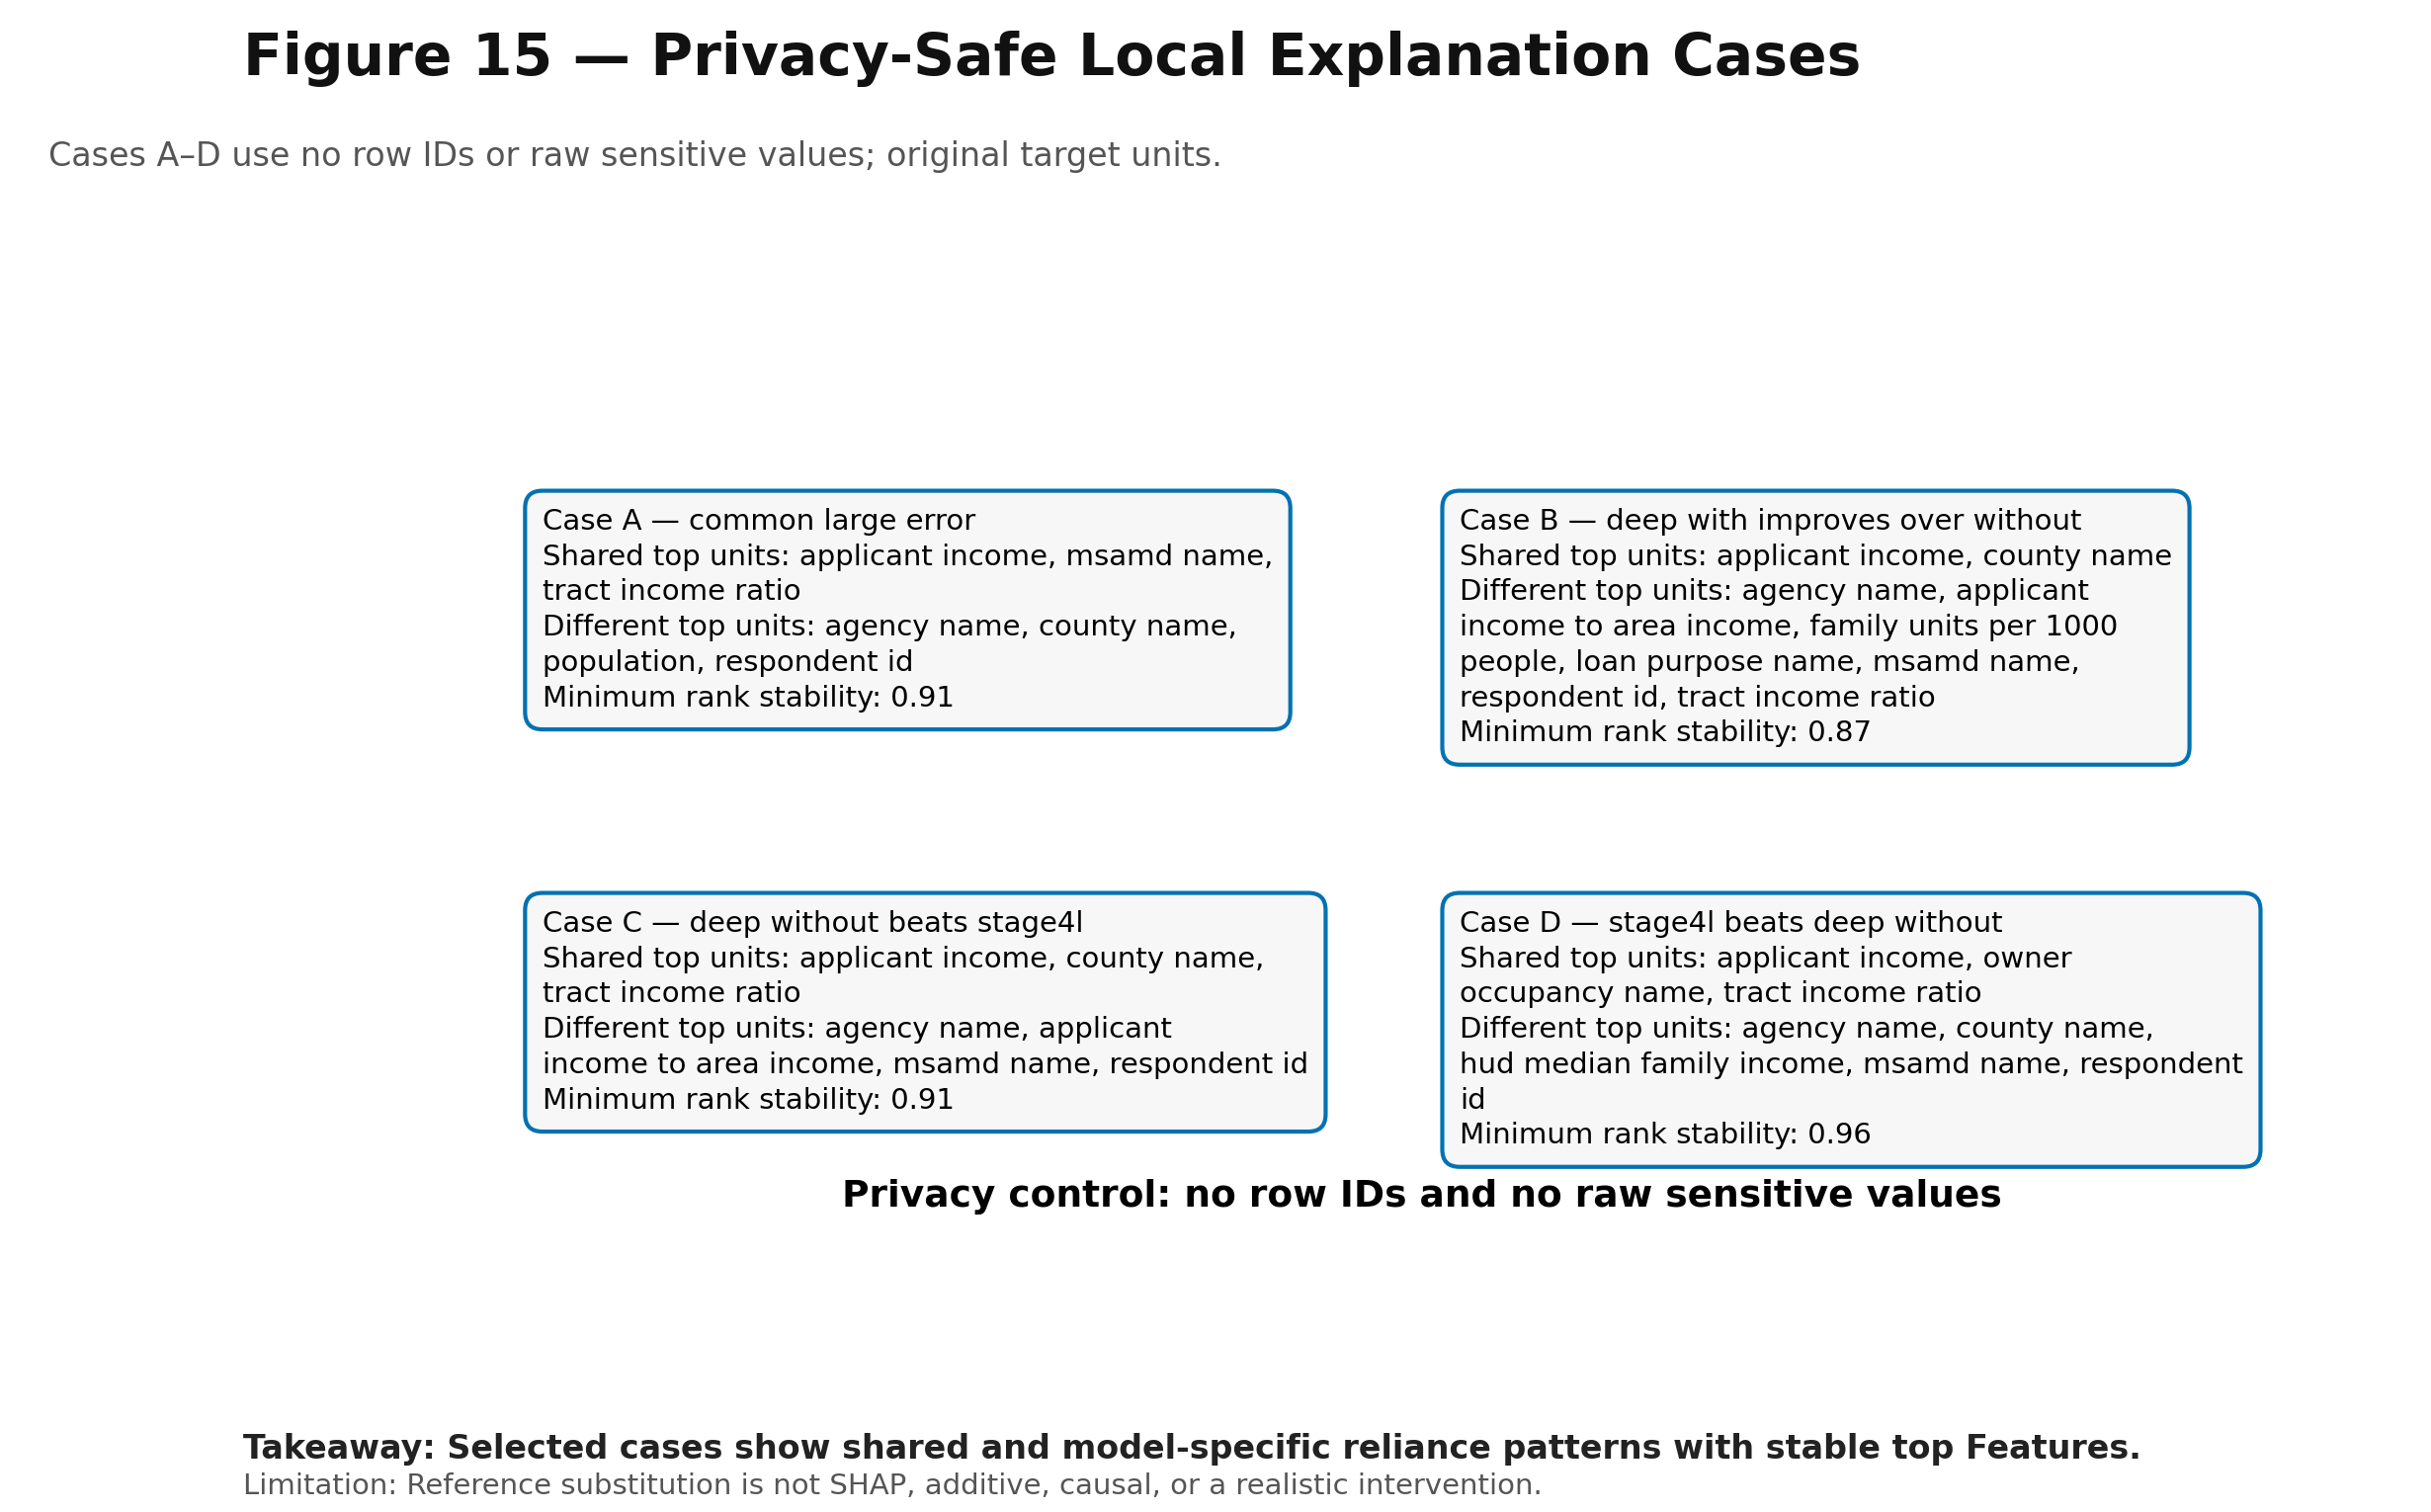

**Figure 15 — Privacy-Safe Local Explanation Cases**  
Figure 15. Privacy-Safe Local Explanation Cases. Cases A–D use no row IDs or raw sensitive values; original target units.  
**Takeaway:** Selected cases show shared and model-specific reliance patterns with stable top Features.  
**Limitation:** Reference substitution is not SHAP, additive, causal, or a realistic intervention.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_15.png`

In [26]:
cases_path = "artifacts/results/stage8/recovery/stage8_recovery_case_explanation_synthesis.csv"
cases = read_table(cases_path)
case_order = [
    "common_large_error", "deep_with_improves_over_without",
    "deep_without_beats_stage4l", "stage4l_beats_deep_without"
]
selected_cases = cases.loc[cases["case_rank"].eq(1) & cases["case_type"].isin(case_order), [
    "case_type", "case_rank", "top5_consensus_feature_units", "non_causal_warning"
]].copy()
selected_cases["Case"] = selected_cases["case_type"].map(dict(zip(case_order, ["Case A", "Case B", "Case C", "Case D"])))
selected_cases = selected_cases.loc[:, ["Case", "case_type", "case_rank", "top5_consensus_feature_units", "non_causal_warning"]]
display_table_frame(selected_cases, "Privacy-safe selected cases (rank 1 from each declared case type)")
stability_path = "artifacts/results/stage8/recovery/stage8_recovery_local_explanation_stability.csv"
stability = read_table(stability_path)
stability_summary = pd.DataFrame([
    {"Stability item": "Saved stability rows", "Value": len(stability)},
    {"Stability item": "Low-stability flags", "Value": int(stability["low_stability_flag"].sum())},
    {"Stability item": "Median Spearman rank correlation", "Value": stability["spearman_rank_correlation"].median()},
    {"Stability item": "Minimum top-5 overlap", "Value": stability["top_5_overlap"].min()},
])
display_table_frame(stability_summary, "Local stability summary")
display(Markdown(f"Full case artifact: `{cases_path}` ({len(cases):,} rows). Raw row identifiers are intentionally not displayed."))
render_manifest_figure(15)


## 26. Governance Incidents

Four events must remain visible: the Stage 4L Test opening, the Stage 5A procedural Test-row materialization exception, the invalid initial Stage 8 explanation attempt followed by Recovery, and Registry Governance Path B. These disclosures do not change the official model or erase the incidents.


In [27]:
render_table(
    "artifacts/results/stage9/reporting/stage9_governance_timeline.csv",
    columns=["Stage", "Governance event", "Classification", "Scientific effect", "Resolution", "Remaining disclosure", "Downstream rule"],
    caption="Complete governance timeline",
)
render_markdown("artifacts/results/stage9/reporting/stage9_governance_summary.md")


**Complete governance timeline**

Stage,Governance event,Classification,Scientific effect,Resolution,Remaining disclosure,Downstream rule
Stage 4L,Test freeze before evaluation,preventive control,Protected unbiased official comparison,PASS,Freeze identity and hash remain authoritative,No later Test observation may replace the official result
Stage 4L,Test consumed,evaluation event,Official Test metrics became available,PASS,Test remains consumed,A new holdout is required for another unbiased final comparison
Stage 5A,Procedural Test-row materialization,governance exception,"No Test row entered selection, preprocessing fit, or model fit; literal no-loading rule failed",Accepted after adjudication,Always disclose the exception,Future loaders must filter excluded rows at the parser boundary
Stage 5A,Governance adjudication,documented resolution,Models accepted without refit; no statistical Test leakage demonstrated,PASS_WITH_DOCUMENTED_GOVERNANCE_EXCEPTION,Literal failure remains visible,Do not weaken future zero-Test-loading rules
Stage 5B,Ensemble rejection,pre-registered decision,No ensemble Test prediction was allowed,PASS,50/50 design remains rejected,Do not show it as a final Test Candidate
Stage 5C,Post-Test deep evaluation,Post-Test extension,Two descriptive RealMLP Test results,PASS,Cannot promote a new winner,New independent holdout required
Stage 7,Approved-only fairness scope,scope limitation,Only descriptive error disparities among approved applications,PASS,No approval-fairness or legal conclusion,Monitor groups and collect broader outcome data
Stage 8,Invalid sample and background incident,scientific invalidation,53 affected initial artifacts excluded,Recovered,Initial artifacts remain audit-only,Use only Recovery evidence
Stage 8 Recovery,Saved-decile recovery,scientific correction,"Correct 2,000-row sample, 40-row background, and complete local dispersion",PASS,Post-Test and non-causal,No explainability rerun in Stage 9
Stage 8 Recovery,Registry Governance Path B,governance exception,Historical exact bytes unavailable; semantics validated,PASS_WITH_DOCUMENTED_REGISTRY_GOVERNANCE_EXCEPTION,Recovery-start 386 rows are the exact prefix of final 394 rows,Preserve Path B disclosure in every handoff


Full artifact: `artifacts/results/stage9/reporting/stage9_governance_timeline.csv` (10 rows).

# Governance Summary

The official Stage 4L blend was frozen before the Test Set was opened. Test was consumed at Stage 4L, so Stages 5C–9 are Post-Test and cannot create a new unbiased winner.

Stage 5A transiently materialized Test rows before Train-only filtering. No Test row entered model selection, preprocessing fit, or model fit, and statistical leakage was not demonstrated. The procedural exception remains visible and does not weaken future parser-boundary rules.

Stage 5B rejected its frozen 50/50 ensemble because the RMSE worsening gate failed. It received no Test prediction.

Stage 7 is approved-applications-only descriptive fairness analysis. It does not assess approval fairness, causality, legal compliance, or access to credit.

The initial Stage 8 sample incident invalidated 53 affected artifacts. Recovery used saved Stage 5C target deciles. Registry Governance Path B was accepted because historical exact bytes were unavailable; semantic rows validated, and the Recovery-start 386-row byte sequence is the exact prefix of the final 394-row Stage 8 Registry. Both the initial artifacts and final Recovery artifacts remain audit evidence.


*Evidence:* `artifacts/results/stage9/reporting/stage9_governance_summary.md`  
*SHA-256:* `4501b84468118222088b16b5528a6ab3d8b376d49de2e0a83e9ebec71dca91e1`

## 27. Responsible-Use Recommendation

Keep Stage 4L as the official model and treat the RealMLP results as Post-Test challengers. Use the model only for research or human-supported decision work with monitoring and high-value review. Do not use it for automated approval, rejection, legal fairness certification, or unmonitored production. A new independent holdout is needed before another unbiased evaluation.


# Final Recommendation

## Official Model

Keep the Stage 4L frozen non-sensitive Boosting blend as the official pre-registered primary.

## Why It Remains Official

It was frozen before Test, it is the official pre-registered comparison, and no later Test observation can replace it. RealMLP without and with sensitive Features remain Post-Test challengers; the sensitive result is accuracy-only.

## Strengths and Weaknesses

The official model has the lowest observed Test MAE among the three final candidates and broad leading-Feature agreement with RealMLP. Its main weaknesses are large-loan underprediction, concentrated tail error, observed group disparities, potential proxy categories, and no prospective validation.

## Responsible Use

Use only for decision support with human review, high-value-case review, and monitoring. Do not use for automated approval or rejection, legal fairness certification, or unmonitored production.

## Research Recommendation

Obtain a new independent holdout and prospective evaluation. Monitor drift, tails, underprediction, and groups. Any retraining belongs to a future authorized Stage.


*Evidence:* `artifacts/results/stage9/reporting/stage9_final_recommendation.md`  
*SHA-256:* `56d4dab30a9cb5d1c658a61e28be40417809c3d5ab36e360c1e1dbcc6ec70713`

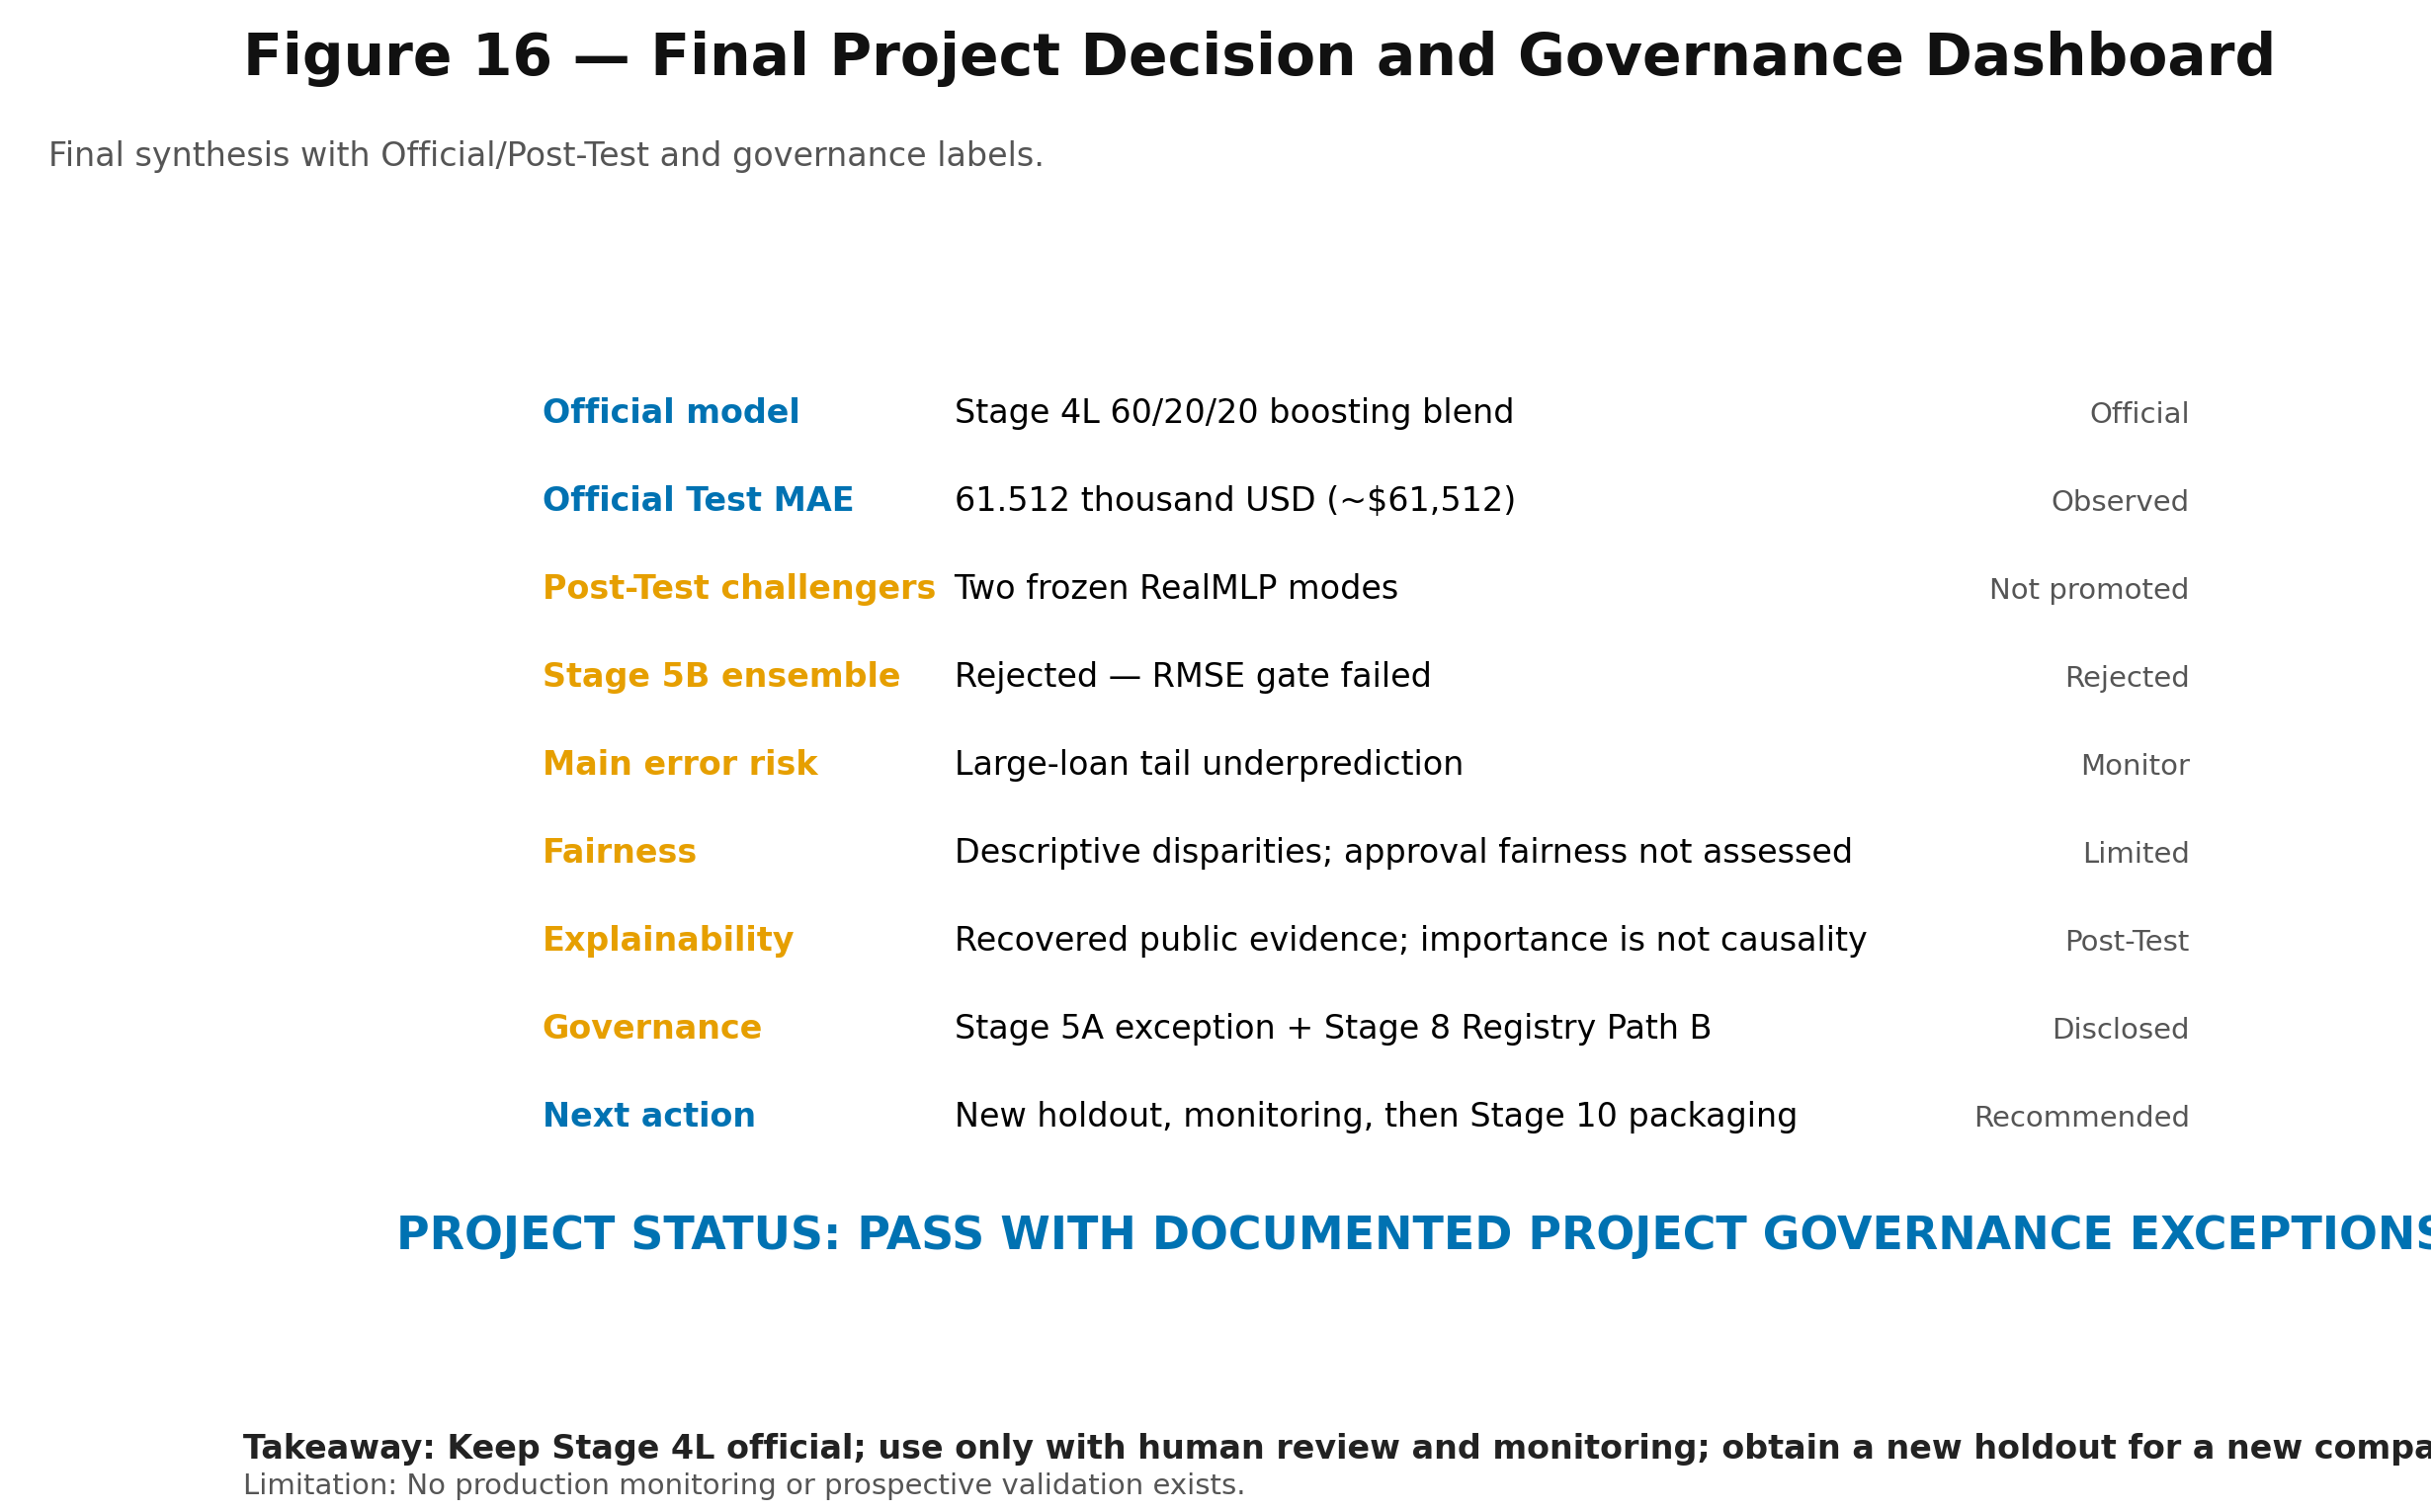

**Figure 16 — Final Project Decision and Governance Dashboard**  
Figure 16. Final Project Decision and Governance Dashboard. Final synthesis with Official/Post-Test and governance labels.  
**Takeaway:** Keep Stage 4L official; use only with human review and monitoring; obtain a new holdout for a new comparison.  
**Limitation:** No production monitoring or prospective validation exists.  
**Evidence path:** `artifacts/figures/stage9/report/stage9_figure_16.png`

In [28]:
render_markdown("artifacts/results/stage9/reporting/stage9_final_recommendation.md")
render_manifest_figure(16)


## 28. Non-Technical FAQ

The complete FAQ answers common questions about MAE, R², the official model, the rejected ensemble, sensitive Features, fairness scope, explainability, responsible use, large-loan errors, production readiness, and the need for a new holdout.


In [29]:
render_markdown("artifacts/results/stage9/reporting/stage9_nontechnical_faq.md")


# Non-Technical FAQ

## 1. Is MAE an accuracy percentage?

No. MAE is an average error in the target unit. Here 61.51 means about $61,510, not 61% accuracy.

## 2. Does R² of about 0.71 mean 71 percent accuracy?

No. R² describes captured variation. It is not the chance that a prediction is correct.

## 3. Which model is official?

The Stage 4L non-sensitive 60/20/20 CatBoost, LightGBM, and XGBoost blend.

## 4. Why is the model with the lowest observed number not automatically official?

Official status depends on a comparison frozen before Test. Later Test observations are Post-Test and cannot create a new unbiased winner.

## 5. Why was the ensemble rejected?

Its MAE and Bootstrap gates passed, but its RMSE worsening exceeded the frozen 0.25% maximum.

## 6. Did sensitive Features make the model fair?

No. A small accuracy change does not prove fairness or causality.

## 7. Did Stage 7 analyze loan approval fairness?

No. It analyzed errors only among approved applications with observed outcomes.

## 8. Do important Features cause loan amounts?

No. Importance describes model reliance, not real-world causality.

## 9. Can the model be used to approve or reject a loan?

No. That use is outside the model's purpose and evidence.

## 10. Why are large loans harder to predict?

Saved results show larger errors in the high target tail, but this project did not identify a cause.

## 11. What must happen before production use?

Prospective validation, operational and legal review, monitoring, drift controls, and human-review rules are needed.

## 12. Why is a new independent holdout needed?

The current Test Set was already consumed, so it cannot provide another unbiased model-selection comparison.


*Evidence:* `artifacts/results/stage9/reporting/stage9_nontechnical_faq.md`  
*SHA-256:* `e43cbd9c920542a46a03222fa53c08b3a02f773b27c84ca7a659f61e0f37e9e1`

## 29. Final Story Figures

The 16 frozen report figures have already appeared once in their evidence sections. This visual index points to report, slide, and SVG versions without displaying any full-size figure again.


In [30]:
section_map = {
    1: 12, 2: 9, 3: 13, 4: 13, 5: 15, 6: 16, 7: 16, 8: 17,
    9: 19, 10: 20, 11: 18, 12: 22, 13: 22, 14: 24, 15: 25, 16: 27,
}
audit = read_table("artifacts/results/stage9/reporting/stage9_chart_audit.csv").set_index("figure_id")
index_rows = []
for number, entry in sorted(FIGURES.items()):
    index_rows.append({
        "Figure": number,
        "Title": entry["title"],
        "Notebook section": section_map[number],
        "Report PNG": entry["report_path"],
        "Slide PNG": entry["slide_path"],
        "SVG": entry["vector_path"],
        "Takeaway": entry["takeaway"],
        "Limitation": entry["limitation"],
        "Chart Audit": audit.loc[entry["figure_id"], "status"],
    })
display_table_frame(pd.DataFrame(index_rows), "Visual index — 16 frozen figures")
display(Markdown("**Display confirmation:** Figures 1–16 were each displayed once in Sections 9–27; this section is an index only."))
render_evidence_note(FIGURE_MANIFEST_PATH)


**Visual index — 16 frozen figures**

Figure,Title,Notebook section,Report PNG,Slide PNG,SVG,Takeaway,Limitation,Chart Audit
1,Project Workflow,12,artifacts/figures/stage9/report/stage9_figure_01.png,artifacts/figures/stage9/slides/stage9_figure_01.png,artifacts/figures/stage9/vector/stage9_figure_01.svg,"The project moved from validation to modeling, locked evaluation, and responsible reporting.",Process order does not rank model quality.,PASS
2,Dataset Scope and Split,9,artifacts/figures/stage9/report/stage9_figure_02.png,artifacts/figures/stage9/slides/stage9_figure_02.png,artifacts/figures/stage9/vector/stage9_figure_02.svg,"The frozen split has 399,788 Train rows and 99,948 Test rows with no overlap.",A random row split may share lenders or geography across sets.,PASS
3,Modeling Journey and Decision Timeline,13,artifacts/figures/stage9/report/stage9_figure_03.png,artifacts/figures/stage9/slides/stage9_figure_03.png,artifacts/figures/stage9/vector/stage9_figure_03.svg,Several model families were tested before the official Stage 4L evaluation.,"The timeline is a decision history, not a performance ranking.",PASS
4,Comparable Final Selection Validation Performance,13,artifacts/figures/stage9/report/stage9_figure_04.png,artifacts/figures/stage9/slides/stage9_figure_04.png,artifacts/figures/stage9/vector/stage9_figure_04.svg,The frozen boosting blend had the lowest MAE in this shared validation comparison.,This is Train-only validation context and cannot be mixed with Test metrics.,PASS
5,Final Test MAE Comparison,15,artifacts/figures/stage9/report/stage9_figure_05.png,artifacts/figures/stage9/slides/stage9_figure_05.png,artifacts/figures/stage9/vector/stage9_figure_05.svg,"The official blend has the lowest observed Test MAE: about $61,500.",RealMLP results are Post-Test and cannot replace the official result.,PASS
6,Final Multi-Metric Comparison,16,artifacts/figures/stage9/report/stage9_figure_06.png,artifacts/figures/stage9/slides/stage9_figure_06.png,artifacts/figures/stage9/vector/stage9_figure_06.svg,Observed strengths differ by metric: Stage 4L leads MAE while RealMLP leads some RMSE and tail measures.,Post-Test comparisons are descriptive and metrics are not combined into one score.,PASS
7,Paired Uncertainty,16,artifacts/figures/stage9/report/stage9_figure_07.png,artifacts/figures/stage9/slides/stage9_figure_07.png,artifacts/figures/stage9/vector/stage9_figure_07.svg,The official blend has lower MAE than RealMLP without sensitive; with-sensitive RealMLP is lower than without-sensitive.,Intervals are descriptive after Test consumption and did not select a model.,PASS
8,Why the Ensemble Was Rejected,17,artifacts/figures/stage9/report/stage9_figure_08.png,artifacts/figures/stage9/slides/stage9_figure_08.png,artifacts/figures/stage9/vector/stage9_figure_08.svg,"The ensemble passed MAE and Bootstrap gates but failed the RMSE worsening limit, so it was rejected.",Validation-only decision; the ensemble received no Test prediction.,PASS
9,Error by Target Decile,19,artifacts/figures/stage9/report/stage9_figure_09.png,artifacts/figures/stage9/slides/stage9_figure_09.png,artifacts/figures/stage9/vector/stage9_figure_09.svg,Error rises sharply in the highest loan-amount decile for every candidate.,Deciles describe saved Test outcomes and do not identify causes.,PASS
10,Tail and Underprediction Risk,20,artifacts/figures/stage9/report/stage9_figure_10.png,artifacts/figures/stage9/slides/stage9_figure_10.png,artifacts/figures/stage9/vector/stage9_figure_10.svg,Large loans are harder and are often underpredicted.,This pattern is descriptive and not causal.,PASS


**Display confirmation:** Figures 1–16 were each displayed once in Sections 9–27; this section is an index only.

*Evidence:* `artifacts/manifests/stage9/stage9_final_visualization_manifest.json`  
*SHA-256:* `464255c3cc3cef319efaaf0c6a1e446215b131f7431da24515307d1182e16d44`

## 30. Visual and Axis Integrity Audit

All 16 figures passed the final chart audit. Focused axes are used for close values, filled bars start at zero, units and Official/Post-Test labels are visible, and no privacy issue was found.


In [31]:
audit_path = "artifacts/results/stage9/reporting/stage9_chart_audit.csv"
audit = read_table(audit_path)
summary = pd.DataFrame([
    {"Audit item": "Figures", "Value": len(audit)},
    {"Audit item": "FAIL count", "Value": int(audit["status"].ne("PASS").sum())},
    {"Audit item": "Focused-axis figures", "Value": 2},
    {"Audit item": "Zero-based bar-axis figures", "Value": 1},
    {"Audit item": "Zero-based bar-axis policy", "Value": "PASS"},
    {"Audit item": "Official/Post-Test labels", "Value": "PASS" if audit["official_post_test_role_visible"].all() else "FAIL"},
    {"Audit item": "Unit labels", "Value": "PASS" if audit["correct_unit"].all() else "FAIL"},
    {"Audit item": "Privacy", "Value": "PASS" if audit["no_privacy_issue"].all() else "FAIL"},
])
display_table_frame(summary, "Chart Audit summary")
compact = audit.loc[:, [
    "figure_id", "correct_source_hash", "correct_metric_direction", "correct_unit",
    "axis_does_not_hide_differences", "axis_does_not_exaggerate_differences",
    "official_post_test_role_visible", "no_privacy_issue", "status"
]].copy()
display_table_frame(compact, "Compact final Chart Audit")
render_evidence_note(audit_path)


**Chart Audit summary**

Audit item,Value
Figures,16
FAIL count,0
Focused-axis figures,2
Zero-based bar-axis figures,1
Zero-based bar-axis policy,PASS
Official/Post-Test labels,PASS
Unit labels,PASS
Privacy,PASS


**Compact final Chart Audit**

figure_id,correct_source_hash,correct_metric_direction,correct_unit,axis_does_not_hide_differences,axis_does_not_exaggerate_differences,official_post_test_role_visible,no_privacy_issue,status
stage9_figure_01,True,True,True,True,True,True,True,PASS
stage9_figure_02,True,True,True,True,True,True,True,PASS
stage9_figure_03,True,True,True,True,True,True,True,PASS
stage9_figure_04,True,True,True,True,True,True,True,PASS
stage9_figure_05,True,True,True,True,True,True,True,PASS
stage9_figure_06,True,True,True,True,True,True,True,PASS
stage9_figure_07,True,True,True,True,True,True,True,PASS
stage9_figure_08,True,True,True,True,True,True,True,PASS
stage9_figure_09,True,True,True,True,True,True,True,PASS
stage9_figure_10,True,True,True,True,True,True,True,PASS


*Evidence:* `artifacts/results/stage9/reporting/stage9_chart_audit.csv`  
*SHA-256:* `3f1d62747fe0f56418df2eea9472a59b293a35df2227d79d407caac4688e41c7`

## 31. Executive Summary and One-Page Brief

The complete Executive Summary gives the full plain-language result and limitations. The One-Page Brief provides a shorter decision-focused view for presentation and review.


In [32]:
display(Markdown("# Executive Summary — complete saved report"))
render_markdown("artifacts/results/stage9/reporting/stage9_executive_summary.md")
display(Markdown("# One-Page Project Brief — complete saved report"))
render_markdown("artifacts/results/stage9/reporting/stage9_one_page_project_brief.md")


# Executive Summary — complete saved report

# Executive Summary

## 1. The question

This project asks whether a model can estimate the reported loan amount for an approved loan application. The target is `loan_amount_000s`, a continuous amount measured in thousands of US dollars. A model output of 250 means about $250,000. The project does not predict approval, rejection, default, interest rate, creditworthiness, or whether a person should receive a loan.

## 2. The data

The processed dataset contains 499,736 approved applications with observed loan amounts. A frozen split assigned 399,788 rows to Train and 99,948 rows to Test, with no overlap. The Test Set was kept locked during development and was opened in Stage 4L. Because the data contain approved applications only, the project cannot describe denied applicants or fairness in the approval process.

## 3. How the project was evaluated

The main metric is mean absolute error (MAE). MAE is the average size of the model's mistake, ignoring whether the model predicted too high or too low. Root mean squared error (RMSE) gives more weight to large mistakes. R² describes how much of the variation in loan amounts is captured by the model; it is not an accuracy percentage. Several model families were developed with Train-only evidence before the locked Test evaluation.

## 4. The official result

The official model is the frozen Stage 4L non-sensitive boosting blend. It combines CatBoost at 60%, LightGBM at 20%, and XGBoost at 20%. It was frozen before Test results were seen, so it remains the official pre-registered primary. On 99,948 Test rows, its MAE is 61.511631 thousand US dollars, or about $61,512 average absolute error. Its RMSE is 125.788460 thousand dollars and its R² is 0.712206.

## 5. Post-Test deep comparison

Two frozen RealMLP models were later evaluated on the same Test rows. The without-sensitive model has MAE 62.159745, and the with-sensitive model has MAE 61.821114, in thousands of dollars. These are Post-Test Extensions. They help describe model behavior, but they cannot create a new unbiased winner because the Test Set had already been consumed. The with-sensitive comparison is accuracy-only; it is not proof of fairness or causality. A new independent holdout is required for a new unbiased comparison.

## 6. Why the ensemble was rejected

Stage 5B tested a frozen 50/50 blend of RealMLP and the boosting blend on Train-only Final Selection Validation data. It passed the MAE-improvement and paired-Bootstrap gates, but RMSE worsened by 0.346%, above the frozen 0.25% maximum. The ensemble was therefore rejected and received no Test prediction.

## 7. Main error limitation

Errors are much larger for high loan amounts. The official model's top-decile MAE is 195.498 thousand dollars and its top-five-percent MAE is 287.064 thousand dollars. In the top five percent, it underpredicts about 83% of rows. Across models, the worst 10% of cases produce about 42% of total absolute error. High-value cases therefore need careful human review.

## 8. Fairness finding

Stage 7 reported descriptive group error disparities using aggregate public evidence. The maximum primary-group MAE gap was 39.688 thousand dollars. Small groups stayed visible but unstable quantitative comparisons were suppressed. This analysis covers error differences among approved applications only. It does not assess approval fairness, legal compliance, equitable access to credit, or causal effects. Using sensitive Features did not make the model "fair"; accuracy and fairness are different questions.

## 9. Explainability finding

Corrected Stage 8 Recovery evidence used a 2,000-row saved-decile sample, a 40-row background, and 20 public cases. Applicant income and lien status were leading Feature units across the three candidates. Geography, income context, and occupancy also mattered. Importance shows which inputs the models relied on; it does not prove that an input caused a real loan amount. Local reference substitution describes selected model behavior and is not SHAP, additive, causal, or a realistic policy intervention.

## 10. Governance limitations

Two exceptions must remain visible. Stage 5A transiently materialized Test rows before Train-only filtering, although no Test row entered model selection, preprocessing fit, or model fit and statistical leakage was not demonstrated. Stage 8 required Registry Governance Path B because historical raw Registry bytes could not be recovered; semantic rows were validated and the Recovery-start prefix is preserved. In addition, 53 invalid initial Stage 8 artifacts are excluded and remain audit evidence only.

## 11. Recommendation

Keep Stage 4L as the official model. Use it only for research or human-supported loan-amount estimation, with explicit units, high-value-case review, group monitoring, drift monitoring, and data-quality controls. Do not use it for automated approval or rejection, creditworthiness decisions, interest-rate setting, or legal fairness certification. Before any production use, obtain an independent prospective evaluation, define monitoring thresholds, and review operational and legal requirements.

## 12. Next step

Stage 10 may package the validated Stage 9 content into a final README, PDF report, and PowerPoint. It must not retrain models or rerun analysis. Scientific model comparison should wait for a new independent holdout.


*Evidence:* `artifacts/results/stage9/reporting/stage9_executive_summary.md`  
*SHA-256:* `2a3c0344159504d927b0af4a3cca636deaad7d8ec4886c8d9d1db8fa3a65f62e`

# One-Page Project Brief — complete saved report

# One-Page Project Brief

**Goal:** Estimate `loan_amount_000s`, the loan amount in thousands of US dollars, for approved applications. A value of 250 means about $250,000. This is not an approval, default, creditworthiness, or interest-rate model.

**Data:** 499,736 processed approved applications; 399,788 frozen Train rows and 99,948 frozen Test rows; no overlap. The Test Set was consumed at Stage 4L.

**Official model:** Stage 4L frozen non-sensitive boosting blend: 60% CatBoost, 20% LightGBM, 20% XGBoost.

**Official result:** MAE 61.512 thousand USD, about $61,512 average absolute error. RMSE 125.788; R² 0.712. MAE and R² are not accuracy percentages.

**Strength:** The official model was frozen before Test and has the lowest observed Test MAE among the three final candidates.

**Main weakness:** Large loans are much harder. Official top-five-percent MAE is 287.064 thousand USD, with frequent underprediction.

**Post-Test comparison:** RealMLP without sensitive MAE 62.160; with sensitive MAE 61.821. These results are descriptive and cannot replace the official result without a new holdout.

**Fairness scope:** Aggregate descriptive error disparities for approved applications only. No approval-fairness, causal, legal, or compliance conclusion.

**Explainability:** Applicant income and lien status are leading shared Feature units. Importance is not causality. Local substitution is non-additive and non-causal.

**Governance warning:** Preserve the Stage 5A procedural materialization exception and Stage 8 Registry Governance Path B. Exclude all 53 invalid initial Stage 8 artifacts.

**Recommendation:** Keep Stage 4L official. Use only with human review, high-value-case review, and monitoring. Obtain a new independent holdout before any new unbiased model comparison or deployment claim.


*Evidence:* `artifacts/results/stage9/reporting/stage9_one_page_project_brief.md`  
*SHA-256:* `bf7d473f746cf85c896a89e7da150ef9e839eab2abfe7631a25a20a78ff536af`

## 32. Model Card

The complete Model Card records the official model’s purpose, intended and out-of-scope uses, evaluation, error behavior, fairness and explainability limits, governance, monitoring, and reproducibility.


In [33]:
render_markdown("artifacts/results/stage9/reporting/MODEL_CARD.md")


# Model Card — Stage 4L Official Loan-Amount Model

## Model Details

- Model name: Stage 4L frozen non-sensitive boosting blend
- Version: `stage4l__blend__without_sensitive`
- Reporting Stage: Stage 9 — Model Card and Final Technical Report
- Model type: weighted regression ensemble
- Components: CatBoost 0.60, LightGBM 0.20, XGBoost 0.20
- Target: `loan_amount_000s`
- Target unit: thousands of US dollars

## Model Purpose

The model estimates a continuous loan amount for an approved application. It supports descriptive research, benchmarking, and human-supported analysis. It does not decide whether a loan should be approved.

## Intended Use

- Descriptive loan-amount estimation for approved-application research
- Benchmarking tabular regression methods
- Human-supported analysis with explicit uncertainty, monitoring, and high-value-case review

## Out-of-Scope Use

- Loan approval or rejection
- Creditworthiness or default decisions
- Interest-rate setting
- Legal fairness certification
- Fully automated high-stakes decisions

## Training and Evaluation Data

The frozen split contains 399,788 Train rows and 99,948 Test rows from 499,736 processed approved applications. There is no Train/Test overlap. The Test Set was locked during development and consumed at Stage 4L. No Test tuning was allowed. The approved-only population does not represent denied applications or all people seeking credit.

## Evaluation

### Official Stage 4L metrics

| Metric | Saved value | Plain meaning |
|---|---:|---|
| MAE | 61.511631 thousand USD | about $61,512 average absolute error |
| RMSE | 125.788460 thousand USD | gives more weight to large mistakes |
| R² | 0.712206 | captured variation; not accuracy |
| RMSLE | 0.383861 | logarithmic-scale error |
| Top-decile MAE | 195.498099 thousand USD | error among the largest target decile |
| Top-five-percent MAE | 287.063969 thousand USD | error among the largest 5% of targets |

### Post-Test Deep metrics

RealMLP without sensitive Features has MAE 62.159745, RMSE 125.651422, and R² 0.712833. RealMLP with sensitive Features has MAE 61.821114, RMSE 125.020164, and R² 0.715711. Both are Post-Test Extensions. The sensitive result is accuracy-only. Neither can replace the official result without a new holdout.

## Error Characteristics

Errors increase sharply for large loan amounts. The official model has mean signed error -9.554174 overall and strong negative signed error in the target tail, meaning underprediction. The worst 10% of cases produce about 42% of total absolute error. High-value cases need human review.

## Fairness

Stage 7 reported descriptive group error disparities among approved applications. The maximum primary MAE gap was 39.687590 thousand USD. Small groups were retained with suppression of unstable quantitative comparisons. Approval fairness, legal compliance, and causal effects were not assessed. Sensitive-mode accuracy changes do not prove fairness.

## Explainability

Corrected Stage 8 Recovery evidence lists applicant income and lien status as leading shared Feature units. Geography, income context, and occupancy also appear. Global importance shows model reliance, not causality. Local reference substitution is non-additive, is not SHAP, and may create unrealistic combinations. Sensitive importance neither proves nor disproves discrimination.

## Governance

1. Stage 5A transiently materialized Test rows before Train-only filtering. No Test row entered model selection, preprocessing fit, or model fit, and statistical leakage was not demonstrated. The literal no-Test-loading rule still failed.
2. Stage 8 Registry Governance Path B was accepted because historical exact Registry bytes were unavailable. Semantic rows were validated, and the Recovery-start 386-row byte sequence is preserved as the exact prefix of the 394-row Stage 8 Registry.
3. The locked Test Set was consumed at Stage 4L.
4. Stages 5C–8 and this Stage 9 synthesis are Post-Test.

## Limitations

Approved-only data, possible historical target bias, large-loan tail error, underprediction, small-group instability, potential proxy Features, correlated Features, explanation instability, future-data drift, and the absence of an independent deployment evaluation limit use.

## Monitoring Recommendations

Monitor MAE, RMSE, top-decile and top-five-percent MAE, mean signed error, underprediction rate, group performance, Feature drift, missing-category drift, prediction distributions, and data-quality checks. Define action thresholds and require human review for high-value cases.

## Reproducibility

Use the Stage 4L Verification, Stage 5C saved metric table, Stage 6 error tables, Stage 7 aggregate fairness summary, and Stage 8 Recovery handoff. Stage 9 report reproduction requires no model load, inference, or retraining. The authoritative continuation point is `artifacts/manifests/stage8/recovery/stage8_recovery_stage9_handoff.json`.


*Evidence:* `artifacts/results/stage9/reporting/MODEL_CARD.md`  
*SHA-256:* `776592852b9f7ee274c3f33e3d1d67174a5ed8f466770d214ac9132427551855`

## 33. Final Technical Report

The complete technical report below preserves the scientific roles, metrics, governance history, limitations, and reproducibility details. The saved HTML report is referenced as a separate presentation format and is not executed.


In [34]:
render_markdown(
    "artifacts/results/stage9/reporting/FINAL_TECHNICAL_REPORT.md",
    suppress_duplicate_images=True,
)
render_evidence_note("artifacts/results/stage9/reporting/FINAL_TECHNICAL_REPORT.html")


# Final Technical Report

**Reporting label:** Final Project Synthesis with Post-Test Disclosures  
**Project governance status:** `PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS`  
**Official model:** `stage4l__blend__without_sensitive`

## 1. Executive Summary

The project estimates approved-application loan amounts in thousands of US dollars. The official Stage 4L 60/20/20 CatBoost, LightGBM, and XGBoost blend has Test MAE 61.511631, about $61,512. It remains official because it was frozen before Test. Later RealMLP, error, fairness, and explainability evidence is Post-Test and descriptive.

## 2. Business and Analytical Problem

The analytical task is continuous regression: estimate a loan amount, not approval, default, creditworthiness, or interest rate. The intended value is research and human-supported analysis. Fully automated high-stakes use is outside scope.

## 3. Dataset Scope

The dataset contains 499,736 processed approved applications. It excludes denied applications and cannot answer access-to-credit or approval-fairness questions. The frozen split has 399,788 Train rows and 99,948 Test rows.

## 4. Target Definition and Units

The target is `loan_amount_000s`, measured in thousands of US dollars. A value of 250 means about $250,000. Every target-unit figure and table labels this unit.

## 5. Data Quality and Preparation

Stage 1 validated hashes, schema alignment, target values, sensitive-schema differences, and the absence of confirmed target leakage. Learned preprocessing remained inside model pipelines in modeling stages. Stage 9 loads only aggregate saved evidence.

## 6. Train, Validation, and Test Governance

The frozen split and cross-validation folds were reused. Model selection was Train-only. Stage 4L opened the Test Set after its model and visual plan were frozen. The Test Set is now consumed, so later Test results cannot create another unbiased winner.

## 7. Evaluation Metrics

Mean absolute error (MAE) is the average size of a mistake. Root mean squared error (RMSE) emphasizes large mistakes. R² describes captured variation and is not accuracy. RMSLE describes logarithmic-scale error. Mean signed error uses `prediction − target`; negative values mean underprediction, and closer to zero is better.

## 8. Linear Model Stage

Stage 2 developed linear models and retained Lasso as the representative. Its out-of-fold development evidence provides journey context only and is not ranked against later Test results.

## 9. Tree Model Stage

Stage 3 developed tree families and retained HistGradientBoosting as the representative. These out-of-fold metrics are not directly comparable with Stage 4L Test metrics.

## 10. Boosting Model Stage

Stages 4C–4K developed CatBoost, LightGBM, and XGBoost using non-sensitive Train-only selection. Stage 4L froze a blend with weights 0.60, 0.20, and 0.20.

## 11. Locked Test Evaluation

The official blend has MAE 61.511631, RMSE 125.788460, R² 0.712206, and RMSLE 0.383861. Its MAE is about $61,512. This is the only official pre-registered final evaluation.

## 12. Deep Learning Stage

Stage 5A evaluated RealMLP, FT-Transformer, and TabM on Train-only evidence. RealMLP continued. The Stage 5A procedural materialization exception remains disclosed; no Test row entered learning or selection.

## 13. Ensemble Decision

Stage 5B tested a frozen 50/50 RealMLP and boosting blend. Although MAE improved, RMSE worsened by 0.345731%, above the 0.25% maximum. The ensemble was rejected and was not Test eligible.

## 14. Post-Test Deep Evaluation

RealMLP without sensitive Features has MAE 62.159745; with sensitive Features has MAE 61.821114. Both use the same 99,948 Test rows but are Post-Test Extensions. The sensitive comparison is accuracy-only and non-causal.

## 15. Final Error Analysis

The largest target decile and top five percent have much larger errors and strong underprediction. The official top-five-percent MAE is 287.063969. About 42% of total absolute error is concentrated in the worst 10% of cases.

## 16. Fairness and Sensitive Feature Analysis

Stage 7 reports aggregate observational disparities among approved applications. The maximum primary-group MAE gap is 39.687590. Suppression protects unstable groups. Approval fairness, legal compliance, and causality are not assessed.

## 17. Explainability and Feature Interpretation

Stage 8 Recovery corrected the sample to 2,000 saved-decile rows, the background to 40 rows, and preserved 64,800 complete reference effects. Applicant income and lien status are leading shared units. Importance and local effects are non-causal.

## 18. Official Model Decision

Stage 4L remains official. No Stage 9 evidence selects, changes, or promotes a model. A new independent holdout is required for a new unbiased comparison.

## 19. Responsible Use

Use only for research or human-supported amount estimation. Require high-value-case review, group monitoring, drift monitoring, and data-quality controls. Do not use for automated approval, rejection, pricing, creditworthiness, or legal certification.

## 20. Governance Incidents

Stage 5A's procedural Test-row materialization and Stage 8 Registry Governance Path B are documented exceptions. All 53 invalid initial Stage 8 artifacts remain audit-only and are excluded. The current Registry preserves the Recovery-start prefix exactly.

## 21. Limitations

Approved-only scope, consumed Test evidence, Post-Test later stages, target-history bias, tail errors, underprediction, group sparsity, potential proxies, correlated Features, non-causal explainability, future drift, and no production monitoring or prospective validation limit conclusions.

## 22. Reproducibility

Reproduce Stage 9 from public aggregate artifacts and the Recovery handoff. Do not load source CSV values, models, bundles, predictions, or restricted sensitive data. The complete and cache-only Notebook runs validate the generated assets without scientific recomputation.

## 23. Recommendations

Keep Stage 4L official. Establish a new independent holdout, prospective evaluation, operational monitoring, high-value-case review, group-level monitoring, and drift controls before deployment. Stage 10 may package validated content only.

## 24. Technical Appendix

Exact metrics are in `stage9_final_test_comparison.csv`; comparability rules are in `stage9_metric_scope_matrix.csv`; evidence hashes are in `stage9_evidence_inventory.csv`; claims are in `stage9_claim_evidence_matrix.csv`; limitations are in `stage9_final_limitations_register.csv`.

# Final Story Figures

### Figure 1 — Project Workflow

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 1. Project Workflow. No performance metrics are shown because stages used different evidence scopes.  
**Takeaway:** The project moved from validation to modeling, locked evaluation, and responsible reporting.  
**Technical note:** No performance metrics are shown because stages used different evidence scopes.  
**Limitation:** Process order does not rank model quality.  
**Source:** artifacts/results/stage9/reporting/stage9_modeling_timeline.csv

### Figure 2 — Dataset Scope and Split

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 2. Dataset Scope and Split. Approved applications only; total n=499,736; Test consumed at Stage 4L.  
**Takeaway:** The frozen split has 399,788 Train rows and 99,948 Test rows with no overlap.  
**Technical note:** Approved applications only; total n=499,736; Test consumed at Stage 4L.  
**Limitation:** A random row split may share lenders or geography across sets.  
**Source:** artifacts/reports/prompt1_verification.json

### Figure 3 — Modeling Journey and Decision Timeline

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 3. Modeling Journey and Decision Timeline. Development metrics are intentionally omitted because scopes differ.  
**Takeaway:** Several model families were tested before the official Stage 4L evaluation.  
**Technical note:** Development metrics are intentionally omitted because scopes differ.  
**Limitation:** The timeline is a decision history, not a performance ranking.  
**Source:** artifacts/results/stage9/reporting/stage9_modeling_timeline.csv

### Figure 4 — Comparable Final Selection Validation Performance

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 4. Comparable Final Selection Validation Performance. Validation evidence — not official Test performance; n=25,000 aligned rows.  
**Takeaway:** The frozen boosting blend had the lowest MAE in this shared validation comparison.  
**Technical note:** Validation evidence — not official Test performance; n=25,000 aligned rows.  
**Limitation:** This is Train-only validation context and cannot be mixed with Test metrics.  
**Source:** artifacts/reports/stage4l_blend_validation_evidence.json; artifacts/results/stage5/deep_core/final_validation/stage5a2_final_validation_results.csv

### Figure 5 — Final Test MAE Comparison

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 5. Final Test MAE Comparison. Focused dot plot; exact values and differences are labelled; n=99,948.  
**Takeaway:** The official blend has the lowest observed Test MAE: about $61,500.  
**Technical note:** Focused dot plot; exact values and differences are labelled; n=99,948.  
**Limitation:** RealMLP results are Post-Test and cannot replace the official result.  
**Source:** artifacts/results/stage5/posttest_evaluation/stage5c_test_metrics.csv

### Figure 6 — Final Multi-Metric Comparison

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 6. Final Multi-Metric Comparison. Each metric uses its own panel and direction; n=99,948.  
**Takeaway:** Observed strengths differ by metric: Stage 4L leads MAE while RealMLP leads some RMSE and tail measures.  
**Technical note:** Each metric uses its own panel and direction; n=99,948.  
**Limitation:** Post-Test comparisons are descriptive and metrics are not combined into one score.  
**Source:** artifacts/results/stage5/posttest_evaluation/stage5c_test_metrics.csv

### Figure 7 — Paired Uncertainty

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 7. Paired Uncertainty. 500 saved paired Bootstrap resamples; zero means no MAE difference.  
**Takeaway:** The official blend has lower MAE than RealMLP without sensitive; with-sensitive RealMLP is lower than without-sensitive.  
**Technical note:** 500 saved paired Bootstrap resamples; zero means no MAE difference.  
**Limitation:** Intervals are descriptive after Test consumption and did not select a model.  
**Source:** artifacts/results/stage5/posttest_evaluation/stage5c_paired_bootstrap.csv

### Figure 8 — Why the Ensemble Was Rejected

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 8. Why the Ensemble Was Rejected. Frozen validation gates for the 50/50 RealMLP and boosting design.  
**Takeaway:** The ensemble passed MAE and Bootstrap gates but failed the RMSE worsening limit, so it was rejected.  
**Technical note:** Frozen validation gates for the 50/50 RealMLP and boosting design.  
**Limitation:** Validation-only decision; the ensemble received no Test prediction.  
**Source:** artifacts/results/stage5/deep_boosting_ensemble/stage5b_ensemble_decision.json

### Figure 9 — Error by Target Decile

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 9. Error by Target Decile. Saved target deciles; row counts are about 10,000 each.  
**Takeaway:** Error rises sharply in the highest loan-amount decile for every candidate.  
**Technical note:** Saved target deciles; row counts are about 10,000 each.  
**Limitation:** Deciles describe saved Test outcomes and do not identify causes.  
**Source:** artifacts/results/stage6/error_analysis/stage6_target_decile_analysis.csv

### Figure 10 — Tail and Underprediction Risk

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 10. Tail and Underprediction Risk. Top decile n=10,017; top 5% n=5,006; signed error closer to zero is better.  
**Takeaway:** Large loans are harder and are often underpredicted.  
**Technical note:** Top decile n=10,017; top 5% n=5,006; signed error closer to zero is better.  
**Limitation:** This pattern is descriptive and not causal.  
**Source:** artifacts/results/stage6/error_analysis/stage6_target_tail_analysis.csv

### Figure 11 — Error Concentration

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 11. Error Concentration. Worst 1%, 5%, and 10% are defined by each candidate's absolute error.  
**Takeaway:** The worst 10% of cases produce about 42% of total absolute error.  
**Technical note:** Worst 1%, 5%, and 10% are defined by each candidate's absolute error.  
**Limitation:** Concentration does not explain why those cases are difficult.  
**Source:** artifacts/results/stage6/error_analysis/stage6_error_concentration.csv

### Figure 12 — Fairness Scope and Group Disparity Summary

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 12. Fairness Scope and Group Disparity Summary. Aggregate public evidence; approved applications only; suppressed groups remain counted.  
**Takeaway:** Observed error gaps differ across groups and require monitoring.  
**Technical note:** Aggregate public evidence; approved applications only; suppressed groups remain counted.  
**Limitation:** No approval-fairness, legal, causal, or compliance conclusion.  
**Source:** artifacts/results/stage7/fairness/stage7_group_disparity_summary.csv; artifacts/results/stage7/fairness/stage7_fairness_summary.json

### Figure 13 — Accuracy Versus Disparity Trade-Off

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 13. Accuracy Versus Disparity Trade-Off. With-sensitive minus without-sensitive RealMLP; eight aggregate attributes.  
**Takeaway:** Overall MAE improved slightly, but not every disparity measure improved.  
**Technical note:** With-sensitive minus without-sensitive RealMLP; eight aggregate attributes.  
**Limitation:** This does not prove sensitive Features caused any change.  
**Source:** artifacts/results/stage7/fairness/stage7_accuracy_disparity_tradeoff.csv

### Figure 14 — Global Feature Importance Consensus

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 14. Global Feature Importance Consensus. Corrected 2,000-row saved-decile grouped-permutation evidence.  
**Takeaway:** Applicant income and lien status are leading shared Feature units across models.  
**Technical note:** Corrected 2,000-row saved-decile grouped-permutation evidence.  
**Limitation:** Importance is not causality; correlated Features can split importance.  
**Source:** artifacts/results/stage8/recovery/stage8_recovery_cross_model_feature_comparison.csv

### Figure 15 — Privacy-Safe Local Explanation Cases

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 15. Privacy-Safe Local Explanation Cases. Cases A–D use no row IDs or raw sensitive values; original target units.  
**Takeaway:** Selected cases show shared and model-specific reliance patterns with stable top Features.  
**Technical note:** Cases A–D use no row IDs or raw sensitive values; original target units.  
**Limitation:** Reference substitution is not SHAP, additive, causal, or a realistic intervention.  
**Source:** artifacts/results/stage8/recovery/stage8_recovery_case_explanation_synthesis.csv; artifacts/results/stage8/recovery/stage8_recovery_local_explanation_stability.csv

### Figure 16 — Final Project Decision and Governance Dashboard

*[Frozen figure displayed once in its evidence section above.]*

**Caption:** Figure 16. Final Project Decision and Governance Dashboard. Final synthesis with Official/Post-Test and governance labels.  
**Takeaway:** Keep Stage 4L official; use only with human review and monitoring; obtain a new holdout for a new comparison.  
**Technical note:** Final synthesis with Official/Post-Test and governance labels.  
**Limitation:** No production monitoring or prospective validation exists.  
**Source:** artifacts/reports/stage4l_verification.json; artifacts/reports/stage5a2_governance_adjudication.json; artifacts/reports/stage8_registry_governance_adjudication.json


*Evidence:* `artifacts/results/stage9/reporting/FINAL_TECHNICAL_REPORT.md`  
*SHA-256:* `9a0d060f451eacdcfaec1df695e072ec87b64cd4a24d925d3e480742e918820d`

*Evidence:* `artifacts/results/stage9/reporting/FINAL_TECHNICAL_REPORT.html`  
*SHA-256:* `d6bbd332aebb7da2e837049feaca4a8a4aae98bb9a75b2e80c16504a199995c9`

## 34. Presentation Storyboard and Speaker Notes

The complete 14-slide storyboard connects each audience question to a main message, figure, and limitation. The full speaker notes preserve the approved wording for a careful presentation.


In [35]:
render_table(
    "artifacts/results/stage9/reporting/stage9_presentation_storyboard.csv",
    columns=["Slide number", "Slide title", "Main message", "Figure path", "Limitation"],
    caption="Complete 14-slide storyboard",
)
render_markdown("artifacts/results/stage9/reporting/stage9_speaker_notes.md")


**Complete 14-slide storyboard**

Slide number,Slide title,Main message,Figure path,Limitation
1,Loan-Amount Regression Project,"The official model estimates approved-application loan amounts with about $61,500 MAE.",—,Approved applications only.
2,The Real-World Question,"Predict a continuous loan amount, not a lending decision.",—,The target reflects observed approved applications.
3,Data Scope,A frozen 80/20 split protects the official evaluation.,artifacts/figures/stage9/slides/stage9_figure_02.png,Random splitting may share lenders or geography.
4,Project Workflow,"The project separated development, locked evaluation, and later descriptive analysis.",artifacts/figures/stage9/slides/stage9_figure_01.png,Workflow order is not a performance ranking.
5,How Success Was Measured,Different metrics answer different error questions.,—,No single metric describes every use risk.
6,Modeling Journey,Several model families were tested before the official blend was frozen.,artifacts/figures/stage9/slides/stage9_figure_03.png,Earlier metrics use different evidence scopes.
7,Official Final Result,Stage 4L remains the official pre-registered primary.,artifacts/figures/stage9/slides/stage9_figure_05.png,Average error hides tail risk.
8,Why Deep Did Not Replace It,"RealMLP shows mixed observed strengths, but it is Post-Test.",artifacts/figures/stage9/slides/stage9_figure_06.png | artifacts/figures/stage9/slides/stage9_figure_07.png,Post-Test intervals are descriptive.
9,Why the Ensemble Was Rejected,"A frozen RMSE gate failed, so the 50/50 ensemble stopped before Test.",artifacts/figures/stage9/slides/stage9_figure_08.png,Validation-only decision.
10,Where Models Make Mistakes,Large loans drive stronger error and underprediction risk.,artifacts/figures/stage9/slides/stage9_figure_10.png,Descriptive patterns do not identify causes.


Full artifact: `artifacts/results/stage9/reporting/stage9_presentation_storyboard.csv` (14 rows).

# Stage 9 Speaker Notes

## Slide 1 — Loan-Amount Regression Project

This project estimates loan amounts for approved applications. The official model's mean absolute error is 61.512 thousand dollars, or about $61,512. That is an average error amount, not an accuracy percentage. The model is a research and decision-support tool only. It does not decide approval, rejection, price, or creditworthiness. Next, I will define the exact real-world question. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** Approved applications only.


## Slide 2 — The Real-World Question

The target is a continuous amount called loan_amount_000s. A prediction of 250 means about $250,000. The dataset records approved applications, so the question is amount estimation after approval, not whether a person should receive credit. This distinction is central to responsible use. The limitation is that historical approved amounts may reflect institutional patterns. Next, we will see the data scope and frozen split.

**Key limitation:** The target reflects observed approved applications.


## Slide 3 — Data Scope

The processed data contain 499,736 approved applications. The frozen Train Set has 399,788 rows and the Test Set has 99,948, with no overlap. The Test Set was kept locked until Stage 4L and is now consumed. This protects the official result but means later Test comparisons are Post-Test. A random row split may still share lenders or geographic groups. Next, I will show the full workflow.

**Key limitation:** Random splitting may share lenders or geography.


## Slide 4 — Project Workflow

The workflow separates development from evaluation. Linear, tree, and boosting models were developed first. Stage 4L opened the locked Test Set only after the blend was frozen. Deep models, ensemble review, error analysis, fairness, and explainability came later as Post-Test Extensions. This figure contains no performance values because those stages used different evidence scopes. Next, we will define how success was measured.

**Key limitation:** Workflow order is not a performance ranking.


## Slide 5 — How Success Was Measured

Mean absolute error, or MAE, is the average size of a mistake. The official MAE is 61.512 thousand dollars. RMSE gives more weight to large mistakes, while R² describes captured variation and is not accuracy. Signed error tells direction: negative means underprediction. No single metric captures every risk. Next, we will see why several model families were tested. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** No single metric describes every use risk.


## Slide 6 — Modeling Journey

The project tested simple linear models, tree models, three boosting families, and deep tabular models. Lasso and HistGradientBoosting serve as development representatives. CatBoost, LightGBM, and XGBoost formed the frozen official blend. RealMLP and FT-Transformer were explored later. Metrics from different development scopes are not ranked together. Next, we focus on the one official Test result. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** Earlier metrics use different evidence scopes.


## Slide 7 — Official Final Result

The official Stage 4L blend combines CatBoost at 60%, LightGBM at 20%, and XGBoost at 20%. Its Test MAE is 61.512 thousand dollars, about $61,512. It remains official because the model and plan were frozen before Test. The average does not show tail risk, which we cover later. Next, we explain why observed deep results did not replace it. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** Average error hides tail risk.


## Slide 8 — Why Deep Did Not Replace It

RealMLP without sensitive Features has observed MAE 62.160; the with-sensitive mode has 61.821. Some RMSE and tail measures are better, while MAE is worse than the official blend. More importantly, both results are Post-Test. The intervals describe saved Test differences but cannot support a new unbiased winner. A new holdout is required. Next, we review the rejected ensemble. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** Post-Test intervals are descriptive.


## Slide 9 — Why the Ensemble Was Rejected

The frozen 50/50 ensemble improved validation MAE and passed its Bootstrap check. However, RMSE worsened by 0.346%, above the fixed 0.25% maximum. The rule was set before seeing the result, so the design was rejected. It received no Test prediction. This is a valid negative result. Next, we examine where the accepted models make mistakes. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** Validation-only decision.


## Slide 10 — Where Models Make Mistakes

Error grows sharply for the largest loan amounts. The official model's top-five-percent MAE is 287.1 thousand dollars, and it underpredicts most of those rows. Across candidates, roughly 42% of absolute error comes from the worst 10% of cases. These findings support high-value human review, but they do not identify causes. Next, we discuss descriptive group disparities. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** Descriptive patterns do not identify causes.


## Slide 11 — Fairness Findings

Stage 7 reports descriptive error disparities among approved applications. The largest primary-group MAE gap was 39.688 thousand dollars. Small groups remain visible, while unstable quantitative comparisons are suppressed. This is not an approval-fairness audit, a legal conclusion, or causal evidence. Sensitive Features did not make a model fair. Next, we turn to explainability. The evidence remains descriptive, the official model role is unchanged, and every stated limitation should stay visible to the audience.

**Key limitation:** Accuracy parity is not approval fairness.


## Slide 12 — What the Models Learned

Corrected Stage 8 Recovery evidence shows applicant income and lien status as leading shared Feature units. Geography, income context, and occupancy also matter. Local cases are shown as Case A through D without row IDs or raw sensitive values. Importance describes model reliance, not causality. Reference substitution is not SHAP and is non-additive. Next, we summarize governance and broader limitations.

**Key limitation:** Local substitution is non-additive and non-causal.


## Slide 13 — Governance and Limitations

Two exceptions remain visible. Stage 5A transiently materialized Test rows before Train-only filtering, although no Test row entered learning or selection. Stage 8 used Registry Governance Path B because historical raw bytes were unavailable. Also, 53 invalid initial Stage 8 artifacts are excluded. These disclosures do not change the official model, but they narrow reproducibility claims. Next, we close with the responsible recommendation.

**Key limitation:** Documented exceptions do not remove scientific limits.


## Slide 14 — Recommendation and Next Steps

Keep Stage 4L as the official model. Limit use to research or human-supported amount estimation. Review high-value cases and monitor overall error, tail error, underprediction, groups, drift, and data quality. Before production use or any model promotion, obtain a new independent holdout and prospective evaluation. Stage 10 may package this validated content into final delivery formats, but it must not retrain or rerun analysis.

**Key limitation:** No prospective validation exists.


*Evidence:* `artifacts/results/stage9/reporting/stage9_speaker_notes.md`  
*SHA-256:* `e77b0de02df27d8c57e3930dad1e82ae2606c68dda8cb4d853acb8849f029ab6`

## 35. Registry and Stage 10 Handoff

The final Registry has 400 unique rows, including six Stage 9 rows, and preserves the complete prior prefix. Stage 10 may package only the public list while excluding restricted and invalid audit-only evidence. This notebook does not write to the Registry or start Stage 10.


In [36]:
handoff_path = "artifacts/manifests/stage9/stage9_stage10_handoff.json"
handoff = read_json(handoff_path)
registry = handoff["registry"]
registry_rows = pd.DataFrame([
    {"Handoff item": "Registry row count", "Value": registry["final_row_count"]},
    {"Handoff item": "Stage 9 rows", "Value": registry["stage9_row_count"]},
    {"Handoff item": "Prefix preservation", "Value": registry["prior_bytes_are_exact_prefix"]},
    {"Handoff item": "Idempotence", "Value": registry["second_action"]},
    {"Handoff item": "Stage 10 handoff status", "Value": handoff["status"]},
    {"Handoff item": "Stage 10 started", "Value": handoff["stage10_started"]},
    {"Handoff item": "Public packaging entries", "Value": len(handoff["public_packaging_list"])},
    {"Handoff item": "Restricted exclusions", "Value": len(handoff["restricted_exclusion_list"])},
    {"Handoff item": "Audit-only exclusions", "Value": len(handoff["audit_only_exclusion_list"])},
])
display_table_frame(registry_rows, "Registry and Stage 10 handoff summary")
display(Markdown("**Restricted exclusions**\n\n- " + "\n- ".join(handoff["restricted_exclusion_list"])))
display(Markdown("**Audit-only exclusions:** the original invalid Stage 8 explanation set remains audit evidence and is excluded from the public package."))
render_evidence_note(handoff_path)


**Registry and Stage 10 handoff summary**

Handoff item,Value
Registry row count,400
Stage 9 rows,6
Prefix preservation,True
Idempotence,REUSED
Stage 10 handoff status,PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS
Stage 10 started,False
Public packaging entries,62
Restricted exclusions,3
Audit-only exclusions,53


**Restricted exclusions**

- artifacts/sensitive/
- row-level sensitive labels
- raw sensitive values

**Audit-only exclusions:** the original invalid Stage 8 explanation set remains audit evidence and is excluded from the public package.

*Evidence:* `artifacts/manifests/stage9/stage9_stage10_handoff.json`  
*SHA-256:* `08662be1482a61fd03d50abf6ac1cfa14849ae2ee7b30a1009ba68008c3df6eb`

## 36. Independent Review, Verification, and Completion

The original independent review and Verification confirm the completed Stage 9 scientific report. This presentation repair adds rich inline output without changing that status. Attempt 4 is the only new execution unless a technical failure occurs; Stage 10 remains unstarted.


In [37]:
display(Markdown("# Original Stage 9 Independent Review"))
render_markdown("artifacts/reports/stage9_reviewer.md")
verification_path = "artifacts/reports/stage9_verification.json"
verification = read_json(verification_path)
verification_rows = pd.DataFrame([
    {"Verification item": "Final Stage 9 status", "Value": verification["status"]},
    {"Verification item": "Failed checks", "Value": len(verification["failed_checks"])},
    {"Verification item": "Core figures", "Value": verification["counters"]["core_figures"]},
    {"Verification item": "Original successful notebook runs", "Value": verification["counters"]["successful_notebook_runs"]},
    {"Verification item": "Original error outputs", "Value": 0},
    {"Verification item": "Presentation repair", "Value": "Attempt 4 executed; final status set by the post-execution inline-output audit"},
    {"Verification item": "Stage 10 started", "Value": False},
])
display_table_frame(verification_rows, "Original Verification and presentation-repair execution state")
render_evidence_note(verification_path)
display(Markdown("**Scientific status remains:** `PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS`.  \n**Presentation authorization:** `stage9_notebook_inline_presentation_repair_20260716`.  \n**Stage 10 started:** `false`."))


# Original Stage 9 Independent Review

# Stage 9 Independent Reviewer

## Final Recommendation

**PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS**

Review cycles: 2 of 2. Cycle 1 identified a reviewer-rule wording false positive. Cycle 2 completed all four substantive lenses.

The independent artifact-only review used four lenses: Scientific Accuracy, Non-Technical Clarity, Visual Integrity, and Governance and Provenance. It did not open source CSV values, models, bundles, predictions, restricted sensitive rows, or invalid Stage 8 evidence as scientific input.

## Issue Counts

- Critical: 0
- Major: 0
- Minor: 0
- Visual-integrity: 0
- Non-technical clarity: 0
- Privacy: 0
- Governance blockers: 0

## Scientific Accuracy

Stage 4L remains the official pre-registered primary. The Stage 5B ensemble remains rejected. Both Stage 5C candidates are labelled Post-Test, and the sensitive mode is accuracy-only. Exact saved metrics, same-population comparisons, error findings, fairness scope, explainability scope, and governance exceptions validate. No unsupported major claim was found.

## Non-Technical Clarity

A non-technical reader can identify the target and unit, interpret a prediction of 250, define MAE, identify the official model, explain why Deep results are Post-Test, state why the ensemble was rejected, describe tail risk, state what fairness did and did not cover, understand that importance is non-causal, identify main limitations, and state the responsible-use recommendation.

## Visual Integrity

All 16 core figures have report, slide, vector, and plotting-data versions. All chart-audit fields pass. Close metrics use focused point or interval charts with exact values. Filled magnitude bars start at zero. Multi-metric panels use separate scales. There are no dual axes, 3D effects, hidden units, unresolved axis issues, or privacy issues.

## Governance and Provenance

The Stage 5A procedural exception and Stage 8 Registry Governance Path B are visible. All 53 invalid initial Stage 8 artifacts are excluded. Restricted sensitive files are excluded. The complete 394-row Stage 9 Registry prefix is byte-preserved, six deterministic rows are appended, and the second action is REUSED. Stage 10 has not started.

## Accepted Fixes

No review-driven repair was required. The first complete report build passed the four review lenses.

## Rejected Findings

None.

## Remaining Risks

The dataset includes approved applications only; Test was consumed at Stage 4L; later stages are Post-Test; large-loan underprediction remains; group estimates can be sparse; potential proxy Features remain; importance is not causality; local substitution is non-additive; future drift and production behavior are unknown; and no production monitoring evidence exists.

## Check Results

- scientific_accuracy: PASS
- stage5b_rejection_visible: PASS
- post_test_labels_visible: PASS
- major_claims_supported: PASS
- mae_not_accuracy_percentage: PASS
- r2_not_accuracy: PASS
- fairness_scope_correct: PASS
- explainability_noncausal: PASS
- visual_integrity: PASS
- presentation_exactly_14: PASS
- speaker_notes_complete: PASS
- privacy: PASS
- governance: PASS
- protected_recheck: PASS
- no_model_promotion: PASS


*Evidence:* `artifacts/reports/stage9_reviewer.md`  
*SHA-256:* `5db3aa838c906c2602886c4b66a44d283404f0bf3fc3512903bf77914e2ae2f1`

**Original Verification and presentation-repair execution state**

Verification item,Value
Final Stage 9 status,PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS
Failed checks,0
Core figures,16
Original successful notebook runs,2
Original error outputs,0
Presentation repair,Attempt 4 executed; final status set by the post-execution inline-output audit
Stage 10 started,False


*Evidence:* `artifacts/reports/stage9_verification.json`  
*SHA-256:* `75d515ff4bf2a47224b92e26d19fef77f71b2ce98e963f68fc70c6a3aa394086`

**Scientific status remains:** `PASS_WITH_DOCUMENTED_PROJECT_GOVERNANCE_EXCEPTIONS`.  
**Presentation authorization:** `stage9_notebook_inline_presentation_repair_20260716`.  
**Stage 10 started:** `false`.